# **Projet 7 : Implémentez un modèle de scoring**

**Introduction du projet** : 
Vous êtes Data Scientist au sein d'une société financière, nommée "Prêt à dépenser", qui propose des crédits à la consommation pour des personnes ayant peu ou pas du tout d'historique de prêt. L’entreprise souhaite mettre en œuvre un outil de “scoring crédit” pour calculer la probabilité qu’un client rembourse son crédit, puis classifie la demande en crédit accordé ou refusé. Elle souhaite donc développer un algorithme de classification en s’appuyant sur des sources de données variées (données comportementales, données provenant d'autres institutions financières, etc.)

**Mission** :
- Construire un modèle de scoring qui donnera une prédiction sur la probabilité de faillite d'un client de façon automatique.

- Analyser les features qui contribuent le plus au modèle, d’une manière générale (feature importance globale) et au niveau d’un client (feature importance locale), afin, dans un soucis de transparence, de permettre à un chargé d’études de mieux comprendre le score attribué par le modèle.

- Mettre en production le modèle de scoring de prédiction à l’aide d’une API et réaliser une interface de test de cette API.

- Mettre en œuvre une approche globale MLOps de bout en bout, du tracking des expérimentations à l’analyse en production du data drift.

# 📚 Sommaire

**0. Imports, config et helpers généraux**

**1. Description des données**

**2. Analyse exploratoire & Préparation des données**
- 2.1. Chargement application_train
- 2.2. Chargement application_test
- 2.3. Distribution de la Target
- 2.4. Typage & cardinalité
- 2.5. Nettoyage des variables temporelles
- 2.6. Analyse de l’âge
- 2.7. Analyse du genre
- 2.8. Analyse des EXT_SOURCE
- 2.9. Analyse OCCUPATION_TYPE
- 2.10. Corrélations globales
- 2.11. One-Hot Encoding & Feature Engineering
- 2.12. Agrégation des tables secondaires
- 2.13. Nettoyage final & export
- 2.14. Suppression colonnes à forte proportion de NaN
- 2.15. Évaluation LGBM en Cross-Validation
- 2.16. Gestion du déséquilibre
- 2.17. Feature importance & pruning
- 2.18. Finalisation du dataset pour modélisation

**3. Modélisation**
- 3.1. Chargement des données & split train/validation
- 3.2. Initialisation MLflow
- 3.3. Fonction d’évaluation & logging MLflow
- 3.4. Baselines (Dummy, LogReg, LGBM, XGBoost)
- 3.5. Diagnostic d’overfitting
- 3.6. Variante déséquilibre : SMOTE + LGBM
- 3.7. RandomizedSearchCV ciblé
- 3.8. Choix du seuil métier
- 3.8 bis. Explicabilité SHAP

**4. Sauvegardes**
- Modèle final
- Features utilisées
- Seuil métier JSON



### **0. Imports, config et helpers généraux** 

In [350]:
import os, gc, json, warnings, time, re
from datetime import datetime
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import missingno as msno
import seaborn as sns
import tempfile
from pathlib import Path

# ML de base
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.metrics import (
    roc_auc_score, average_precision_score, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score, make_scorer,
    RocCurveDisplay, PrecisionRecallDisplay, roc_curve, precision_recall_curve
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (
    StratifiedKFold, KFold, StratifiedShuffleSplit,
    train_test_split, RandomizedSearchCV, learning_curve, validation_curve, cross_val_score
)
from scipy.stats import randint, uniform
from sklearn.base import clone
from sklearn.inspection import permutation_importance

from lightgbm import LGBMClassifier, early_stopping, log_evaluation

from src.featurebuilder import FeatureBuilder

import joblib

# XGBoost
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False

# Imbalance
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Suivi expé
import mlflow
import mlflow.sklearn
from mlflow.models.signature import infer_signature

# Explicabilité
import shap

# Data drift (Evidently)
try:
    from evidently.report import Report
    from evidently.metric_preset import DataDriftPreset
    from evidently.metrics import DatasetDriftMetric, DataDriftTable
    from evidently import ColumnMapping
    HAS_EVIDENTLY = True
except Exception:
    HAS_EVIDENTLY = False

import numpy as np
from sklearn.metrics import confusion_matrix

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
DATA_DIR = "data/raw"


from sklearn.model_selection import train_test_split, learning_curve, validation_curve, KFold
from sklearn.metrics import roc_auc_score
from sklearn.utils import shuffle

from src.utils.preprocessing import cleanup_inf_to_nan

In [57]:
print("mlflow", mlflow.__version__)

mlflow 2.14.1


In [ ]:
# === Helpers ===
def one_hot_encoder(df: pd.DataFrame, nan_as_category: bool = True):
    """One-hot encode des colonnes 'object'.
    Args:
        - df: pd.DataFrame. Dataframe d'entrée
        - nan_as_category: bool. Default False, si True Pandas crée une colonne 'NA' 
        pour indiquer les valeurs manquantes
        
    Returns:
        - df: pd.Dataframe. Le dataframe transformé.
        - new_columns: List. La liste des nouvelles colonnes créées. 
    """
    original_columns = df.columns.tolist()
    df = pd.get_dummies(df, dummy_na=nan_as_category)
    new_columns = [c for c in df.columns if c not in original_columns]
    return df, new_columns


def compute_business_score(y_true, y_pred,
                           tp_coeff=0, fp_coeff=-1, fn_coeff=-10, tn_coeff=0,
                           return_breakdown=False):

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    TP = np.sum((y_true == 1) & (y_pred == 1))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    TN = np.sum((y_true == 0) & (y_pred == 0))

    gain = TP*tp_coeff + FP*fp_coeff + FN*fn_coeff + TN*tn_coeff

    if return_breakdown:
        return gain, {"TP": TP, "FP": FP, "FN": FN, "TN": TN}

    return gain



def best_threshold_for_business(y_true, y_proba, tp_coeff=0, fp_coeff=-1, fn_coeff=-10):
    thresholds = np.linspace(0, 1, 200)
    best_gain, best_thr = -np.inf, 0.5

    for thr in thresholds:
        pred = (y_proba >= thr).astype(int)
        gain = compute_business_score(y_true, pred, tp_coeff, fp_coeff, fn_coeff)
        if gain > best_gain:
            best_gain, best_thr = gain, thr

    return best_thr, best_gain

def find_youden_threshold(y_true, y_proba):
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    J = tpr - fpr
    idx = np.argmax(J)
    return thresholds[idx], J[idx]

def plot_confusion(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Prédit")
    plt.ylabel("Réel")
    plt.title("Matrice de confusion")
    plt.show()


def plot_roc_curve(y_true, y_proba):
    fpr, tpr, th = roc_curve(y_true, y_proba)
    auc = roc_auc_score(y_true, y_proba)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    plt.plot([0,1],[0,1],"--",color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Courbe ROC")
    plt.legend()
    plt.grid(True)
    plt.show()

def missing_values_table(df):
    mis_val = df.isnull().sum()
    mis_val_percent = 100 * df.isnull().sum() / len(df)
    mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
    mis_val_table_ren_columns = mis_val_table.rename(
        columns = {0 : 'Missing Values', 1 : '% of Total Values'})
    mis_val_table_ren_columns = mis_val_table_ren_columns[
        mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)
    print ("La table choisie a " + str(df.shape[1]) + " colonnes.\n"      
        + str(mis_val_table_ren_columns.shape[0]) +
          " colonnes ont des valeurs manquantes.")
    return mis_val_table_ren_columns

def is_sampler(step_obj):
    """Détecte un sampler d’imbalanced-learn (objet qui possède un attribut fit_resample)."""
    return hasattr(step_obj, "fit_resample")

def fit_prepro_steps(pre_steps, X_tr, y_tr):
    """
    Enchaîne et fit une liste d’étapes de prétraitement (pre_steps) sur un jeu 
    d’entraînement en gérant deux cas :
    - Samplers imblearn (détectés via is_sampler) → utilisent fit_resample(X, y) 
    et modifient X et y.
    - Transformers sklearn classiques → utilisent fit_transform(X, y) si dispo, 
    sinon fit puis transform (modifie X seulement).
    """
    X_cur, y_cur = X_tr, y_tr
    fitted = []

    for name, step in pre_steps:
        step_f = clone(step)    # on crée un clone neuf

        if is_sampler(step_f):
            # Sampler: on resample en TRAIN
            X_cur, y_cur = step_f.fit_resample(X_cur, y_cur)
            fitted.append((name, step_f))
        else:
            # Transformer classique
            # Si le step supporte fit_transform, on l'utilise
            if hasattr(step_f, "fit_transform"):
                X_cur = step_f.fit_transform(X_cur, y_cur)
            else:
                step_f.fit(X_cur, y_cur)
                X_cur = step_f.transform(X_cur)
            fitted.append((name, step_f))

    return X_cur, y_cur, fitted

def apply_prepro_steps_inference(fitted_steps, X_va):
    """
    Applique, dans l’ordre, les étapes de prétraitement déjà fit (passées via fitted_steps) 
    sur un jeu de validation X_va. Ignore les étapes qui sont des samplers (objets imblearn 
    avec fit_resample) — on ne ré-échantillonne jamais en validation/test.
    """
    X_cur = X_va
    for name, step_f in fitted_steps:
        if is_sampler(step_f):
            # rien à faire en validation
            continue
        # Transformer
        X_cur = step_f.transform(X_cur)
    return X_cur    

def sanitize_feature_names(
    X,
    return_mapping: bool = True,
    empty_name: str = "f_unnamed",
    prefix_digit: str = "f_",
):
    """
    Nettoie les noms de colonnes :
      - remplace [^0-9A-Za-z_] par '_', strip('_')
      - préfixe si commence par un chiffre
      - garantit l'unicité
    Si X n'est pas un DataFrame, renvoie X tel quel.
    """
    if not isinstance(X, pd.DataFrame):
        return X if not return_mapping else (X, {})

    out = X.copy()
    mapping, used = {}, set()

    for c in out.columns.astype(str):
        nc = re.sub(r'[^0-9A-Za-z_]+', '_', c).strip('_')
        if nc and nc[0].isdigit():
            nc = f"{prefix_digit}{nc}"
        if not nc:
            nc = empty_name

        base, i = nc, 1
        while nc in used:
            i += 1
            nc = f"{base}_{i}"
        used.add(nc)
        mapping[c] = nc

    out = out.rename(columns=mapping)
    return (out, mapping) if return_mapping else out

In [158]:
def eval_holdout_overfit(pipeline, X_df, y_arr, test_size=0.2, random_state=42):
    """
    Split stratifié, fit, compare AUC/AP train vs valid, et retourne un rapport + flags.
    """
    assert isinstance(X_df, pd.DataFrame), "X doit être un DataFrame (pour .iloc)."
    sss = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    (tr_idx, va_idx), = sss.split(X_df, y_arr)
    X_tr, X_va = X_df.iloc[tr_idx], X_df.iloc[va_idx]
    y_tr, y_va = y_arr[tr_idx], y_arr[va_idx]

    pipeline_fit = clone(pipeline)
    pipeline_fit.fit(X_tr, y_tr)

    p_tr = pipeline_fit.predict_proba(X_tr)[:, 1]
    p_va = pipeline_fit.predict_proba(X_va)[:, 1]

    auc_tr = roc_auc_score(y_tr, p_tr); auc_va = roc_auc_score(y_va, p_va)
    ap_tr  = average_precision_score(y_tr, p_tr); ap_va = average_precision_score(y_va, p_va)

    gap_auc = auc_tr - auc_va
    gap_ap  = ap_tr - ap_va

    flags = []
    if gap_auc > 0.03: flags.append(f"Train–Valid AUC gap {gap_auc:.3f} (>0.03)")
    if auc_tr > 0.90 and auc_va < 0.80: flags.append("Très grande marge Train>>Valid")
    if gap_ap > 0.05: flags.append("Train–Valid AP gap > 0.05 (classes déséquilibrées)")
    # NB: AUC > 0.82 n’est pas un critère d’overfit en soi ; on regarde l’écart et la stabilité.

    report = pd.Series({
        "AUC_train": auc_tr, "AUC_valid": auc_va, "AUC_gap": gap_auc,
        "AP_train": ap_tr,   "AP_valid": ap_va,   "AP_gap":  gap_ap
    })
    return report, flags

def cv_auc_stability(pipeline, X_df, y_arr, n_splits=5, random_state=42):
    """Scores AUC en CV avec moyenne/écart-type/min/max pour juger la stabilité."""
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    scores = cross_val_score(pipeline, X_df, y_arr, scoring="roc_auc", cv=cv, n_jobs=-1)
    return pd.Series({
        "CV_AUC_mean": scores.mean(),
        "CV_AUC_std":  scores.std(),
        "CV_AUC_min":  scores.min(),
        "CV_AUC_max":  scores.max()
    })

def plot_learning_curves(estimator, X_df, y_arr, cv_splits=5,
                         train_sizes=np.linspace(0.1, 1.0, 6), scoring="roc_auc"):
    cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=42)
    sizes, train_scores, val_scores = learning_curve(
        estimator, X_df, y_arr, cv=cv, train_sizes=train_sizes,
        scoring=scoring, n_jobs=-1, shuffle=True, random_state=42
    )
    tr_mean, tr_std = train_scores.mean(axis=1), train_scores.std(axis=1)
    va_mean, va_std = val_scores.mean(axis=1),  val_scores.std(axis=1)

    plt.figure(figsize=(8,5))
    plt.plot(sizes, tr_mean, marker="o", label="Train")
    plt.fill_between(sizes, tr_mean-tr_std, tr_mean+tr_std, alpha=0.2)
    plt.plot(sizes, va_mean, marker="o", label="Validation")
    plt.fill_between(sizes, va_mean-va_std, va_mean+va_std, alpha=0.2)
    plt.xlabel("Taille d'entraînement"); plt.ylabel(scoring.upper()); plt.title("Learning Curves")
    plt.legend(); plt.grid(True); plt.show()

def plot_validation_curve_complexity(pipeline, X_df, y_arr,
                                     param_name="lgbm__num_leaves",
                                     param_range=(8, 16, 24, 32, 48, 64),
                                     cv_splits=5, scoring="roc_auc"):
    cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=42)
    train_scores, val_scores = validation_curve(
        pipeline, X_df, y_arr, param_name=param_name, param_range=param_range,
        scoring=scoring, cv=cv, n_jobs=-1
    )
    tr_mean, va_mean = train_scores.mean(axis=1), val_scores.mean(axis=1)

    plt.figure(figsize=(8,5))
    plt.plot(param_range, tr_mean, marker="o", label="Train")
    plt.plot(param_range, va_mean, marker="o", label="Validation")
    plt.xlabel(param_name); plt.ylabel(scoring.upper()); plt.title("Validation Curve")
    plt.legend(); plt.grid(True); plt.show()

def target_shuffle_auc(pipeline, X_df, y_arr, n_splits=3, random_state=42):
    """Test anti-fuite: on permute y; l’AUC CV doit tomber ≈ 0.5."""
    rng = np.random.RandomState(random_state)
    y_perm = pd.Series(y_arr).sample(frac=1.0, random_state=rng).to_numpy()
    return cv_auc_stability(pipeline, X_df, y_perm, n_splits=n_splits, random_state=random_state)

def quick_permutation_importance(pipeline, X_df, y_arr, random_state=42):
    """Importance par permutation sur split holdout (stabilité indicative)."""
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=random_state)
    (tr, va), = sss.split(X_df, y_arr)
    X_tr, X_va = X_df.iloc[tr], X_df.iloc[va]
    y_tr, y_va = y_arr[tr], y_arr[va]
    pipe = clone(pipeline).fit(X_tr, y_tr)
    r = permutation_importance(pipe, X_va, y_va, scoring="roc_auc",
                               n_repeats=5, random_state=random_state, n_jobs=-1)
    return pd.Series(r.importances_mean, index=X_df.columns).sort_values(ascending=False)

### **1. Description des données** 

Pour la description et l'analyse exploratoire des données nous nous baserons sur le kernel Kaggle suivant : [Start Here: A Gentle Introduction](https://www.kaggle.com/code/willkoehrsen/start-here-a-gentle-introduction/notebook)

Chaque fichier représente une table reliée par un ou plusieurs identifiants :

- application_train / application_test : Données principales des clients actuels, utilisées pour prédire le risque de défaut.
  - Table principale : 1 ligne = 1 prêt en cours
  - Identifiant : `SK_ID_CURR`
  - Colonne `TARGET` : 0 = prêt remboursé / 1 = non remboursé

- bureau : Historique des prêts des clients dans d’autres banques.
  - Chaque ligne = un ancien crédit.
  - Identifiant : `SK_ID_BUREAU`
  - Clé de lien : `SK_ID_CURR`

- bureau_balance : Suivi mois par mois de l’évolution des anciens crédits détenus dans d’autres institutions.
  - Chaque ligne = un mois de suivi d’un ancien crédit.
  - Clé de lien : `SK_ID_BUREAU`

- previous_application : Historique des anciennes demandes de prêt internes à Home Credit.
  - Chaque ligne = une ancienne demande de prêt.
  - Identifiant : `SK_ID_PREV`
  - Clé de lien : `SK_ID_CURR`

- POS_CASH_BALANCE : Historique mensuel des anciens crédits à la consommation chez Home Credit.
  - Chaque ligne = un mois d’un prêt POS ou cash.
  - Clés de lien : `SK_ID_PREV` → `previous_application`

- credit_card_balance : Historique mensuel des balances de cartes de crédit détenues chez Home Credit.
  - Chaque ligne = un mois d’un relevé de carte de crédit.
  - Clés de lien : `SK_ID_PREV` → `previous_application`

- installments_payment : Historique détaillé des paiements effectués ou manqués des anciens prêts Home Credit.
  - Chaque ligne = un paiement réalisé ou manqué.
  - Clés de lien : `SK_ID_PREV` → `previous_application`


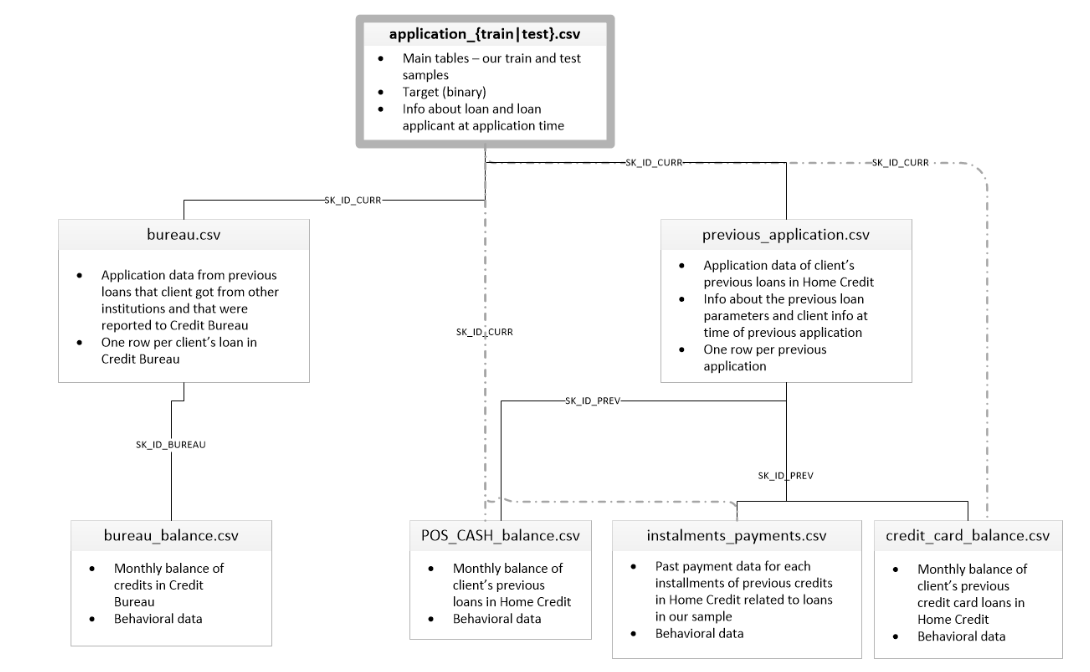

### **2. Analyse exploratoire et préparation des données** 

In [59]:
print(os.listdir("data/raw/"))

['application_test.csv', 'application_train.csv', 'bureau.csv', 'bureau_balance.csv', 'credit_card_balance.csv', 'df_merged.csv', 'installments_payments.csv', 'POS_CASH_balance.csv', 'previous_application.csv', 'sample_submission.csv']


#### **2.1. application_train – chargement + premières vérifications**

In [60]:
# Chargement du jeu d'entrainement 

app_train = pd.read_csv(os.path.join(DATA_DIR, "application_train.csv"))
print('Training data shape: ', app_train.shape)
app_train.head()

Training data shape:  (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

Les données d'entrainement contiennent 307 511 observations (chacune étant un prêt distinct) et 122 colonnes (variables), y compris la colonne `TARGET` (l'étiquette que nous voulons prédire).

In [61]:
# Vérification des doublons
print("Le nombre de doublons dans les données d'entrainement est de : ", 
      app_train[app_train.duplicated()].shape[0])

Le nombre de doublons dans les données d'entrainement est de :  0


In [62]:
# Taux de remplissage
total_missing_values = app_train.isnull().sum().sum()
taux_de_remplissage = 1 - (total_missing_values / app_train.size)
taux_de_remplissage = taux_de_remplissage*100
print(f"Taux de remplissage : {taux_de_remplissage:.2f}%")

Taux de remplissage : 75.60%


In [63]:
# Statistiques des valeurs manquantes
missing_values = missing_values_table(app_train)
missing_values.head(20)

La table choisie a 122 colonnes.
67 colonnes ont des valeurs manquantes.


,Missing Values,% of Total Values
COMMONAREA_MEDI,214865,69.9
COMMONAREA_AVG,214865,69.9
COMMONAREA_MODE,214865,69.9
NONLIVINGAPARTMENTS_MEDI,213514,69.4
NONLIVINGAPARTMENTS_MODE,213514,69.4
NONLIVINGAPARTMENTS_AVG,213514,69.4
FONDKAPREMONT_MODE,210295,68.4
LIVINGAPARTMENTS_MODE,210199,68.4
LIVINGAPARTMENTS_MEDI,210199,68.4
LIVINGAPARTMENTS_AVG,210199,68.4


On remarque que 67 colonnes possèdent des valeurs manquantes (avec un taux de remplissage total de 75% environ), nous devrons donc compléter ces valeurs manquantes. Nous pourrons utiliser des modèles tels que LGBM, capables de gérer les valeurs manquantes sans recourir à l'imputation. Une autre option consisterait à supprimer les colonnes présentant un pourcentage élevé de valeurs manquantes, bien qu'il soit impossible de savoir à l'avance si ces colonnes seront utiles à notre modèle. Par conséquent, nous conserverons toutes les colonnes pour l'instant.

#### **2.2. application_test – chargement + premières vérifications**

In [64]:
# Chargement du dataset test
app_test = pd.read_csv(os.path.join(DATA_DIR, "application_test.csv"))
print('Testing data shape: ', app_test.shape)
app_test.head()

Testing data shape:  (48744, 121)


,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,450000.0,Unaccompanied,Working,Higher education,Married,House / apartment,0.018850,-19241,-2329,-5170.0,-812,NaN,1,1,0,1,0,1,NaN,2.0,2,2,TUESDAY,18,0,0,0,0,0,0,Kindergarten,0.752614,0.789654,0.159520,0.0660,0.0590,0.9732,NaN,NaN,NaN,0.1379,0.125,NaN,NaN,NaN,0.0505,NaN,NaN,0.0672,0.0612,0.9732,NaN,NaN,NaN,0.1379,0.125,NaN,NaN,NaN,0.0526,NaN,NaN,0.0666,0.0590,0.9732,NaN,NaN,NaN,0.1379,0.125,NaN,NaN,NaN,0.0514,NaN,NaN,NaN,block of flats,0.0392,"Stone, brick",No,0.0,0.0,0.0,0.0,-1740.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,180000.0,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,0.035792,-18064,-4469,-9118.0,-1623,NaN,1,1,0,1,0,0,Low-skill Laborers,2.0,2,2,FRIDAY,9,0,0,0,0,0,0,Self-employed,0.564990,0.291656,0.432962,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,630000.0,NaN,Working,Higher education,Married,House / apartment,0.019101,-20038,-4458,-2175.0,-3503,5.0,1,1,0,1,0,0,Drivers,2.0,2,2,MONDAY,14,0,0,0,0,0,0,Transport: type 3,NaN,0.699787,0.610991,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,-856.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,1.0,4.0
3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,1575000.0,Unaccompanied,Working,Secondary / secondary special,Married

Les données d'entrainement contiennent 48 744 observations (chacune étant un prêt distinct) et 121 colonnes (variables).

In [65]:
# Vérification des doublons
print("Le nombre de doublons dans les données de test est de : ", 
      app_test[app_test.duplicated()].shape[0])

Le nombre de doublons dans les données de test est de :  0


In [66]:
# Taux de remplissage
total_missing_values = app_test.isnull().sum().sum()
taux_de_remplissage = 1 - (total_missing_values / app_test.size)
taux_de_remplissage = taux_de_remplissage*100
print(f"Taux de remplissage : {taux_de_remplissage:.2f}%")

Taux de remplissage : 76.19%


In [67]:
# Statistiques des valeurs manquantes
missing_values = missing_values_table(app_test)
missing_values.head(20)

La table choisie a 121 colonnes.
64 colonnes ont des valeurs manquantes.


,Missing Values,% of Total Values
COMMONAREA_MODE,33495,68.7
COMMONAREA_MEDI,33495,68.7
COMMONAREA_AVG,33495,68.7
NONLIVINGAPARTMENTS_MEDI,33347,68.4
NONLIVINGAPARTMENTS_AVG,33347,68.4
NONLIVINGAPARTMENTS_MODE,33347,68.4
FONDKAPREMONT_MODE,32797,67.3
LIVINGAPARTMENTS_MODE,32780,67.2
LIVINGAPARTMENTS_MEDI,32780,67.2
LIVINGAPARTMENTS_AVG,32780,67.2


De la même manière que pour les données d'entrainement, on remarque que 64 colonnes possèdent des valeurs manquantes (avec un taux de remplissage total de 76% environ), nous devrons donc compléter ces valeurs manquantes. Pour l'instant, nous conserverons toutes les colonnes.

#### **2.3. Distribution de la cible**

In [68]:
app_train['TARGET'].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

<Axes: ylabel='Frequency'>

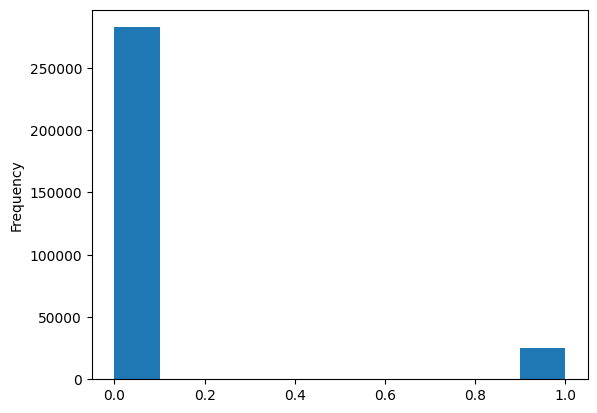

In [69]:
app_train['TARGET'].astype(int).plot.hist()

On remarque que les classes sont déséquilibrées. Les prêts remboursés à temps (TARGET=0) sont bien plus nombreux que ceux non remboursés (TARGET=1). Nous devrons surement pondérer les classes selon leur représentation dans les données afin de refléter ce déséquilibre.

#### **2.4. Typage et cardinalité**

In [70]:
# Réparition des colonnes pour chaque type
app_train.dtypes.value_counts()

float64    65
int64      41
object     16
Name: count, dtype: int64

In [71]:
# Colonnes numériques stockées à tort en object (ex : "12345" ou "12,5")
numeric_like = [
    col for col in app_train.columns
    if app_train[col].dtype == "object"
       and app_train[col].str.replace('.', '', 1).str.replace('-', '', 1).str.isnumeric().all()
]

numeric_like

[]

In [72]:
# Cardinalité des variables catégorielles
cat_unique = (
    app_train
    .select_dtypes("object")
    .apply(pd.Series.nunique)
    .sort_values()
)

cat_unique


NAME_CONTRACT_TYPE             2
FLAG_OWN_CAR                   2
FLAG_OWN_REALTY                2
EMERGENCYSTATE_MODE            2
CODE_GENDER                    3
HOUSETYPE_MODE                 3
FONDKAPREMONT_MODE             4
NAME_EDUCATION_TYPE            5
NAME_FAMILY_STATUS             6
NAME_HOUSING_TYPE              6
NAME_TYPE_SUITE                7
WEEKDAY_APPR_PROCESS_START     7
WALLSMATERIAL_MODE             7
NAME_INCOME_TYPE               8
OCCUPATION_TYPE               18
ORGANIZATION_TYPE             58
dtype: int64

Tableau récapitulatif : 

| Variable                   | Cardinalité | Commentaire analytique                                       |
| -------------------------- | ----------- | ------------------------------------------------------------ |
| NAME_CONTRACT_TYPE         | 2           | Variable binaire → très simple à encoder                     |
| FLAG_OWN_CAR               | 2           | Binaire → OK                                                 |
| FLAG_OWN_REALTY            | 2           | Binaire → OK                                                 |
| EMERGENCYSTATE_MODE        | 2           | Souvent très déséquilibrée, mais simple                      |
| CODE_GENDER                | 3           | Contient surement une valeur spéciale à nettoyer                  |
| HOUSETYPE_MODE             | 3           | Catégories limitées                                          |
| FONDKAPREMONT_MODE         | 4           | Catégories limitées                                          |
| NAME_EDUCATION_TYPE        | 5           | Cohérent                                                     |
| NAME_FAMILY_STATUS         | 6           | Cohérent                                                     |
| NAME_HOUSING_TYPE          | 6           | Cohérent                                                     |
| NAME_TYPE_SUITE            | 7           | Cohérent                                                     |
| WEEKDAY_APPR_PROCESS_START | 7           | Jour de la semaine → peut être recodé cycliquement si besoin |
| WALLSMATERIAL_MODE         | 7           | Catégories raisonnables                                      |
| NAME_INCOME_TYPE           | 8           | Cohérent                                                     |
| OCCUPATION_TYPE            | 18          | Cardinalité modérée → OK pour one-hot                        |
| ORGANIZATION_TYPE          | **58**      | ⚠️ *haute cardinalité* → à surveiller                        |


La majorité des variables catégorielles présentent un faible nombre de modalités (entre 2 et 10). Cela signifie qu’un one-hot encoding classique est adapté pour la grande majorité des colonnes.

- Pour les **variables binaires (2 modalités)** : encodage direct en 0/1 ou en one hot
- Pour les **variables à cardinalité modérée (3 à 10 modalités)** : one hot encoding
- Pour les **variables à cardinalité élevée (18 et 52 modalités)** : on pourrait envisager un Target Encoding par exemple, mais on utilisera surement LightGBM dans le cadre de ce projet, qui gère très bien les one-hot nombreux, on va donc conserver ces colonnes dans le pipeline pour ne pas perdre d'information utiles.

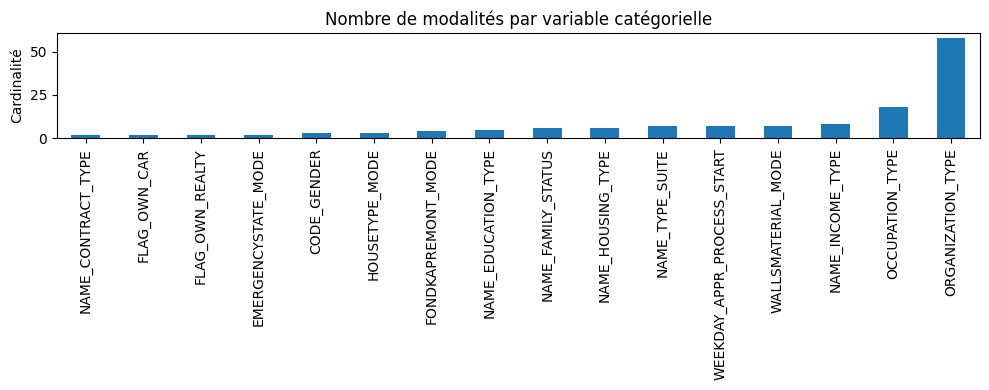

In [73]:
plt.figure(figsize=(10,4))
cat_unique.sort_values().plot(kind="bar")
plt.title("Nombre de modalités par variable catégorielle")
plt.ylabel("Cardinalité")
plt.tight_layout()
plt.show()


Ce graphique permet de visualiser rapidement les variables catégorielles susceptibles de nécessiter un traitement particulier. Seule ORGANIZATION_TYPE présente une cardinalité très élevée et sera surveillée lors de l’encodage.

#### **2.5. Anomalies et nettoyages des variables temporelles**

In [74]:
app_train_temp = app_train.copy()
app_test_temp  = app_test.copy()

Dans cette section, nous analysons deux colonnes temporelles importantes du dataset : `DAYS_BIRTH` (l'âge du client en jours - valeur négative) et `DAYS_EMPLOYED` (ancienneté professionnelle en jours - valeur négative).

L'objectif est triple : vérifier la cohérence des valeurs, identifier des anomalies et corriger proprement ces colonnes avant la modélisation. 

- `DAYS_BIRTH`

In [75]:
app_train_temp['DAYS_BIRTH']

0         -9461
1        -16765
2        -19046
3        -19005
4        -19932
          ...  
307506    -9327
307507   -20775
307508   -14966
307509   -11961
307510   -16856
Name: DAYS_BIRTH, Length: 307511, dtype: int64

Les nombres de la colonne DAYS_BIRTH sont négatifs car ils indiquent le nombre de jours entre la date de naissance du client et la date de sa demande de prêt. 

`DAYS_BIRTH = Date de naissance - Date de la demande de crédit`

Convertissons en âge réel (positif)

In [76]:
app_train_temp["DAYS_BIRTH_POS"] = -app_train_temp["DAYS_BIRTH"]
app_train_temp["AGE"] = app_train_temp["DAYS_BIRTH_POS"] / 365

app_train_temp["AGE"].describe()

count    307511.000000
mean         43.936973
std          11.956133
min          20.517808
25%          34.008219
50%          43.150685
75%          53.923288
max          69.120548
Name: AGE, dtype: float64

Les âges sont compris entre ~20 et ~70 ans ce qui semble raisonnable. La distribution semble réaliste. Cette variable est un indicateur fort dans les modèles de scoring. 

- `DAYS_EMPLOYED`

In [77]:
app_train_temp['DAYS_EMPLOYED'].describe()

count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

Cette variable indique le nombre de jours travaillés par le client avant la demande de prêt. Comme pour DAYS_BIRTH, les valeurs sont en jours négatifs parce qu'elles sont comptées par rapport à la date de la demande. 

`DAYS_EMPLOYED = Date d'embauche - Date de la demande de crédit`

Ça ne semble pas correct ! La valeur maximale (outre le fait qu'elle soit positive) est d'environ 1 000 ans !

Quantifions la :

In [78]:
(app_train_temp['DAYS_EMPLOYED'] == 365243).mean()


0.18007160719453938

Environ 18 % des clients ont cette valeur. Il s'agit d'une valeur spéciale indiquant que le client n’a pas ou plus d’emploi (par exemple, retraité, chômeur, etc.)

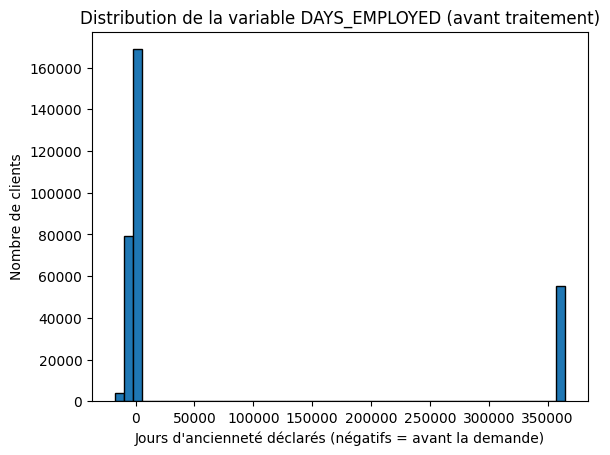

In [79]:
app_train_temp["DAYS_EMPLOYED"].plot.hist(
    bins=50,
    edgecolor="k",
    title="Distribution de la variable DAYS_EMPLOYED (avant traitement)"
)
plt.xlabel("Jours d'ancienneté déclarés (négatifs = avant la demande)")
plt.ylabel("Nombre de clients")
plt.show()


Juste par curiosité, sous-représentons les clients anormaux et voyons s'ils ont tendance à avoir des taux de défaut plus élevés ou plus faibles que le reste des clients.

In [80]:
anom = app_train_temp[app_train_temp["DAYS_EMPLOYED"] == 365243]
non_anom = app_train_temp[app_train_temp["DAYS_EMPLOYED"] != 365243]

print("Taux défaut (non anomalie) :", non_anom["TARGET"].mean()*100)
print("Taux défaut (anomalie)    :", anom["TARGET"].mean()*100)
print("Effectif anomalies :", len(anom))


Taux défaut (non anomalie) : 8.65997453765215
Taux défaut (anomalie)    : 5.399646043269405
Effectif anomalies : 55374


Voilà qui est extrêmement intéressant ! Il s'avère que les anomalies présentent un taux de défaut plus faible (les clients ayant la valeur spéciale font défaut moins souvent)

Donc :

→ Ce n’est pas une "erreur" à supprimer

→ C’est une information sur le statut du client

→ Elle doit être modélisée explicitement

- Correction propre des anomalies

Nous créons une nouvelle colonne indicatrice, puis remplaçons la valeur spéciale par NaN, comme recommandé dans le projet Kaggle.

In [81]:
app_train_temp["DAYS_EMPLOYED_ANOM"] = (app_train_temp["DAYS_EMPLOYED"] == 365243)
app_train_temp["DAYS_EMPLOYED"] = app_train_temp["DAYS_EMPLOYED"].replace(365243, np.nan)

app_test_temp["DAYS_EMPLOYED_ANOM"]  = (app_test_temp["DAYS_EMPLOYED"] == 365243)
app_test_temp["DAYS_EMPLOYED"]       = app_test_temp["DAYS_EMPLOYED"].replace(365243, np.nan)


<Axes: title={'center': 'Distribution DAYS_EMPLOYED (corrigée)'}, ylabel='Frequency'>

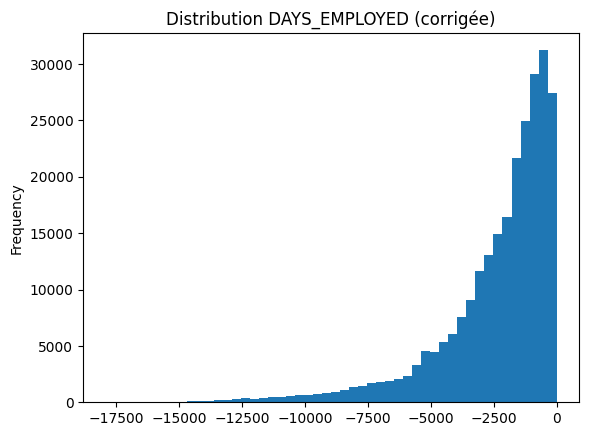

In [82]:
app_train_temp["DAYS_EMPLOYED"].plot.hist(bins=50, title="Distribution DAYS_EMPLOYED (corrigée)")

<Axes: title={'center': 'Distribution DAYS_EMPLOYED (corrigée)'}, ylabel='Frequency'>

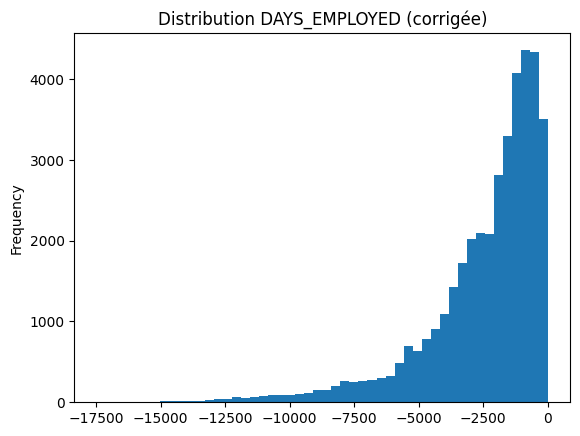

In [83]:
app_test_temp["DAYS_EMPLOYED"].plot.hist(bins=50, title="Distribution DAYS_EMPLOYED (corrigée)")

Cette étape est cruciale car :

- elle garantit que les modèles ne seront pas perturbés par des valeurs absurdes,

- elle encode explicitement une information métier importante (statut d’emploi atypique),

- elle prépare un feature engineering propre et conforme aux bonnes pratiques ML.

#### **2.6. Analyse de l’âge (`DAYS_BIRTH`)**

Dans cette section, nous étudions si l’âge du client influence la probabilité de rembourser son crédit.
Nous utilisons la variable `AGE` calculée précédemment à partir de `DAYS_BIRTH`

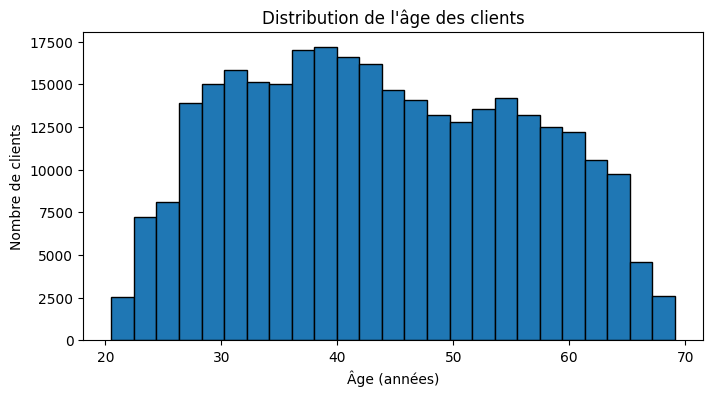

In [84]:
# Distribution de l'age
plt.figure(figsize=(8,4))
plt.hist(app_train_temp["AGE"], bins=25, edgecolor="k")
plt.title("Distribution de l'âge des clients")
plt.xlabel("Âge (années)")
plt.ylabel("Nombre de clients")
plt.show()


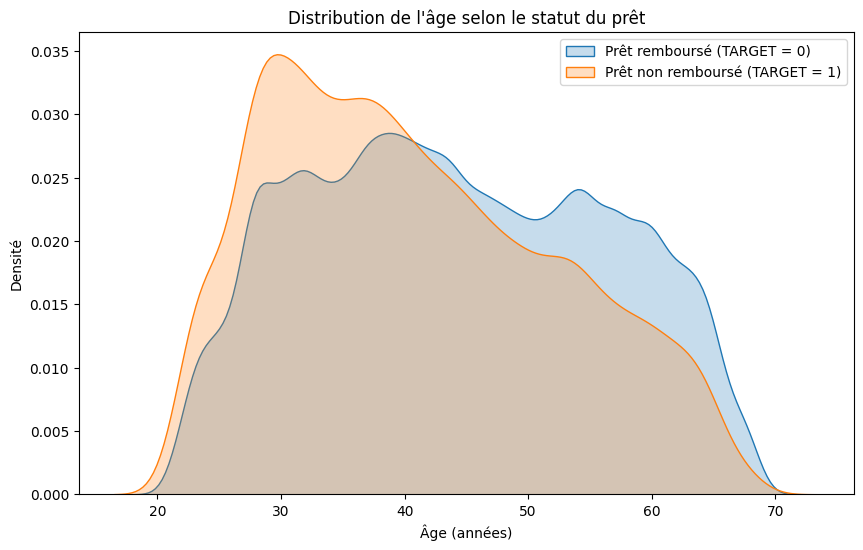

In [85]:
# Influence de l’âge selon la cible (TARGET)
plt.figure(figsize=(10,6))
sns.kdeplot(app_train_temp.loc[app_train_temp["TARGET"] == 0, "AGE"],
            label="Prêt remboursé (TARGET = 0)", shade=True)
sns.kdeplot(app_train_temp.loc[app_train_temp["TARGET"] == 1, "AGE"],
            label="Prêt non remboursé (TARGET = 1)", shade=True)

plt.title("Distribution de l'âge selon le statut du prêt")
plt.xlabel("Âge (années)")
plt.ylabel("Densité")
plt.legend()
plt.show()

- Les plus jeunes (20–35 ans) présentent davantage de défauts.

- Les clients plus âgés (40–60 ans) remboursent mieux.
→ Influence statistiquement faible, mais concrète

In [86]:
# Analyse par tranches d'age 
age_data = app_train_temp[["TARGET", "AGE"]].copy()
age_data["AGE_INT"] = age_data["AGE"].round().astype(int)

bins = range(20, 75, 5)  # Tranches : 20-25, 25-30, ...
age_data["AGE_BIN"] = pd.cut(age_data["AGE_INT"], bins=bins, right=False)

age_groups = age_data.groupby("AGE_BIN")["TARGET"].mean() * 100
age_groups


AGE_BIN
[20, 25)    12.660351
[25, 30)    11.063019
[30, 35)    10.415717
[35, 40)     9.089196
[40, 45)     7.906320
[45, 50)     7.519726
[50, 55)     6.818314
[55, 60)     5.596759
[60, 65)     5.269118
[65, 70)     4.126011
Name: TARGET, dtype: float64

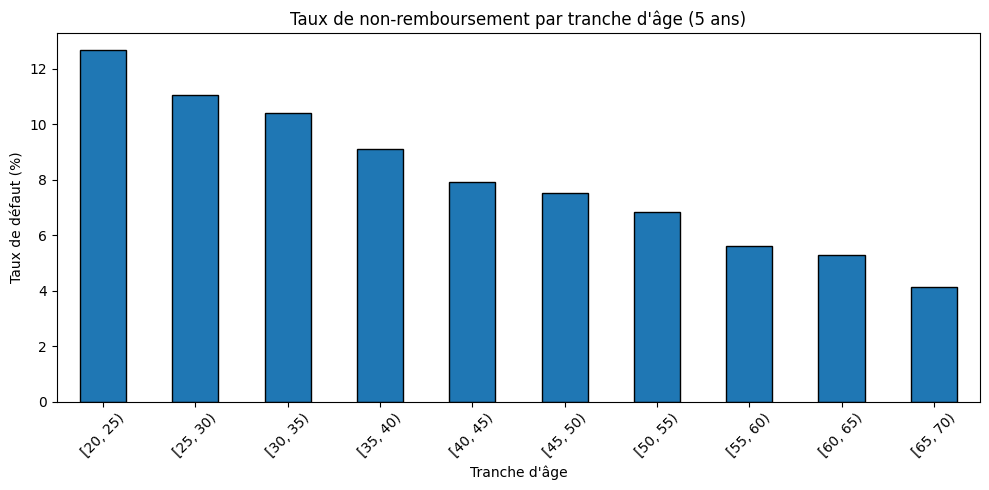

In [87]:
plt.figure(figsize=(10,5))
age_groups.plot(kind="bar", color="#1f77b4", edgecolor="k")

plt.title("Taux de non-remboursement par tranche d'âge (5 ans)")
plt.ylabel("Taux de défaut (%)")
plt.xlabel("Tranche d'âge")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Le risque est 2× plus élevé entre 20 et 35 ans.

Il diminue régulièrement avec l’âge.

L’âge est donc une variable informative, même si sa corrélation brute est faible.

Le modèle pourra capturer ces effets non linéaires, surtout avec des arbres comme LightGBM.

In [88]:
corr_age_target = app_train_temp["AGE"].corr(app_train_temp["TARGET"])
print("Corrélation AGE - TARGET :", corr_age_target)


Corrélation AGE - TARGET : -0.07823930830982698


La corrélation entre l’âge et la variable cible est légèrement négative (≈ −0,07). Cela signifie que, de manière globale, le risque de défaut diminue légèrement avec l'âge.

Cependant, une corrélation faible ne signifie pas que la variable est inutile :
- elle peut avoir un effet non linéaire,
- ce que les modèles arborescents capturent très bien.

Les graphiques ci-dessus montrent d’ailleurs des différences nettes selon les tranches d’âge.

#### **2.7. Analyse du genre (`CODE_GENDER`)**

Analyser si le sexe du client a une influence sur la probabilité de défaut (`TARGET` = 1).

Dans le dataset, une petite portion des individus a la valeur "XNA" → on les supprime car il s’agit d’une anomalie de saisie.

In [89]:
sexe_data = app_train[['TARGET', 'CODE_GENDER']].copy()
sexe_data = sexe_data[sexe_data['CODE_GENDER'] != 'XNA']
sexe_data.head()

,TARGET,CODE_GENDER
0,1,M
1,0,F
2,0,M
3,0,F
4,0,M


- Répartition Homme / Femme par statut de remboursement

In [90]:
# Calcul de la distribution
sexe_group = (sexe_data
              .groupby(["CODE_GENDER", "TARGET"])
              .size()
              .reset_index(name="count"))

# Ajout du pourcentage
sexe_group["percent"] = sexe_group["count"] / sexe_group.groupby("CODE_GENDER")["count"].transform("sum") * 100

sexe_group


,CODE_GENDER,TARGET,count,percent
0,F,0,188278,93.000672
1,F,1,14170,6.999328
2,M,0,94404,89.858080
3,M,1,10655,10.141920


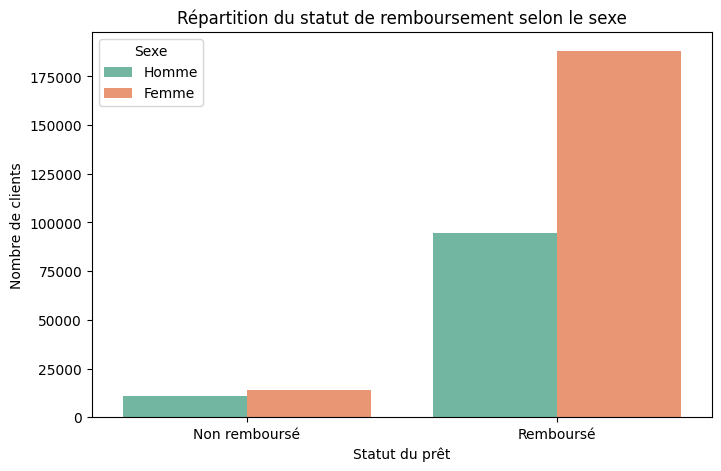

In [91]:
# Visualisation
# Labels lisibles pour les graphiques
sexe_data["TARGET_LABEL"] = sexe_data["TARGET"].map({0: "Remboursé", 1: "Non remboursé"})
sexe_data["GENRE_LABEL"]  = sexe_data["CODE_GENDER"].map({"F": "Femme", "M": "Homme"})

plt.figure(figsize=(8,5))
sns.countplot(
    data=sexe_data,
    x="TARGET_LABEL",
    hue="GENRE_LABEL",
    palette="Set2"
)

plt.title("Répartition du statut de remboursement selon le sexe")
plt.xlabel("Statut du prêt")
plt.ylabel("Nombre de clients")
plt.legend(title="Sexe")
plt.show()


In [92]:
# Taux de non-remboursement par sexe
pct_non_remb = sexe_data.groupby("GENRE_LABEL")["TARGET"].mean() * 100

print("Pourcentage de non-remboursement :")
display(pct_non_remb)

Pourcentage de non-remboursement :


GENRE_LABEL
Femme     6.999328
Homme    10.141920
Name: TARGET, dtype: float64

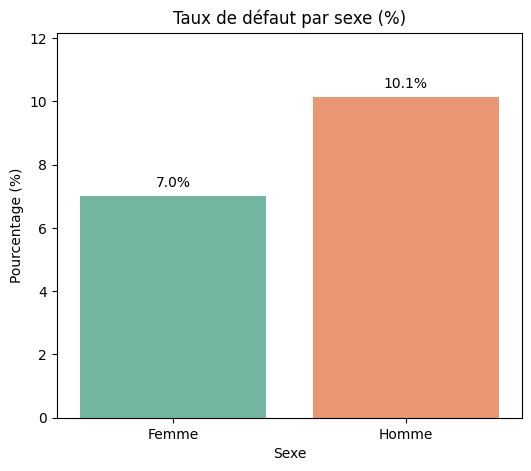

In [93]:
plt.figure(figsize=(6,5))
sns.barplot(
    x=pct_non_remb.index,
    y=pct_non_remb.values,
    palette="Set2"
)

plt.title("Taux de défaut par sexe (%)")
plt.ylabel("Pourcentage (%)")
plt.xlabel("Sexe")
plt.ylim(0, pct_non_remb.max()*1.2)

for i, val in enumerate(pct_non_remb.values):
    plt.text(i, val + 0.3, f"{val:.1f}%", ha='center')

plt.show()



L’analyse de CODE_GENDER montre une différence nette entre les deux groupes :
- Les femmes présentent un taux de défaut plus faible (≈ 7%),
- Les hommes un taux plus élevé (≈ 10%).

Cet écart reste modéré et la corrélation avec la cible est faible, ce qui signifie que le sexe n’est pas un facteur déterminant pris isolément.
Cependant, la variable reste informative : les modèles d’arbres comme LightGBM peuvent exploiter des interactions subtiles (avec l’âge, l’emploi, les revenus…), ce qui en fait une caractéristique utile pour la prédiction.

En résumé : CODE_GENDER apporte un signal faible mais réel, justifiant son maintien dans le modèle.

- Application du FE a partir de DAYS_BIRTH, DAYS_EMPLOYED et CODE_GENDER sur app_train et app_test

In [94]:
def base_feature_engineering(df):
    df = df.copy()

    # --- Nettoyage des valeurs anormales ---

    # CODE_GENDER : remplacer XNA par NaN
    if "CODE_GENDER" in df.columns:
        df["CODE_GENDER"] = df["CODE_GENDER"].replace("XNA", np.nan)

    # --- AGE ---
    df["AGE"] = (-df["DAYS_BIRTH"] / 365).round()

    # --- DAYS_EMPLOYED anomaly flag ---
    df["DAYS_EMPLOYED_ANOM"] = (df["DAYS_EMPLOYED"] == 365243)
    df["DAYS_EMPLOYED"] = df["DAYS_EMPLOYED"].replace(365243, np.nan)
    return df

In [95]:
app_train_fe = base_feature_engineering(app_train)
app_test_fe  = base_feature_engineering(app_test)

#### **2.8. Analyse des scores `EXT_SOURCE`**

L'objectif est d'explorer les trois scores externes : `EXT_SOURCE_1`, `EXT_SOURCE_2`, `EXT_SOURCE_3`. 

Ce sont des scores externes de crédit (probablement obtenus via des agences de crédit ou des systèmes internes de notation).

Ils mesurent la fiabilité financière d’un client sur une échelle normalisée entre 0 et 1, où :
- 0 signifie risque élevé (forte probabilité de défaut),
- 1 signifie faible risque (client fiable).

In [96]:
# Extraction et matrice de corrélation
ext_data = app_train_fe[[
    "TARGET", "EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3", "AGE"
]]

ext_corr = ext_data.corr()
ext_corr


,TARGET,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,AGE
TARGET,1.000000,-0.155317,-0.160472,-0.178919,-0.078263
EXT_SOURCE_1,-0.155317,1.000000,0.213982,0.186846,0.600333
EXT_SOURCE_2,-0.160472,0.213982,1.000000,0.109167,0.091993
EXT_SOURCE_3,-0.178919,0.186846,0.109167,1.000000,0.205492
AGE,-0.078263,0.600333,0.091993,0.205492,1.000000


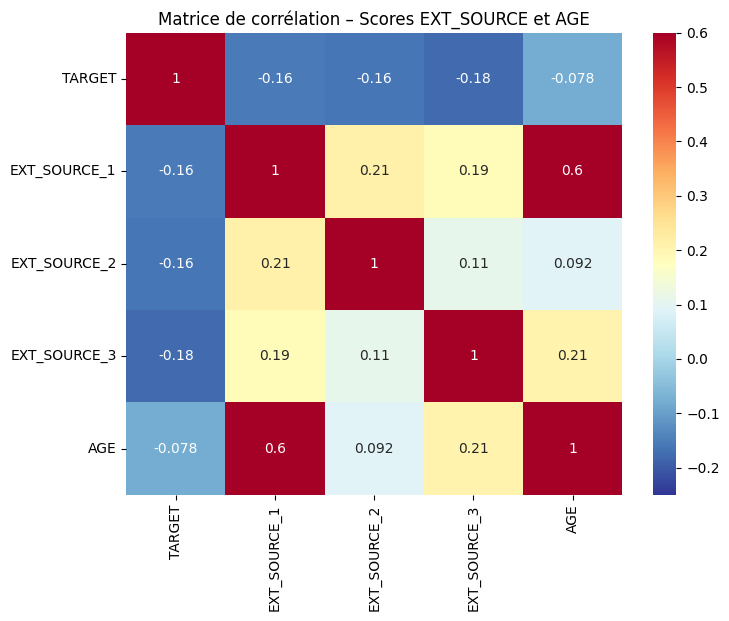

In [97]:
# Visualisation 
plt.figure(figsize=(8, 6))
sns.heatmap(ext_corr, cmap="RdYlBu_r", annot=True, vmin=-0.25, vmax=0.6)
plt.title("Matrice de corrélation – Scores EXT_SOURCE et AGE")
plt.show()

Les trois scores EXT_SOURCE présentent une corrélation négative avec la cible (≈ -0.16 à -0.18) :
- plus le score est faible, plus le risque de défaut est élevé.

EXT_SOURCE_3 est le plus prédictif.

Les scores sont peu corrélés entre eux, ce qui montre qu’ils apportent chacun une information complémentaire sur la solvabilité.

EXT_SOURCE_1 est fortement corrélé à l’âge (0.60), tandis que EXT_SOURCE_2 et EXT_SOURCE_3 le sont très faiblement.
Ils apportent donc une information indépendante de l’âge.

En résumé : les scores EXT_SOURCE sont des indicateurs clés du risque de crédit et joueront un rôle majeur dans la performance du futur modèle.

Distribution des scores par valeur cible

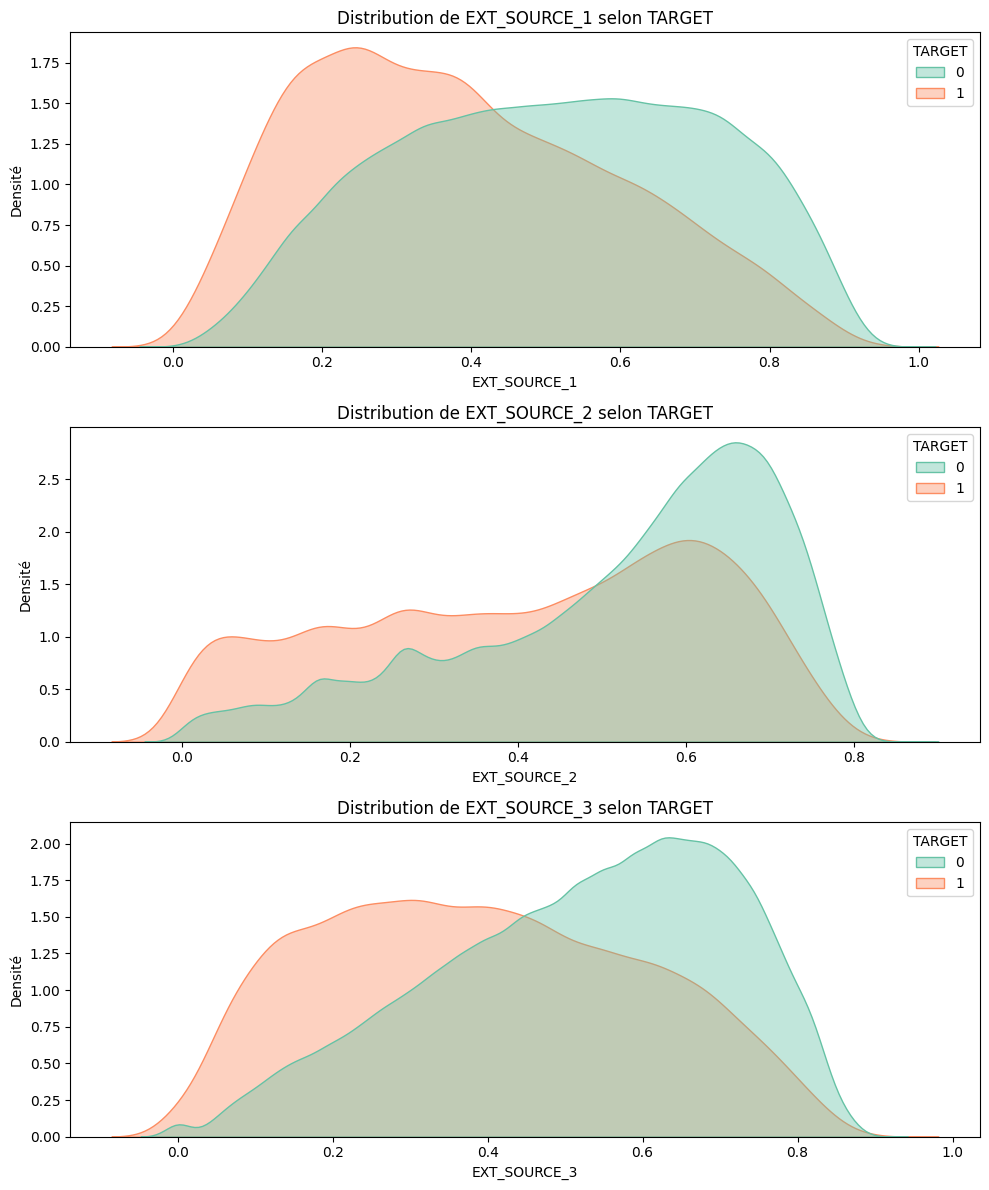

In [98]:
plt.figure(figsize=(10, 12))

for i, source in enumerate(["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]):
    plt.subplot(3, 1, i + 1)
    sns.kdeplot(
        data=app_train_fe,
        x=source,
        hue="TARGET",
        fill=True,
        common_norm=False,
        palette="Set2",
        alpha=0.4
    )
    plt.title(f"Distribution de {source} selon TARGET")
    plt.xlabel(source)
    plt.ylabel("Densité")

plt.tight_layout()
plt.show()


Les trois graphiques montrent une tendance très cohérente :

- Pour les clients qui ont remboursé (TARGET = 0), les valeurs d’EXT_SOURCE sont plus élevées, avec une densité concentrée autour de 0.5–0.8.

- Pour les clients en défaut (TARGET = 1), les scores sont nettement plus faibles, majoritairement sous 0.4.

Plus le score EXT_SOURCE est élevé, plus le client est considéré comme fiable.

On constate également que cette séparation est :

- claire pour EXT_SOURCE_2 et EXT_SOURCE_3,

- un peu moins marquée mais toujours présente pour EXT_SOURCE_1.

Ces distributions confirment que les variables EXT_SOURCE sont parmi les meilleurs indicateurs du risque de crédit, car elles discriminent bien les bons et les mauvais payeurs.

#### **2.9. Analyse de `OCCUPATION_TYPE`**

Cette variable indique la catégorie socio-professionnelle du demandeur



In [99]:
# Distribution des occupations selon TARGET
p1 = (app_train_fe.loc[app_train_fe['TARGET'] == 1, 'OCCUPATION_TYPE']
      .value_counts(normalize=True) * 100)
p0 = (app_train_fe.loc[app_train_fe['TARGET'] == 0, 'OCCUPATION_TYPE']
      .value_counts(normalize=True) * 100)

In [100]:
# Harmoniser les catégories présentes dans les deux distributions
cats = sorted(set(p0.index).union(p1.index), key=lambda c: p1.get(c, 0), reverse=True)
p1 = p1.reindex(cats).fillna(0)
p0 = p0.reindex(cats).fillna(0)

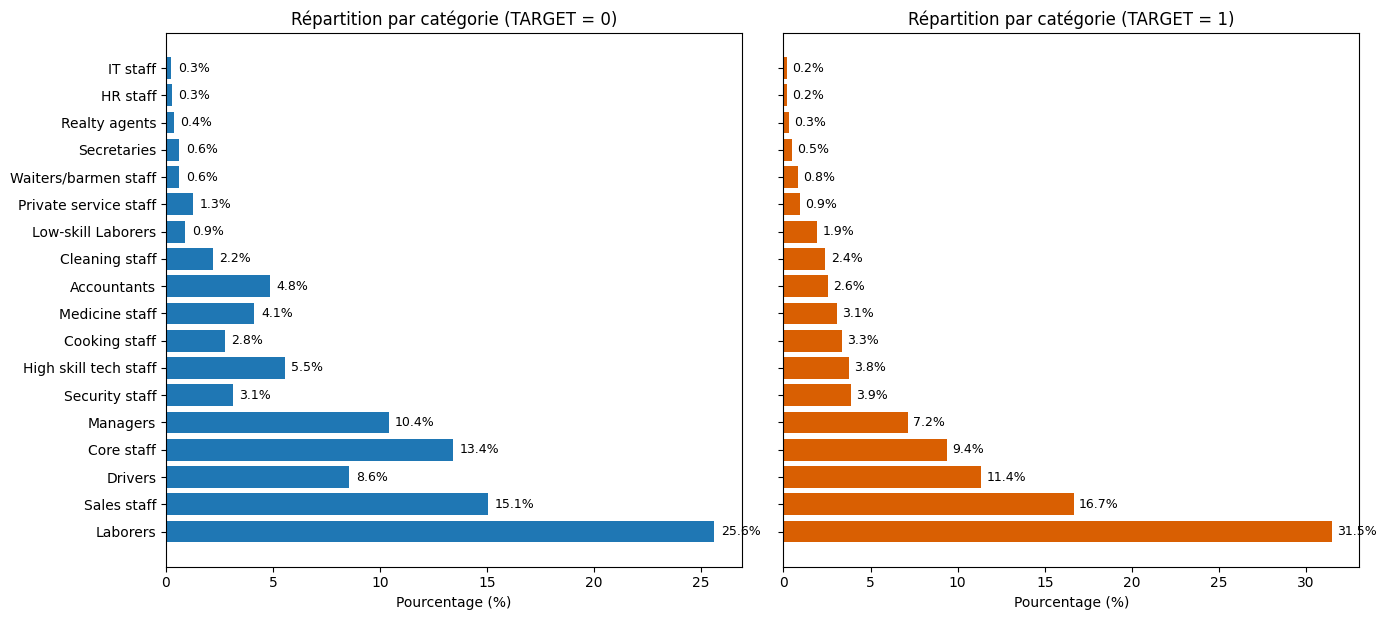

In [101]:
# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, max(6, len(cats) * 0.35)), sharey=True)

axes[0].barh(cats, p0.values)
axes[0].set_title("Répartition par catégorie (TARGET = 0)")
axes[0].set_xlabel("Pourcentage (%)")
axes[0].invert_yaxis()

axes[1].barh(cats, p1.values, color="#d95f02")
axes[1].set_title("Répartition par catégorie (TARGET = 1)")
axes[1].set_xlabel("Pourcentage (%)")
axes[1].invert_yaxis()

for ax in axes:
    for y, v in enumerate((p0 if ax is axes[0] else p1).values):
        ax.text(v + 0.3, y, f"{v:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()

L’analyse des catégories socioprofessionnelles met en évidence des différences marquées entre les bons et les mauvais payeurs.  
Certaines professions – notamment *Laborers*, *Drivers* et *Sales staff* – sont nettement surreprésentées parmi les clients en défaut, tandis que des postes plus stables comme *Managers* ou *High skill tech staff* apparaissent davantage chez les clients ayant remboursé leur prêt.

Ces tendances suggèrent que le type d’emploi constitue un indicateur pertinent du risque de crédit.  
Bien que la variable soit multicatégorielle et hétérogène, elle apporte une information utile et sera conservée pour la modélisation.


#### **2.10. Correlations avec la variable TARGET**

Calcul des corrélations avec TARGET

In [102]:
# Sélection des colonnes numériques
df_corr = app_train_fe.select_dtypes(include=[np.number])

# Corrélation de chaque variable avec TARGET
corr_with_target = df_corr.corr()['TARGET'].drop('TARGET')

# Top 10 en valeur absolue
top10_corr = corr_with_target.abs().sort_values(ascending=False).head(10)

print("Top 10 des variables les plus corrélées à TARGET :")
display(top10_corr)


Top 10 des variables les plus corrélées à TARGET :


EXT_SOURCE_3                   0.178919
EXT_SOURCE_2                   0.160472
EXT_SOURCE_1                   0.155317
AGE                            0.078263
DAYS_BIRTH                     0.078239
DAYS_EMPLOYED                  0.074958
REGION_RATING_CLIENT_W_CITY    0.060893
REGION_RATING_CLIENT           0.058899
DAYS_LAST_PHONE_CHANGE         0.055218
DAYS_ID_PUBLISH                0.051457
Name: TARGET, dtype: float64

Visualisation du Top 10

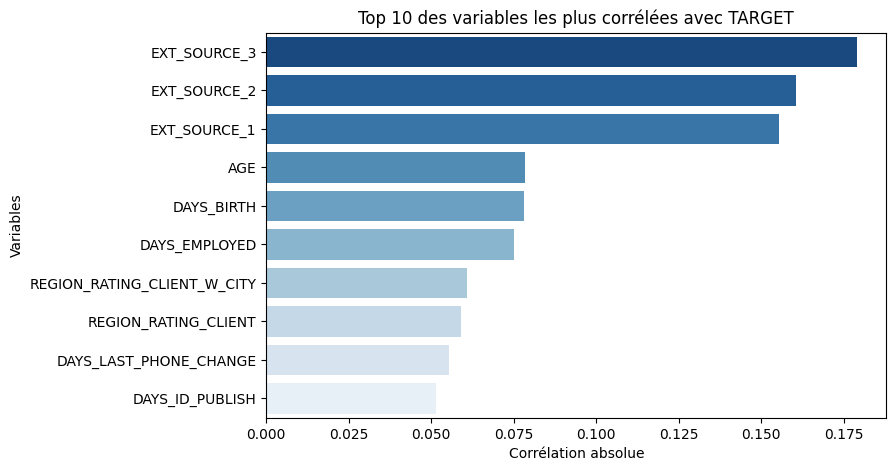

In [103]:
plt.figure(figsize=(8, 5))
sns.barplot(
    x=top10_corr.values,
    y=top10_corr.index,
    palette="Blues_r"
)
plt.title("Top 10 des variables les plus corrélées avec TARGET")
plt.xlabel("Corrélation absolue")
plt.ylabel("Variables")
plt.show()


Heatmap centrée sur le Top 10

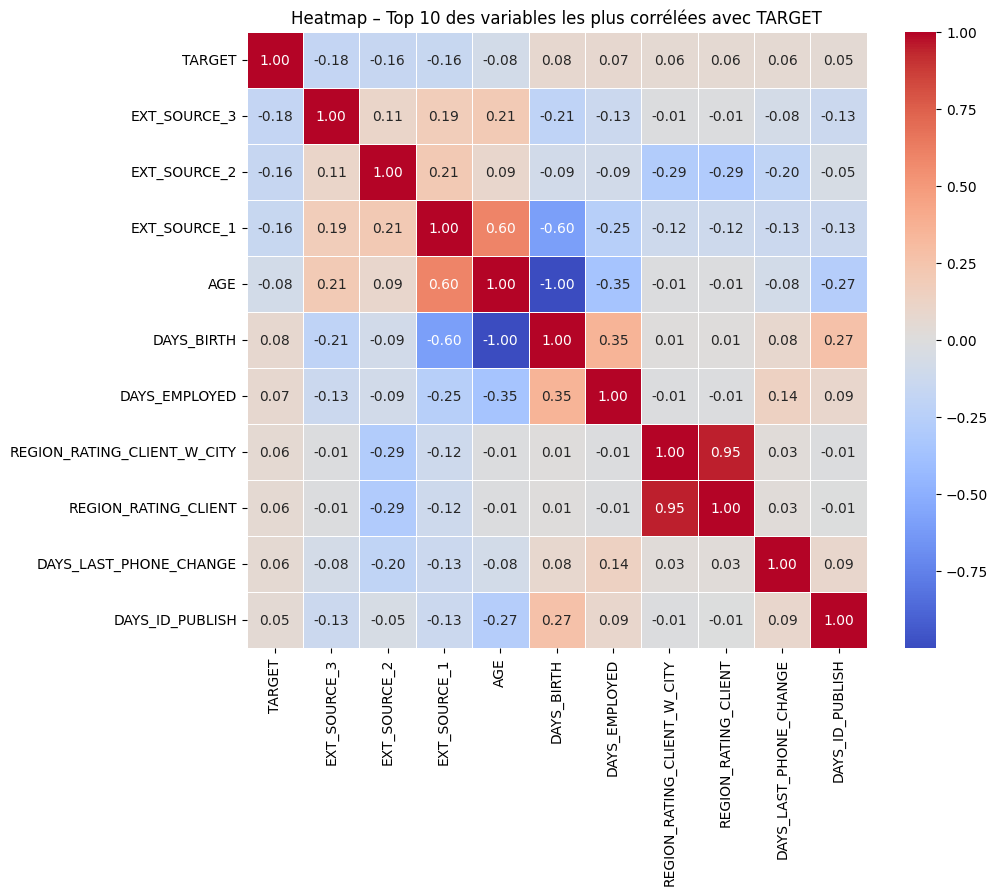

In [104]:
vars_for_heatmap = ["TARGET"] + top10_corr.index.tolist()
corr_top10 = df_corr[vars_for_heatmap].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_top10,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    annot=True,
    fmt=".2f"
)
plt.title("Heatmap – Top 10 des variables les plus corrélées avec TARGET")
plt.show()


L’analyse des corrélations montre que les trois scores externes (`EXT_SOURCE_1`, `EXT_SOURCE_2`, `EXT_SOURCE_3`) sont les variables les plus liées au risque de défaut. Leur corrélation négative indique que des scores élevés sont associés à une meilleure solvabilité.

L’âge (`DAYS_BIRTH`) apparaît également comme un indicateur pertinent : les clients plus jeunes présentent un risque légèrement plus élevé.  
Les autres variables du Top 10 concernent principalement la stabilité financière ou l’historique de crédit.

Même si ces corrélations restent faibles, elles confirment les tendances observées dans l’EDA et la pertinence d’utiliser un modèle non linéaire pour capturer des interactions complexes.

#### **2.11. One hot encoding et Feature Engineering - application train/test**

Pour la préparation des données nous nous baserons sur le kernel Kaggle suivant : [LightGBM with Simple Features](https://www.kaggle.com/code/jsaguiar/lightgbm-with-simple-features/script)

L'objectif est d'enrichir le jeu de données en construisant un pipeline de FI pour améliorer la capacité prédictive du futur modèle de classification. 

In [105]:
print(app_train_fe.shape)
print(app_test_fe.shape)

(307511, 124)
(48744, 123)


- Séparation des features catégorielles et numériques

In [106]:
# Séparer variables numériques et catégorielles
cat_cols = app_train_fe.select_dtypes(include=["object"]).columns
num_cols = app_train_fe.select_dtypes(exclude=["object"]).columns

print("Nombre de variables catégorielles :", len(cat_cols))
print("Nombre de variables numériques :", len(num_cols))

Nombre de variables catégorielles : 16
Nombre de variables numériques : 108


- Ratios application train 

In [107]:
if {'DAYS_EMPLOYED','DAYS_BIRTH'}.issubset(app_train_fe.columns):
    app_train_fe['DAYS_EMPLOYED_PERC'] = app_train_fe['DAYS_EMPLOYED'] / app_train_fe['DAYS_BIRTH']

if {'AMT_INCOME_TOTAL','AMT_CREDIT'}.issubset(app_train_fe.columns):
    app_train_fe['INCOME_CREDIT_PERC'] = app_train_fe['AMT_INCOME_TOTAL'] / app_train_fe['AMT_CREDIT']

if {'AMT_INCOME_TOTAL','CNT_FAM_MEMBERS'}.issubset(app_train_fe.columns):
    app_train_fe['INCOME_PER_PERSON'] = app_train_fe['AMT_INCOME_TOTAL'] / app_train_fe['CNT_FAM_MEMBERS']

if {'AMT_ANNUITY','AMT_INCOME_TOTAL'}.issubset(app_train_fe.columns):
    app_train_fe['ANNUITY_INCOME_PERC'] = app_train_fe['AMT_ANNUITY'] / app_train_fe['AMT_INCOME_TOTAL']

if {'AMT_ANNUITY','AMT_CREDIT'}.issubset(app_train_fe.columns):
    app_train_fe['PAYMENT_RATE'] = app_train_fe['AMT_ANNUITY'] / app_train_fe['AMT_CREDIT']

- Ratios application test 

In [108]:
if {'DAYS_EMPLOYED','DAYS_BIRTH'}.issubset(app_test_fe.columns):
    app_test_fe['DAYS_EMPLOYED_PERC'] = app_test_fe['DAYS_EMPLOYED'] / app_test_fe['DAYS_BIRTH']

if {'AMT_INCOME_TOTAL','AMT_CREDIT'}.issubset(app_test_fe.columns):
    app_test_fe['INCOME_CREDIT_PERC'] = app_test_fe['AMT_INCOME_TOTAL'] / app_test_fe['AMT_CREDIT']

if {'AMT_INCOME_TOTAL','CNT_FAM_MEMBERS'}.issubset(app_test_fe.columns):
    app_test_fe['INCOME_PER_PERSON'] = app_test_fe['AMT_INCOME_TOTAL'] / app_test_fe['CNT_FAM_MEMBERS']

if {'AMT_ANNUITY','AMT_INCOME_TOTAL'}.issubset(app_test_fe.columns):
    app_test_fe['ANNUITY_INCOME_PERC'] = app_test_fe['AMT_ANNUITY'] / app_test_fe['AMT_INCOME_TOTAL']

if {'AMT_ANNUITY','AMT_CREDIT'}.issubset(app_test_fe.columns):
    app_test_fe['PAYMENT_RATE'] = app_test_fe['AMT_ANNUITY'] / app_test_fe['AMT_CREDIT']

In [109]:
print(app_train_fe.shape)
print(app_test_fe.shape)

(307511, 129)
(48744, 128)


Ces ratios capturent des notions essentielles comme :

- stabilité financière (ratio revenu/crédit, revenu par personne),
- capacité de remboursement (annuité/income),
- poids de l'annuité dans le crédit (payment rate),
- proportion d'activité professionnelle (employed/birth).

- Encodage One-Hot (train + test)

In [110]:
# Séparation de la cible
y = app_train_fe["TARGET"].copy()

# On retire TARGET des features
app_train_fe = app_train_fe.drop(columns=["TARGET"])

In [111]:
"TARGET" in app_test_fe.columns

False

In [113]:
"TARGET" in app_train_fe.columns

False

In [114]:
# Concaténer train et test pour garantir les mêmes colonnes après encodage
app_train_fe["is_train"] = 1
app_test_fe["is_train"] = 0

full_data = pd.concat([app_train_fe, app_test_fe], axis=0, ignore_index=True)

# One-Hot Encoding sur toutes les colonnes catégorielles
full_data = pd.get_dummies(full_data, columns=cat_cols, dummy_na=True)

# Séparation train / test après encodage
train_encoded = full_data[full_data["is_train"] == 1].drop(columns=["is_train"])
test_encoded  = full_data[full_data["is_train"] == 0].drop(columns=["is_train"])

print("Dimensions train :", train_encoded.shape)
print("Dimensions test  :", test_encoded.shape)

Dimensions train : (307511, 267)
Dimensions test  : (48744, 267)


In [115]:
# Vérification rapide : pas de colonnes manquantes entre train et test
set(train_encoded.columns) == set(test_encoded.columns)

True

Toutes les variables catégorielles ont été transformées en variables numériques grâce au One-Hot Encoding.  
Pour éviter toute incohérence entre les jeux d'entraînement et de test, l’encodage a été réalisé sur les deux jeux concaténés, puis les données ont été séparées à nouveau.

Cette approche garantit :
- l’absence de fuite de données,
- des colonnes strictement identiques entre train et test,
- et une meilleure stabilité pour les modèles basés sur des arbres (LightGBM, RandomForest).

Le dataset est désormais prêt pour les étapes de feature engineering avancé et d’intégration des tables secondaires.

#### **2.12. Agrégation des tables secondaires**

Les données Home Credit contiennent plusieurs tables décrivant l’historique financier du client :

| Table                       | Contenu                                     | Objectif                                 |
| --------------------------- | ------------------------------------------- | ---------------------------------------- |
| `bureau.csv`                | crédits externes du client                  | comprendre son endettement global        |
| `bureau_balance.csv`        | historique mensuel des crédits externes     | détecter les comportements récents       |
| `previous_application.csv`  | anciennes demandes de prêt chez Home Credit | voir si le client a été refusé / accepté |
| `POS_CASH_balance.csv`      | comportement sur crédits actifs             | stabilité des paiements                  |
| `installments_payments.csv` | paiements d’échéances                       | retards, montants remboursés             |
| `credit_card_balance.csv`   | gestion des cartes de crédit                | risque via revolving                     |

Ces tables doivent être agrégées par SK_ID_CURR, sinon on se retrouve avec des lignes dupliquées et une fuite de données.

- Bureau / Bureau_balance

In [116]:
bureau = pd.read_csv(os.path.join(DATA_DIR, "bureau.csv"))
bureau_balance = pd.read_csv(os.path.join(DATA_DIR, "bureau_balance.csv"))

In [117]:
# One hot encoding
bureau_balance, bureau_balance_cat = one_hot_encoder(bureau_balance, nan_as_category=True)
bureau, bureau_cat = one_hot_encoder(bureau, nan_as_category=True)

In [118]:
# Agrégations bureau_balance → bureau sur SK_ID_BUREAU
bureau_balance_agg = bureau_balance.groupby('SK_ID_BUREAU').agg({
    'MONTHS_BALANCE': ['min', 'max', 'size'],
    **{c: ['mean'] for c in bureau_balance_cat}
})
bureau_balance_agg.columns = pd.Index([f"{a}_{b.upper()}" for a, b in bureau_balance_agg.columns])

# Merge bureau ← bureau_balance
bureau = bureau.join(bureau_balance_agg, on='SK_ID_BUREAU', how='left').drop(columns=['SK_ID_BUREAU'])


In [119]:
# Agrégations finales bureau par SK_ID_CURR
num_aggs = {
    'DAYS_CREDIT': ['min', 'max', 'mean', 'var'],
    'DAYS_CREDIT_ENDDATE': ['min', 'max', 'mean'],
    'DAYS_CREDIT_UPDATE': ['mean'],
    'CREDIT_DAY_OVERDUE': ['max', 'mean'],
    'AMT_CREDIT_MAX_OVERDUE': ['mean'],
    'AMT_CREDIT_SUM': ['max', 'mean', 'sum'],
    'AMT_CREDIT_SUM_DEBT': ['max', 'mean', 'sum'],
    'AMT_CREDIT_SUM_OVERDUE': ['mean'],
    'AMT_CREDIT_SUM_LIMIT': ['mean', 'sum'],
    'AMT_ANNUITY': ['max', 'mean'],
    'CNT_CREDIT_PROLONG': ['sum'],
    'MONTHS_BALANCE_MIN': ['min'],
    'MONTHS_BALANCE_MAX': ['max'],
    'MONTHS_BALANCE_SIZE': ['mean', 'sum']
}
cat_aggs = {c: ['mean'] for c in bureau_cat}
cat_aggs.update({f"{c}_MEAN": ['mean'] for c in bureau_balance_cat})

bureau_agg = bureau.groupby('SK_ID_CURR').agg({**num_aggs, **cat_aggs})
bureau_agg.columns = pd.Index([f"BURO_{a}_{b.upper()}" for a, b in bureau_agg.columns])

# Active / Closed
if 'CREDIT_ACTIVE_Active' in bureau.columns:
    active = bureau[bureau['CREDIT_ACTIVE_Active'] == 1]
    active_agg = active.groupby('SK_ID_CURR').agg(num_aggs)
    active_agg.columns = pd.Index([f"ACTIVE_{a}_{b.upper()}" for a, b in active_agg.columns])
    bureau_agg = bureau_agg.join(active_agg, how='left')

if 'CREDIT_ACTIVE_Closed' in bureau.columns:
    closed = bureau[bureau['CREDIT_ACTIVE_Closed'] == 1]
    closed_agg = closed.groupby('SK_ID_CURR').agg(num_aggs)
    closed_agg.columns = pd.Index([f"CLOSED_{a}_{b.upper()}" for a, b in closed_agg.columns])
    bureau_agg = bureau_agg.join(closed_agg, how='left')

- Previous_application

In [120]:
prev = pd.read_csv(os.path.join(DATA_DIR, "previous_application.csv"))

In [121]:
# Remplacement des valeurs aberrantes
for c in ['DAYS_FIRST_DRAWING','DAYS_FIRST_DUE','DAYS_LAST_DUE_1ST_VERSION','DAYS_LAST_DUE','DAYS_TERMINATION']:
    if c in prev.columns:
        prev[c] = prev[c].replace(365243, np.nan)

In [122]:
# Ratio simple
if {'AMT_APPLICATION','AMT_CREDIT'}.issubset(prev.columns):
    prev['APP_CREDIT_PERC'] = prev['AMT_APPLICATION'] / prev['AMT_CREDIT']

In [123]:
# Encodage
prev, prev_cat_cols = one_hot_encoder(prev, nan_as_category=True)

In [124]:
# Agregation 
num_aggs_prev = {
    'AMT_ANNUITY': ['min','max','mean'],
    'AMT_APPLICATION': ['min','max','mean'],
    'AMT_CREDIT': ['min','max','mean'],
    'APP_CREDIT_PERC': ['min','max','mean','var'],
    'AMT_DOWN_PAYMENT': ['min','max','mean'],
    'AMT_GOODS_PRICE': ['min','max','mean'],
    'HOUR_APPR_PROCESS_START': ['min','max','mean'],
    'RATE_DOWN_PAYMENT': ['min','max','mean'],
    'DAYS_DECISION': ['min','max','mean'],
    'CNT_PAYMENT': ['mean','sum'],
}
cat_aggs_prev = {c: ['mean'] for c in prev_cat_cols}
prev_agg = prev.groupby('SK_ID_CURR').agg({**num_aggs_prev, **cat_aggs_prev})
prev_agg.columns = pd.Index([f"PREV_{a}_{b.upper()}" for a, b in prev_agg.columns])

if 'NAME_CONTRACT_STATUS_Approved' in prev.columns:
    approved = prev[prev['NAME_CONTRACT_STATUS_Approved'] == 1]
    app_agg = approved.groupby('SK_ID_CURR').agg(num_aggs_prev)
    app_agg.columns = pd.Index([f"APPROVED_{a}_{b.upper()}" for a, b in app_agg.columns])
    prev_agg = prev_agg.join(app_agg, how='left')

if 'NAME_CONTRACT_STATUS_Refused' in prev.columns:
    refused = prev[prev['NAME_CONTRACT_STATUS_Refused'] == 1]
    ref_agg = refused.groupby('SK_ID_CURR').agg(num_aggs_prev)
    ref_agg.columns = pd.Index([f"REFUSED_{a}_{b.upper()}" for a, b in ref_agg.columns])
    prev_agg = prev_agg.join(ref_agg, how='left')

- POS_CASH_balance

In [125]:
pos = pd.read_csv(os.path.join(DATA_DIR, "POS_CASH_balance.csv"))

In [126]:
# Encodage
pos, pos_cat_cols = one_hot_encoder(pos, nan_as_category=True)

In [127]:
# Agregation
aggs_pos = {'MONTHS_BALANCE':['max','mean','size'], 'SK_DPD':['max','mean'], 'SK_DPD_DEF':['max','mean']}
aggs_pos.update({c:['mean'] for c in pos_cat_cols})
pos_agg = pos.groupby('SK_ID_CURR').agg(aggs_pos)
pos_agg.columns = pd.Index([f"POS_{a}_{b.upper()}" for a, b in pos_agg.columns])
pos_agg['POS_COUNT'] = pos.groupby('SK_ID_CURR').size()

- Installments Payments

In [128]:
ins = pd.read_csv(os.path.join(DATA_DIR, "installments_payments.csv"))

In [129]:
# Ratios 
ins['PAYMENT_PERC'] = ins['AMT_PAYMENT'] / ins['AMT_INSTALMENT']
ins['PAYMENT_DIFF'] = ins['AMT_INSTALMENT'] - ins['AMT_PAYMENT']
ins['DPD'] = (ins['DAYS_ENTRY_PAYMENT'] - ins['DAYS_INSTALMENT']).clip(lower=0)
ins['DBD'] = (ins['DAYS_INSTALMENT'] - ins['DAYS_ENTRY_PAYMENT']).clip(lower=0)

In [130]:
# Encodage 
ins, ins_cat_cols = one_hot_encoder(ins, nan_as_category=True)

In [131]:
# Agrégation
aggs_ins = {
    'NUM_INSTALMENT_VERSION':['nunique'],
    'DPD':['max','mean','sum'],
    'DBD':['max','mean','sum'],
    'PAYMENT_PERC':['max','mean','sum','var'],
    'PAYMENT_DIFF':['max','mean','sum','var'],
    'AMT_INSTALMENT':['max','mean','sum'],
    'AMT_PAYMENT':['min','max','mean','sum'],
    'DAYS_ENTRY_PAYMENT':['max','mean','sum']
}
aggs_ins.update({c:['mean'] for c in ins_cat_cols})
ins_agg = ins.groupby('SK_ID_CURR').agg(aggs_ins)
ins_agg.columns = pd.Index([f"INSTAL_{a}_{b.upper()}" for a, b in ins_agg.columns])
ins_agg['INSTAL_COUNT'] = ins.groupby('SK_ID_CURR').size()

- Credit Card Balance

In [132]:
cc = pd.read_csv(os.path.join(DATA_DIR, "credit_card_balance.csv"))

In [133]:
# Encodage
cc, cc_cat_cols = one_hot_encoder(cc, nan_as_category=True)

In [134]:
# Nettoyage
if 'SK_ID_PREV' in cc.columns:
    cc = cc.drop(columns=['SK_ID_PREV'])

In [135]:
# Agrégation
cc_agg = cc.groupby('SK_ID_CURR').agg(['min','max','mean','sum','var'])
cc_agg.columns = pd.Index([f"CC_{a}_{b.upper()}" for a, b in cc_agg.columns])
cc_agg['CC_COUNT'] = cc.groupby('SK_ID_CURR').size()

#### **2.13. Nettoyage, merge et export des dataset**

Après l’intégration des tables secondaires, nous obtenons deux datasets complets :

- `df_train` : données d'entraînement (incluant la variable cible `TARGET`)
- `df_test` : données de test (sans `TARGET`, pour la prédiction Kaggle)

Avant d’avancer vers la modélisation, il est essentiel de vérifier :

1. l’absence d’erreur structurelle après le merge  
2. le taux de remplissage final du dataset (proportion de valeurs non manquantes)  
3. la cohérence des colonnes entre train et test  
4. la sauvegarde propre des fichiers

In [136]:
df_train = train_encoded.copy()
df_test  = test_encoded.copy()

In [137]:
for table in (bureau_agg, prev_agg, pos_agg, ins_agg, cc_agg):
    df_train = df_train.join(table, on="SK_ID_CURR", how="left")
    df_test  = df_test.join(table, on="SK_ID_CURR", how="left")

In [138]:
# Réintégration de la colonne TARGET
df_train["TARGET"] = y.values

In [139]:
print("Train shape final :", df_train.shape)
print("Test shape final  :", df_test.shape)

Train shape final : (307511, 818)
Test shape final  : (48744, 817)


In [140]:
# Taux de remplissage
total_missing_values = df_train.isnull().sum().sum()
taux_de_remplissage = 1 - (total_missing_values / df_train.size)
taux_de_remplissage = taux_de_remplissage*100
print(f"Taux de remplissage du dataset train : {taux_de_remplissage:.2f}%")

Taux de remplissage du dataset train : 74.74%


- Vérifications

In [142]:
"TARGET" in df_train.columns

True

In [143]:
"TARGET" in df_test.columns

False

In [144]:
set(df_train.columns) - {"TARGET"} == set(df_test.columns)


True

Cette étape enrichit considérablement les données en ajoutant des informations clés :  
- comportement historique du client,  
- retards et paiements,  
- gestion des crédits externes,  
- montants et ratios de crédit,  
- stabilité financière.

Ces features agrégées sont parmi les plus prédictives dans les modèles LightGBM du challenge Home Credit.

In [145]:
df_train.to_csv("data/processed/df_train.csv", index=False)
df_test.to_csv("data/processed/df_test.csv", index=False)

#### **2.14. Split train/test et drop clean**

In [146]:
print("Shapes avant nettoyage :")
print("train :", df_train.shape, "| test :", df_test.shape)

Shapes avant nettoyage :
train : (307511, 818) | test : (48744, 817)


In [149]:
# Calcul du pourcentage de NaN sur le train uniquement
missing_pct = df_train.isnull().mean() * 100

In [150]:
# Colonnes à supprimer : plus de 60% de NaN
cols_drop = missing_pct[missing_pct > 60].index.tolist()

print(f"\nColonnes supprimées (>60% NaN) : {len(cols_drop)}")
print(cols_drop[:15], "...")


Colonnes supprimées (>60% NaN) : 212
['OWN_CAR_AGE', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'FLOORSMIN_AVG', 'LIVINGAPARTMENTS_AVG', 'NONLIVINGAPARTMENTS_AVG', 'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'FLOORSMIN_MODE', 'LIVINGAPARTMENTS_MODE', 'NONLIVINGAPARTMENTS_MODE', 'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI', 'FLOORSMIN_MEDI', 'LIVINGAPARTMENTS_MEDI'] ...


In [151]:
# Vérification : TARGET ne doit jamais être supprimé
if "TARGET" in cols_drop:
    cols_drop.remove("TARGET")

In [152]:
df_train = df_train.drop(columns=cols_drop)
df_test  = df_test.drop(columns=[c for c in cols_drop if c in df_test.columns])

In [153]:
print("\nShapes après drop :")
print("train :", df_train.shape, "| test :", df_test.shape)


Shapes après drop :
train : (307511, 606) | test : (48744, 605)


In [154]:
print("\nColonnes identiques (hors TARGET) ? ",
      set(df_train.columns) - {"TARGET"} == set(df_test.columns))


Colonnes identiques (hors TARGET) ?  True


#### **2.15. Evaluation générique en CV (AUC/AP/Gain) pour Pipelines**

Avant de tester différentes stratégies de gestion du déséquilibre, nous évaluons un pipeline LightGBM complet :
- Imputation des valeurs manquantes
- Nettoyage des valeurs infinies
- Sécurisation des noms de features
- Modèle LightGBM

Puis nous mesurons :
- AUC ROC → qualité globale de discrimination
- AP (Average Precision) → qualité de détection de la classe minoritaire
- Gain métier → perte ou gain financier simulé en fonction des erreurs du modèle

Cette étape permet d’identifier la meilleure stratégie d’imputation, et de comprendre comment la métrique métier réagit aux erreurs.

Dans un contexte de scoring crédit :
- Faux négatif (FN) → La banque accorde un prêt à quelqu’un qui ne remboursera pas → Perte très élevée
- Faux positif (FP) → La banque refuse un bon client → perte d’opportunité, mais pas de capital perdu

Nous faisons l'hypothèse : 

| Type d’erreur | Coût    |
| ------------- | ------- |
| FN            | **–10** |
| FP            | **–1**  |
| TP            | 0       |
| TN            | 0       |

Sachant que : 

| Cas | y_true | y_pred | Ce que ça veut dire                | Gravité        |
| --- | ------ | ------ | ---------------------------------- | -------------- |
| TP  | 1      | 1      | Mauvais client correctement refusé | cohérent    |
| FP  | 0      | 1      | **Bon client refusé à tort**       | perte de marge |
| FN  | 1      | 0      | **Mauvais client accepté**         | ❌ CATASTROPHE  |
| TN  | 0      | 0      | Bon client accepté                 | cohérent        |

Donc Le coût d’un FN est 10× plus élevé que celui d’un FP.

Fonction de gain 

Gain total = − 1xFP − 10xFN

> **Note :** ces pondérations peuvent être **ajustées** selon les retours métier et le comportement observé à l’entraînement et en production (ex. calibration des seuils).


Petit test pour illustrer l’impact métier d’une erreur de prédiction sur un petit jeu de fausses données : 

In [ ]:
# --- Dataset parfaitement prédit ---
y_true = np.array([1, 0, 1, 0, 1, 0, 1, 0, 1, 0])  
y_pred_perfect = y_true.copy()

tp_coeff, fp_coeff, fn_coeff, tn_coeff = 0, -1, -10, 0

# Gain parfait
base_gain, base_break = compute_business_score(
    y_true, y_pred_perfect,
    tp_coeff=tp_coeff, fp_coeff=fp_coeff, fn_coeff=fn_coeff, tn_coeff=tn_coeff,
    return_breakdown=True
)
base_TP, base_FP, base_FN, base_TN = base_break["TP"], base_break["FP"], base_break["FN"], base_break["TN"]

# Introduire 1 faux positif
y_pred_fp = y_pred_perfect.copy()
idx_fp = np.where(y_true == 0)[0][0]
y_pred_fp[idx_fp] = 1
gain_fp, br_fp = compute_business_score(
    y_true, y_pred_fp,
    tp_coeff=tp_coeff, fp_coeff=fp_coeff, fn_coeff=fn_coeff, tn_coeff=tn_coeff,
    return_breakdown=True
)

# Introduire 1 faux négatif
y_pred_fn = y_pred_perfect.copy()
idx_fn = np.where(y_true == 1)[0][0]
y_pred_fn[idx_fn] = 0
gain_fn, br_fn = compute_business_score(
    y_true, y_pred_fn,
    tp_coeff=tp_coeff, fp_coeff=fp_coeff, fn_coeff=fn_coeff, tn_coeff=tn_coeff,
    return_breakdown=True
)

df_test_score_metier = pd.DataFrame([
    {"Scenario": "Parfait (référence)", "TP": base_TP, "FP": base_FP, "FN": base_FN, "TN": base_TN,
     "Gain": base_gain, "Δ vs base": 0},
    {"Scenario": "Ajouter 1 faux positif", "TP": br_fp["TP"], "FP": br_fp["FP"], "FN": br_fp["FN"], "TN": br_fp["TN"],
     "Gain": gain_fp, "Δ vs base": gain_fp - base_gain},
    {"Scenario": "Ajouter 1 faux négatif", "TP": br_fn["TP"], "FP": br_fn["FP"], "FN": br_fn["FN"], "TN": br_fn["TN"],
     "Gain": gain_fn, "Δ vs base": gain_fn - base_gain}
])

print(df_test_score_metier.to_string(index=False))

On voit bien que le gain diminue fortement en présence d'un faux positif, et un peu moins en présence d'un faux négatif.
C’est cohérent avec un scoring crédit : mieux vaut refuser un bon client que prêter à un mauvais.

- Construction du dataset pour la CV

In [165]:
# X = features numériques + booléennes
y = df_train["TARGET"].astype(int).values
X = df_train.drop(columns=["TARGET"]).select_dtypes(include=[np.number, "bool"]).copy()

print(X.shape, y.shape)


(307511, 605) (307511,)


- Pipeline LightGBM avec imputation

Créons une fonction qui construit une pipeline complète de classification LightGBM, intégrant du nettoyage de données, de l'imputation et l'entrainement du modèle lui-même.

Pour rappel le LightGBM est un algorithme d'ensemble basé sur des arbres de décision, entrainés de manière séquentielle pour corriger les erreurs des arbres précédents.

In [170]:
def make_lgbm_pipeline(impute_strategy: str):
    return Pipeline(steps=[
        ("cleanup", FunctionTransformer(cleanup_inf_to_nan, validate=False)),
        ("sanitize", FunctionTransformer(sanitize_feature_names, 
                                         kw_args={"return_mapping": False}, 
                                         validate=False)),
        ("imputer", SimpleImputer(strategy=("most_frequent" if impute_strategy=="mode" 
                                            else impute_strategy))),
        ("lgbm", LGBMClassifier(
            n_estimators=5000,
            learning_rate=0.03,
            num_leaves=48,
            subsample=0.8,
            colsample_bytree=0.8,
            max_depth=-1,
            min_child_samples=50,
            n_jobs=-1,
            random_state=42,
            force_col_wise=True
        ))
    ])


Définissons une fonction pour évaluer notre pipeline LightGBM à présent, qui contient le préprocessing, éventuellement du resampling et le tout via cross-validation. 

In [171]:
def evaluate_cv(
        model,
        X,
        y,
        name: str,
        cv=None,
        tp_coeff=0.0,
        fp_coeff=-1.0,
        fn_coeff=-10.0
    ):

    if cv is None:
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    results = defaultdict(list)

    for fold, (tr, va) in enumerate(cv.split(X, y), 1):
        X_tr, X_va = X.iloc[tr], X.iloc[va]
        y_tr, y_va = y[tr], y[va]

        pipe = clone(model)
        pipe.fit(X_tr, y_tr)

        proba_va = pipe.predict_proba(X_va)[:, 1]

        auc = roc_auc_score(y_va, proba_va)
        ap = average_precision_score(y_va, proba_va)

        thr_opt, gain_opt = best_threshold_for_business(
            y_va, proba_va,
            tp_coeff, fp_coeff, fn_coeff
        )
        gain_05 = compute_business_score(
            y_va, (proba_va >= 0.5).astype(int),
            tp_coeff, fp_coeff, fn_coeff
        )

        results["fold"].append(fold)
        results["auc_roc"].append(auc)
        results["ap_pr"].append(ap)
        results["gain@best_thr"].append(gain_opt)
        results["best_thr"].append(thr_opt)
        results["gain@0.5"].append(gain_05)

        print(f"[{name}] Fold {fold} — AUC={auc:.4f} | AP={ap:.4f} | Gain={gain_opt:.1f} | thr={thr_opt:.3f}")

    df_res = pd.DataFrame(results)
    print("\nRésumé :")
    display(df_res.mean().to_frame().T)

    return df_res


**Métriques enregistrées a chaque fold de CV** 

| Nom de la métrique | Description                                                                                                                                                                                                     |
| ------------------ | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `fold`             | Numéro du fold (de 1 à *k*) dans la **cross-validation stratifiée**.                                                                                                                                            |
| `auc_roc`          | Aire sous la courbe ROC (AUC). Mesure la capacité du modèle à **discriminer** les classes (0 = bon payeur, 1 = mauvais payeur), quelle que soit la probabilité seuil. <br>🔹 Valeur entre 0 et 1 (1 = parfait). |
| `ap_pr`            | Moyenne de la précision sur la courbe de rappel (Average Precision, **AP**). Représente la **qualité du classement** des prédictions positives. <br>🔹 Utile pour les **datasets déséquilibrés**.               |
| `best_thr`         | Seuil de probabilité **optimisé** pour **maximiser le gain métier** (`compute_business_score`). C’est ce seuil qui sépare 0 et 1 pour générer les prédictions finales.                                          |
| `gain@best_thr`    | Gain métier obtenu en appliquant le **meilleur seuil** trouvé sur ce fold. <br>🔸 Prend en compte les coefficients TP / FP / FN définis métier.                                                                 |
| `gain@0.5`         | Gain métier obtenu avec un **seuil standard de 0.5**, pour comparer avec le seuil optimisé.                                                                                                                     |


In [172]:
results = {}

for strat in ["mean", "median", "mode"]:
    print(f"\n### Test imputation = {strat} ###")
    pipe = make_lgbm_pipeline(strat)

    res = evaluate_cv(
        pipe,
        X,
        y,
        name=f"LGBM + {strat}",
        tp_coeff=0,
        fp_coeff=-1,
        fn_coeff=-10
    )

    results[strat] = res.mean()



### Test imputation = mean ###
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Total Bins 62250
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 562
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
[LGBM + mean] Fold 1 — AUC=0.7758 | AP=0.2682 | Gain=-31057.0 | thr=0.050
[LightGBM] [Info] Number of positive: 19860, number of negative: 226149
[LightGBM] [Info] Total Bins 62295
[LightGBM] [Info] Number of data points in the train set: 246009, number of used features: 561
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432486
[LightGBM] [Info] Start training from score -2.432486
[LGBM + mean] Fold 2 — AUC=0.7849 | AP=0.2822 | Gain=-30262.0 | thr=0.055
[LightGBM] [Info] Number of positive: 19860, number of negative: 226149
[LightGBM] [Info] Total Bins 62263
[LightGBM] [Info] Number of data points i

,fold,auc_roc,ap_pr,gain@best_thr,best_thr,gain@0.5
0,3.0,0.779695,0.273026,-30608.2,0.054271,-47506.2



### Test imputation = median ###
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Total Bins 62040
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 546
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
[LGBM + median] Fold 1 — AUC=0.7775 | AP=0.2729 | Gain=-30841.0 | thr=0.055
[LightGBM] [Info] Number of positive: 19860, number of negative: 226149
[LightGBM] [Info] Total Bins 62081
[LightGBM] [Info] Number of data points in the train set: 246009, number of used features: 547
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432486
[LightGBM] [Info] Start training from score -2.432486
[LGBM + median] Fold 2 — AUC=0.7838 | AP=0.2851 | Gain=-30344.0 | thr=0.060
[LightGBM] [Info] Number of positive: 19860, number of negative: 226149
[LightGBM] [Info] Total Bins 62038
[LightGBM] [Info] Number of data po

,fold,auc_roc,ap_pr,gain@best_thr,best_thr,gain@0.5
0,3.0,0.780126,0.274606,-30680.6,0.055276,-47411.4



### Test imputation = mode ###
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Total Bins 62068
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 546
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
[LGBM + mode] Fold 1 — AUC=0.7757 | AP=0.2723 | Gain=-30863.0 | thr=0.060
[LightGBM] [Info] Number of positive: 19860, number of negative: 226149
[LightGBM] [Info] Total Bins 62117
[LightGBM] [Info] Number of data points in the train set: 246009, number of used features: 547
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432486
[LightGBM] [Info] Start training from score -2.432486
[LGBM + mode] Fold 2 — AUC=0.7838 | AP=0.2793 | Gain=-30274.0 | thr=0.050
[LightGBM] [Info] Number of positive: 19860, number of negative: 226149
[LightGBM] [Info] Total Bins 62082
[LightGBM] [Info] Number of data points i

,fold,auc_roc,ap_pr,gain@best_thr,best_thr,gain@0.5
0,3.0,0.780316,0.274556,-30507.8,0.052261,-47459.2


In [173]:
# Classement des résultats
summary = (
    pd.DataFrame(results)
    .T[['auc_roc', 'ap_pr', 'gain@best_thr', 'best_thr', 'gain@0.5']]
    .sort_values('auc_roc', ascending=False)
)

print("\nComparaison des stratégies d'imputation (moyennes CV) :")
display(summary)


Comparaison des stratégies d'imputation (moyennes CV) :


,auc_roc,ap_pr,gain@best_thr,best_thr,gain@0.5
mode,0.780316,0.274556,-30507.8,0.052261,-47459.2
median,0.780126,0.274606,-30680.6,0.055276,-47411.4
mean,0.779695,0.273026,-30608.2,0.054271,-47506.2


In [174]:
# meilleure stratégie d'imputation selon l’AUC ROC
best_impute = summary.index[0]
print("➡️ Stratégie d'imputation retenue :", best_impute)

➡️ Stratégie d'imputation retenue : mode


**Interprétation** :

- AUC ROC et AP sont très proches entre les stratégies : AUC ≈ 0.779–0.780 et AP ≈ 0.273–0.275. Les trois méthodes d'imputation donnent des performances presque identiques. 

- Le gain métier reste négatif : aucun modèle n'est rentable pour l'instant, ce qui est attendu car le modèle est encore brut. 

- L'imputation par le mode est la meilleure au global : Meilleur AUC, gain métier optimal le moins mauvais.

- Le seuil optimal est très bas (≈ 0.05–0.06) : le modèle doit abaisser fortement le seuil pour repérer les rares cas de défaut. 

Cette section valide la qualité du pipeline LightGBM, prépare les expériences sivantes et définit la stratégie d'imputation finale. 


#### **2.16. Comparaison déséquilibre des classes : baseline vs SMOTE vs scale_pos_weight**

##### **2.16.1. Analyse de la situation**

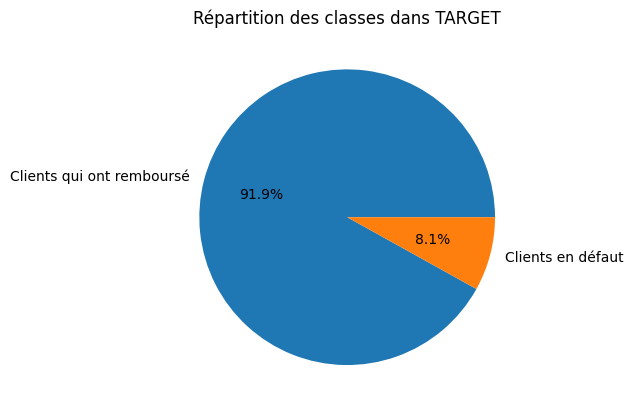

In [175]:
fig = plt.figure()
plt.pie(
    df_train["TARGET"].value_counts() / df_train.shape[0] * 100,
    autopct='%1.1f%%',
    labels=["Clients qui ont remboursé", "Clients en défaut"]
)
plt.title('Répartition des classes dans TARGET')
plt.show()

Le jeu de données présente une **forte disproportion entre les deux classes cibles** :

- `TARGET = 0` : clients qui **ont remboursé** leur prêt → **91.9 %**
- `TARGET = 1` : clients qui **n'ont pas remboursé** leur prêt → **8.1 %**

La difficulté de travailler avec des jeux de données déséquilibrés réside dans le fait que la plupart des techniques d'apprentissage automatique ignorent la classe minoritaire et, par conséquent, produisent de faibles performances sur celle-ci, alors que c'est généralement cette performance qui est la plus importante.

Nous allons comparer plusieurs approches pour gérer ce déséquilibre :

- **Baseline** (aucune stratégie particulière)
- **SMOTE** (oversampling synthétique de la classe minoritaire)
- **`scale_pos_weight`** (pondération intégrée dans LightGBM)

Le but est de déterminer laquelle **améliore le mieux la détection des clients à risque**, tout en conservant de bonnes performances globales.

##### **2.16.2. Modèle de référence - Baseline**

In [178]:
baseline = make_lgbm_pipeline(best_impute)

baseline_results = evaluate_cv(
    baseline, X, y,
    name=f"Baseline (imputer={best_impute})",
    tp_coeff=0.0,
    fp_coeff=-1.0,
    fn_coeff=-10.0
)


[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Total Bins 62068
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 546
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
[Baseline (imputer=mode)] Fold 1 — AUC=0.7757 | AP=0.2723 | Gain=-30863.0 | thr=0.060
[LightGBM] [Info] Number of positive: 19860, number of negative: 226149
[LightGBM] [Info] Total Bins 62117
[LightGBM] [Info] Number of data points in the train set: 246009, number of used features: 547
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432486
[LightGBM] [Info] Start training from score -2.432486
[Baseline (imputer=mode)] Fold 2 — AUC=0.7838 | AP=0.2793 | Gain=-30274.0 | thr=0.050
[LightGBM] [Info] Number of positive: 19860, number of negative: 226149
[LightGBM] [Info] Total Bins 62082
[LightGBM] [Info] Number of data points in the tr

,fold,auc_roc,ap_pr,gain@best_thr,best_thr,gain@0.5
0,3.0,0.780316,0.274556,-30507.8,0.052261,-47459.2


##### **2.16.3. Modèle avec gestion du déséquilibre via scale_pos_weight**

LightGBM permet de gérer le déséquilibre directement dans l’apprentissage grâce au paramètre `scale_pos_weight`. Ce dernier ajuste le poids de la classe minoritaire dans la fonction de perte pour lui donner plus d’importance. Il est généralement défini comme : `scale_pos_weight = nb_classes_majoritaires / nb_classes_minoritaires`, ce qui évite de modifier les données d’entraînement.

In [179]:
ratio = (y == 0).sum() / (y == 1).sum()
spw = min(max(ratio, 1.0), 12.0)  # borné pour éviter les dérives

In [180]:
spw_pipe = Pipeline(steps=[
    ("cleanup", FunctionTransformer(cleanup_inf_to_nan, validate=False)),
    ("imputer", SimpleImputer(strategy=("most_frequent" if best_impute=="mode" else best_impute))),
    ("lgbm", LGBMClassifier(
        n_estimators=5000,
        learning_rate=0.03,
        num_leaves=48,
        subsample=0.8,
        colsample_bytree=0.8,
        max_depth=-1,
        min_child_samples=50,
        random_state=42,
        n_jobs=-1,
        force_col_wise=True,
        scale_pos_weight=spw
    ))
])

spw_results = evaluate_cv(
    spw_pipe, X, y,
    name=f"LGBM scale_pos_weight={spw:.1f}",
    tp_coeff=0.0,
    fp_coeff=-1.0,
    fn_coeff=-10.0
)

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Total Bins 62068
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 546
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
[LGBM scale_pos_weight=11.4] Fold 1 — AUC=0.7575 | AP=0.2510 | Gain=-32229.0 | thr=0.261
[LightGBM] [Info] Number of positive: 19860, number of negative: 226149
[LightGBM] [Info] Total Bins 62117
[LightGBM] [Info] Number of data points in the train set: 246009, number of used features: 547
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432486
[LightGBM] [Info] Start training from score -2.432486
[LGBM scale_pos_weight=11.4] Fold 2 — AUC=0.7617 | AP=0.2565 | Gain=-32011.0 | thr=0.236
[LightGBM] [Info] Number of positive: 19860, number of negative: 226149
[LightGBM] [Info] Total Bins 62082
[LightGBM] [Info] Number of data points in 

,fold,auc_roc,ap_pr,gain@best_thr,best_thr,gain@0.5
0,3.0,0.760805,0.252064,-32074.6,0.246231,-37352.8


##### **2.16.4. Modèle avec gestion du déséquilibre via SMOTE**

Une approche pour gérer les jeux de données déséquilibrés consiste à suréchantillonner la classe minoritaire. La méthode la plus simple consiste à dupliquer des exemples dans la classe minoritaire, bien que ces exemples n'apportent aucune information nouvelle au modèle. De nouveaux exemples peuvent être synthétisés à partir des exemples existants. Il s'agit d'une forme d'augmentation des données pour la classe minoritaire, appelée technique de suréchantillonnage synthétique des minorités, ou SMOTE.

In [181]:
cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

smote_pipe = ImbPipeline(steps=[
    ("cleanup", FunctionTransformer(cleanup_inf_to_nan, validate=False)),
    ("imputer", SimpleImputer(strategy=("most_frequent" if best_impute=="mode" else best_impute))),
    ("smote", SMOTE(
        sampling_strategy=0.3,
        k_neighbors=5,
        random_state=42
    )),
    ("lgbm", LGBMClassifier(
        n_estimators=3000,
        learning_rate=0.03,
        num_leaves=48,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        force_col_wise=True
    ))
])

smote_results = evaluate_cv(
    smote_pipe, X, y,
    name="SMOTE + LGBM",
    cv=cv3,
    tp_coeff=0.0,
    fp_coeff=-1.0,
    fn_coeff=-10.0
)


[LightGBM] [Info] Number of positive: 56537, number of negative: 188457
[LightGBM] [Info] Total Bins 122126
[LightGBM] [Info] Number of data points in the train set: 244994, number of used features: 557
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.230769 -> initscore=-1.203975
[LightGBM] [Info] Start training from score -1.203975
[SMOTE + LGBM] Fold 1 — AUC=0.7817 | AP=0.2755 | Gain=-50801.0 | thr=0.070
[LightGBM] [Info] Number of positive: 56537, number of negative: 188457
[LightGBM] [Info] Total Bins 122875
[LightGBM] [Info] Number of data points in the train set: 244994, number of used features: 557
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.230769 -> initscore=-1.203975
[LightGBM] [Info] Start training from score -1.203975
[SMOTE + LGBM] Fold 2 — AUC=0.7810 | AP=0.2715 | Gain=-50821.0 | thr=0.065
[LightGBM] [Info] Number of positive: 56537, number of negative: 188458
[LightGBM] [Info] Total Bins 122109
[LightGBM] [Info] Number of data points in the train set: 244995, nu

,fold,auc_roc,ap_pr,gain@best_thr,best_thr,gain@0.5
0,2.0,0.78144,0.272456,-50939.666667,0.065327,-79171.666667


In [182]:
summary = pd.DataFrame({
    "Baseline": baseline_results.mean(numeric_only=True),
    "scale_pos_weight": spw_results.mean(numeric_only=True),
    "SMOTE": smote_results.mean(numeric_only=True)
}).T

summary.round(4)

,fold,auc_roc,ap_pr,gain@best_thr,best_thr,gain@0.5
Baseline,3.0,0.7803,0.2746,-30507.8000,0.0523,-47459.2000
scale_pos_weight,3.0,0.7608,0.2521,-32074.6000,0.2462,-37352.8000
SMOTE,2.0,0.7814,0.2725,-50939.6667,0.0653,-79171.6667


**Interprétation**
- **Baseline** offre le **meilleur compromis global** :  
  - Meilleure AUC et AP  
  - **Meilleur gain métier**, donc moins de pertes  
  - Seuil bas cohérent avec la rareté des défauts  
  → **C’est la stratégie optimale.**

- **scale_pos_weight** dégrade les performances :  
  - AUC et AP en baisse  
  - Modèle trop conservateur (seuil élevé)  
  - Gain plus faible → trop de bons clients refusés  

- **SMOTE** : bonne AUC mais **désastre métier**  
  - Sur-apprend les défauts synthétiques  
  - Beaucoup trop de faux négatifs → pertes massives  
  - À **éviter absolument** dans ce contexte

**Conclusion**
La stratégie **baseline sans rééquilibrage** reste la plus performante, tant sur les métriques classiques (AUC/AP) que sur le **coût métier**, qui est l’objectif principal du scoring crédit.  
`scale_pos_weight` n’apporte pas de valeur, et **SMOTE doit être exclu** en raison de son impact négatif majeur sur le gain métier.

In [184]:
results = []

for ratio in [0.1, 0.2, 0.3, 0.4]:
    for k in [3, 5, 7]:
        print(f"SMOTE sampling={ratio}, k={k}")
        smote_pipe = ImbPipeline(steps=[
            ("cleanup", FunctionTransformer(cleanup_inf_to_nan, validate=False)),
            ("imputer", SimpleImputer(strategy=("most_frequent" if best_impute=="mode" else best_impute))),
            ("smote", SMOTE(
                sampling_strategy=ratio, 
                k_neighbors=k, 
                random_state=42)),
            ("lgbm", LGBMClassifier(
                n_estimators=3000, 
                learning_rate=0.03, 
                num_leaves=48,
                subsample=0.8, 
                colsample_bytree=0.8,
                n_jobs=-1, 
                random_state=42, 
                force_col_wise=True
            ))
        ])
        smote_results_2 = evaluate_cv(smote_pipe, X, y, name=f"SMOTE r={ratio} k={k}", cv=cv3)

        smote_results_2["sampling_strategy"] = ratio
        smote_results_2["k_neighbors"] = k
        
        results.append(smote_results_2)

SMOTE sampling=0.1, k=3
[LightGBM] [Info] Number of positive: 18845, number of negative: 188457
[LightGBM] [Info] Total Bins 88683
[LightGBM] [Info] Number of data points in the train set: 207302, number of used features: 552
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.090906 -> initscore=-2.302622
[LightGBM] [Info] Start training from score -2.302622
[SMOTE r=0.1 k=3] Fold 1 — AUC=0.7819 | AP=0.2766 | Gain=-50720.0 | thr=0.070
[LightGBM] [Info] Number of positive: 18845, number of negative: 188457
[LightGBM] [Info] Total Bins 89374
[LightGBM] [Info] Number of data points in the train set: 207302, number of used features: 552
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.090906 -> initscore=-2.302622
[LightGBM] [Info] Start training from score -2.302622
[SMOTE r=0.1 k=3] Fold 2 — AUC=0.7803 | AP=0.2710 | Gain=-50756.0 | thr=0.060
[LightGBM] [Info] Number of positive: 18845, number of negative: 188458
[LightGBM] [Info] Total Bins 89088
[LightGBM] [Info] Number of data points i

,fold,auc_roc,ap_pr,gain@best_thr,best_thr,gain@0.5
0,2.0,0.781181,0.272294,-50732.666667,0.063652,-79071.0


SMOTE sampling=0.1, k=5
[LightGBM] [Info] Number of positive: 18845, number of negative: 188457
[LightGBM] [Info] Total Bins 88918
[LightGBM] [Info] Number of data points in the train set: 207302, number of used features: 551
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.090906 -> initscore=-2.302622
[LightGBM] [Info] Start training from score -2.302622
[SMOTE r=0.1 k=5] Fold 1 — AUC=0.7818 | AP=0.2774 | Gain=-50892.0 | thr=0.070
[LightGBM] [Info] Number of positive: 18845, number of negative: 188457
[LightGBM] [Info] Total Bins 89257
[LightGBM] [Info] Number of data points in the train set: 207302, number of used features: 551
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.090906 -> initscore=-2.302622
[LightGBM] [Info] Start training from score -2.302622
[SMOTE r=0.1 k=5] Fold 2 — AUC=0.7812 | AP=0.2714 | Gain=-50669.0 | thr=0.070
[LightGBM] [Info] Number of positive: 18845, number of negative: 188458
[LightGBM] [Info] Total Bins 89047
[LightGBM] [Info] Number of data points i

,fold,auc_roc,ap_pr,gain@best_thr,best_thr,gain@0.5
0,2.0,0.781327,0.272582,-50798.333333,0.068677,-79141.0


SMOTE sampling=0.1, k=7
[LightGBM] [Info] Number of positive: 18845, number of negative: 188457
[LightGBM] [Info] Total Bins 89184
[LightGBM] [Info] Number of data points in the train set: 207302, number of used features: 552
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.090906 -> initscore=-2.302622
[LightGBM] [Info] Start training from score -2.302622
[SMOTE r=0.1 k=7] Fold 1 — AUC=0.7812 | AP=0.2763 | Gain=-50848.0 | thr=0.065
[LightGBM] [Info] Number of positive: 18845, number of negative: 188457
[LightGBM] [Info] Total Bins 89362
[LightGBM] [Info] Number of data points in the train set: 207302, number of used features: 552
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.090906 -> initscore=-2.302622
[LightGBM] [Info] Start training from score -2.302622
[SMOTE r=0.1 k=7] Fold 2 — AUC=0.7806 | AP=0.2716 | Gain=-50829.0 | thr=0.065
[LightGBM] [Info] Number of positive: 18845, number of negative: 188458
[LightGBM] [Info] Total Bins 89298
[LightGBM] [Info] Number of data points i

,fold,auc_roc,ap_pr,gain@best_thr,best_thr,gain@0.5
0,2.0,0.780938,0.272638,-50811.0,0.065327,-79088.666667


SMOTE sampling=0.2, k=3
[LightGBM] [Info] Number of positive: 37691, number of negative: 188457
[LightGBM] [Info] Total Bins 115682
[LightGBM] [Info] Number of data points in the train set: 226148, number of used features: 555
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.166665 -> initscore=-1.609449
[LightGBM] [Info] Start training from score -1.609449
[SMOTE r=0.2 k=3] Fold 1 — AUC=0.7819 | AP=0.2772 | Gain=-50608.0 | thr=0.065
[LightGBM] [Info] Number of positive: 37691, number of negative: 188457
[LightGBM] [Info] Total Bins 116050
[LightGBM] [Info] Number of data points in the train set: 226148, number of used features: 554
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.166665 -> initscore=-1.609449
[LightGBM] [Info] Start training from score -1.609449
[SMOTE r=0.2 k=3] Fold 2 — AUC=0.7816 | AP=0.2720 | Gain=-50372.0 | thr=0.065
[LightGBM] [Info] Number of positive: 37691, number of negative: 188458
[LightGBM] [Info] Total Bins 115761
[LightGBM] [Info] Number of data point

,fold,auc_roc,ap_pr,gain@best_thr,best_thr,gain@0.5
0,2.0,0.781748,0.273379,-50616.666667,0.063652,-79184.666667


SMOTE sampling=0.2, k=5
[LightGBM] [Info] Number of positive: 37691, number of negative: 188457
[LightGBM] [Info] Total Bins 115858
[LightGBM] [Info] Number of data points in the train set: 226148, number of used features: 556
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.166665 -> initscore=-1.609449
[LightGBM] [Info] Start training from score -1.609449
[SMOTE r=0.2 k=5] Fold 1 — AUC=0.7816 | AP=0.2761 | Gain=-50875.0 | thr=0.065
[LightGBM] [Info] Number of positive: 37691, number of negative: 188457
[LightGBM] [Info] Total Bins 116116
[LightGBM] [Info] Number of data points in the train set: 226148, number of used features: 554
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.166665 -> initscore=-1.609449
[LightGBM] [Info] Start training from score -1.609449
[SMOTE r=0.2 k=5] Fold 2 — AUC=0.7807 | AP=0.2699 | Gain=-50772.0 | thr=0.065
[LightGBM] [Info] Number of positive: 37691, number of negative: 188458
[LightGBM] [Info] Total Bins 116373
[LightGBM] [Info] Number of data point

,fold,auc_roc,ap_pr,gain@best_thr,best_thr,gain@0.5
0,2.0,0.78112,0.271889,-50957.0,0.065327,-79220.0


SMOTE sampling=0.2, k=7
[LightGBM] [Info] Number of positive: 37691, number of negative: 188457
[LightGBM] [Info] Total Bins 115868
[LightGBM] [Info] Number of data points in the train set: 226148, number of used features: 557
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.166665 -> initscore=-1.609449
[LightGBM] [Info] Start training from score -1.609449
[SMOTE r=0.2 k=7] Fold 1 — AUC=0.7820 | AP=0.2794 | Gain=-50796.0 | thr=0.070
[LightGBM] [Info] Number of positive: 37691, number of negative: 188457
[LightGBM] [Info] Total Bins 116161
[LightGBM] [Info] Number of data points in the train set: 226148, number of used features: 555
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.166665 -> initscore=-1.609449
[LightGBM] [Info] Start training from score -1.609449
[SMOTE r=0.2 k=7] Fold 2 — AUC=0.7813 | AP=0.2700 | Gain=-50755.0 | thr=0.070
[LightGBM] [Info] Number of positive: 37691, number of negative: 188458
[LightGBM] [Info] Total Bins 116059
[LightGBM] [Info] Number of data point

,fold,auc_roc,ap_pr,gain@best_thr,best_thr,gain@0.5
0,2.0,0.781875,0.273302,-50795.0,0.068677,-79070.0


SMOTE sampling=0.3, k=3
[LightGBM] [Info] Number of positive: 56537, number of negative: 188457
[LightGBM] [Info] Total Bins 121997
[LightGBM] [Info] Number of data points in the train set: 244994, number of used features: 557
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.230769 -> initscore=-1.203975
[LightGBM] [Info] Start training from score -1.203975
[SMOTE r=0.3 k=3] Fold 1 — AUC=0.7825 | AP=0.2779 | Gain=-50586.0 | thr=0.065
[LightGBM] [Info] Number of positive: 56537, number of negative: 188457
[LightGBM] [Info] Total Bins 122588
[LightGBM] [Info] Number of data points in the train set: 244994, number of used features: 559
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.230769 -> initscore=-1.203975
[LightGBM] [Info] Start training from score -1.203975
[SMOTE r=0.3 k=3] Fold 2 — AUC=0.7824 | AP=0.2713 | Gain=-50437.0 | thr=0.060
[LightGBM] [Info] Number of positive: 56537, number of negative: 188458
[LightGBM] [Info] Total Bins 122046
[LightGBM] [Info] Number of data point

,fold,auc_roc,ap_pr,gain@best_thr,best_thr,gain@0.5
0,2.0,0.782492,0.273182,-50555.0,0.063652,-79186.0


SMOTE sampling=0.3, k=5
[LightGBM] [Info] Number of positive: 56537, number of negative: 188457
[LightGBM] [Info] Total Bins 122126
[LightGBM] [Info] Number of data points in the train set: 244994, number of used features: 557
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.230769 -> initscore=-1.203975
[LightGBM] [Info] Start training from score -1.203975
[SMOTE r=0.3 k=5] Fold 1 — AUC=0.7817 | AP=0.2755 | Gain=-50801.0 | thr=0.070
[LightGBM] [Info] Number of positive: 56537, number of negative: 188457
[LightGBM] [Info] Total Bins 122875
[LightGBM] [Info] Number of data points in the train set: 244994, number of used features: 557
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.230769 -> initscore=-1.203975
[LightGBM] [Info] Start training from score -1.203975
[SMOTE r=0.3 k=5] Fold 2 — AUC=0.7810 | AP=0.2715 | Gain=-50821.0 | thr=0.065
[LightGBM] [Info] Number of positive: 56537, number of negative: 188458
[LightGBM] [Info] Total Bins 122109
[LightGBM] [Info] Number of data point

,fold,auc_roc,ap_pr,gain@best_thr,best_thr,gain@0.5
0,2.0,0.78144,0.272456,-50939.666667,0.065327,-79171.666667


SMOTE sampling=0.3, k=7
[LightGBM] [Info] Number of positive: 56537, number of negative: 188457
[LightGBM] [Info] Total Bins 122525
[LightGBM] [Info] Number of data points in the train set: 244994, number of used features: 558
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.230769 -> initscore=-1.203975
[LightGBM] [Info] Start training from score -1.203975
[SMOTE r=0.3 k=7] Fold 1 — AUC=0.7822 | AP=0.2781 | Gain=-50653.0 | thr=0.065
[LightGBM] [Info] Number of positive: 56537, number of negative: 188457
[LightGBM] [Info] Total Bins 122776
[LightGBM] [Info] Number of data points in the train set: 244994, number of used features: 557
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.230769 -> initscore=-1.203975
[LightGBM] [Info] Start training from score -1.203975
[SMOTE r=0.3 k=7] Fold 2 — AUC=0.7826 | AP=0.2706 | Gain=-50270.0 | thr=0.065
[LightGBM] [Info] Number of positive: 56537, number of negative: 188458
[LightGBM] [Info] Total Bins 121985
[LightGBM] [Info] Number of data point

,fold,auc_roc,ap_pr,gain@best_thr,best_thr,gain@0.5
0,2.0,0.782265,0.272335,-50650.0,0.063652,-79247.666667


SMOTE sampling=0.4, k=3
[LightGBM] [Info] Number of positive: 75382, number of negative: 188457
[LightGBM] [Info] Total Bins 125159
[LightGBM] [Info] Number of data points in the train set: 263839, number of used features: 557
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.285712 -> initscore=-0.916301
[LightGBM] [Info] Start training from score -0.916301
[SMOTE r=0.4 k=3] Fold 1 — AUC=0.7812 | AP=0.2772 | Gain=-50827.0 | thr=0.070
[LightGBM] [Info] Number of positive: 75382, number of negative: 188457
[LightGBM] [Info] Total Bins 124870
[LightGBM] [Info] Number of data points in the train set: 263839, number of used features: 559
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.285712 -> initscore=-0.916301
[LightGBM] [Info] Start training from score -0.916301
[SMOTE r=0.4 k=3] Fold 2 — AUC=0.7810 | AP=0.2696 | Gain=-50726.0 | thr=0.065
[LightGBM] [Info] Number of positive: 75383, number of negative: 188458
[LightGBM] [Info] Total Bins 125232
[LightGBM] [Info] Number of data point

,fold,auc_roc,ap_pr,gain@best_thr,best_thr,gain@0.5
0,2.0,0.781164,0.272372,-50963.0,0.068677,-79229.666667


SMOTE sampling=0.4, k=5
[LightGBM] [Info] Number of positive: 75382, number of negative: 188457
[LightGBM] [Info] Total Bins 124736
[LightGBM] [Info] Number of data points in the train set: 263839, number of used features: 557
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.285712 -> initscore=-0.916301
[LightGBM] [Info] Start training from score -0.916301
[SMOTE r=0.4 k=5] Fold 1 — AUC=0.7825 | AP=0.2776 | Gain=-50774.0 | thr=0.065
[LightGBM] [Info] Number of positive: 75382, number of negative: 188457
[LightGBM] [Info] Total Bins 125058
[LightGBM] [Info] Number of data points in the train set: 263839, number of used features: 558
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.285712 -> initscore=-0.916301
[LightGBM] [Info] Start training from score -0.916301
[SMOTE r=0.4 k=5] Fold 2 — AUC=0.7820 | AP=0.2693 | Gain=-50240.0 | thr=0.070
[LightGBM] [Info] Number of positive: 75383, number of negative: 188458
[LightGBM] [Info] Total Bins 125174
[LightGBM] [Info] Number of data point

,fold,auc_roc,ap_pr,gain@best_thr,best_thr,gain@0.5
0,2.0,0.782196,0.272721,-50620.0,0.068677,-79193.333333


SMOTE sampling=0.4, k=7
[LightGBM] [Info] Number of positive: 75382, number of negative: 188457
[LightGBM] [Info] Total Bins 124832
[LightGBM] [Info] Number of data points in the train set: 263839, number of used features: 558
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.285712 -> initscore=-0.916301
[LightGBM] [Info] Start training from score -0.916301
[SMOTE r=0.4 k=7] Fold 1 — AUC=0.7825 | AP=0.2778 | Gain=-50612.0 | thr=0.075
[LightGBM] [Info] Number of positive: 75382, number of negative: 188457
[LightGBM] [Info] Total Bins 124933
[LightGBM] [Info] Number of data points in the train set: 263839, number of used features: 558
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.285712 -> initscore=-0.916301
[LightGBM] [Info] Start training from score -0.916301
[SMOTE r=0.4 k=7] Fold 2 — AUC=0.7811 | AP=0.2706 | Gain=-50642.0 | thr=0.065
[LightGBM] [Info] Number of positive: 75383, number of negative: 188458
[LightGBM] [Info] Total Bins 125066
[LightGBM] [Info] Number of data point

,fold,auc_roc,ap_pr,gain@best_thr,best_thr,gain@0.5
0,2.0,0.781792,0.273352,-50694.333333,0.068677,-79124.333333


In [185]:
res = pd.concat(results, ignore_index=True)

k_neighbors,3,5,7
sampling_strategy,,,
0.1,-50732.666667,-50798.333333,-50811.000000
0.2,-50616.666667,-50957.000000,-50795.000000
0.3,-50555.000000,-50939.666667,-50650.000000
0.4,-50963.000000,-50620.000000,-50694.333333


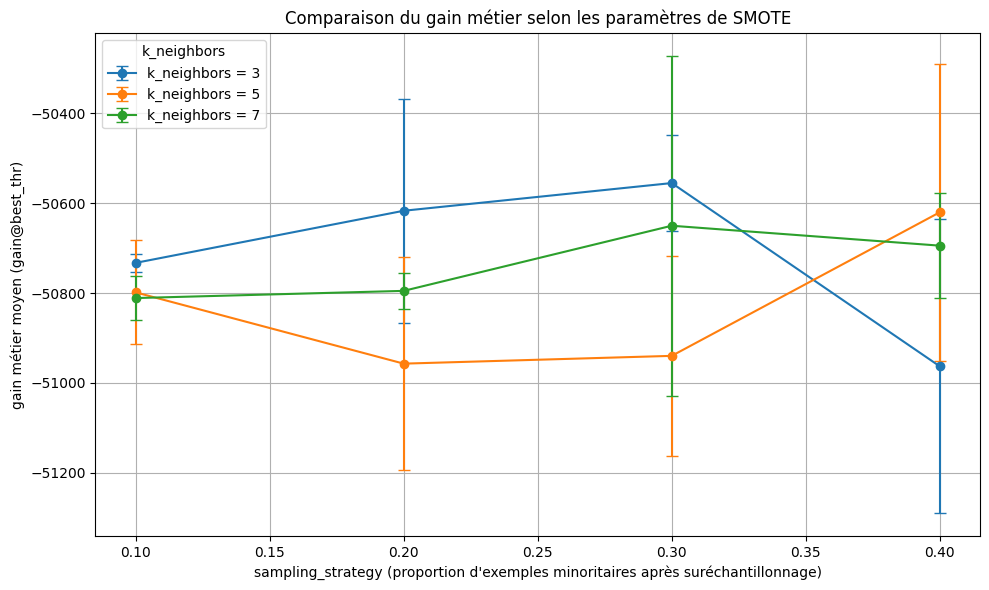

[TOP gain@best_thr]     {'sampling_strategy': 0.3, 'k_neighbors': 3.0, 'gain_mean': -50555.0, 'gain_std': 105.95753866525968, 'auc_mean': 0.7824915299163478, 'ap_mean': 0.2731822214863422, 'n': 3.0}
[TOP AUC ROC moyen]     {'sampling_strategy': 0.3, 'k_neighbors': 3.0, 'gain_mean': -50555.0, 'gain_std': 105.95753866525968, 'auc_mean': 0.7824915299163478, 'ap_mean': 0.2731822214863422, 'n': 3.0}
[TOP AP (AUC-PR) moy.]  {'sampling_strategy': 0.2, 'k_neighbors': 3.0, 'gain_mean': -50616.666666666664, 'gain_std': 249.1130934602471, 'auc_mean': 0.781747947579223, 'ap_mean': 0.27337884471737756, 'n': 3.0}


In [186]:
# Assure-toi que les colonnes sont bien du bon type
res["sampling_strategy"] = res["sampling_strategy"].astype(float)
res["k_neighbors"]       = res["k_neighbors"].astype(int)

# 1) Agrégation par couple (sampling_strategy, k_neighbors)
agg = (
    res.groupby(["sampling_strategy", "k_neighbors"], as_index=False)
       .agg(
           gain_mean=("gain@best_thr", "mean"),
           gain_std =("gain@best_thr", "std"),
           auc_mean =("auc_roc", "mean"),
           ap_mean  =("ap_pr", "mean"),
           n        =("fold", "count")
       )
       .sort_values(["k_neighbors", "sampling_strategy"])
)

# 2) Tableau large pour visualiser la moyenne du gain
pivot = agg.pivot(index="sampling_strategy", columns="k_neighbors", values="gain_mean")
display(pivot)

# 3) Courbe avec barres d’erreur (écart-type entre folds)
plt.figure(figsize=(10, 6))
for k, sub in agg.groupby("k_neighbors"):
    plt.errorbar(
        sub["sampling_strategy"], sub["gain_mean"],
        yerr=sub["gain_std"], marker="o", capsize=4, label=f"k_neighbors = {k}"
    )

plt.title("Comparaison du gain métier selon les paramètres de SMOTE")
plt.xlabel("sampling_strategy (proportion d'exemples minoritaires après suréchantillonnage)")
plt.ylabel("gain métier moyen (gain@best_thr)")
plt.legend(title="k_neighbors")
plt.grid(True)
plt.tight_layout()
plt.show()

# 4) Optionnel : trouver le meilleur couple selon plusieurs critères
best_gain   = agg.loc[agg["gain_mean"].idxmax()]
best_auc    = agg.loc[agg["auc_mean"].idxmax()]
best_ap     = agg.loc[agg["ap_mean"].idxmax()]

print("[TOP gain@best_thr]    ", best_gain.to_dict())
print("[TOP AUC ROC moyen]    ", best_auc.to_dict())
print("[TOP AP (AUC-PR) moy.] ", best_ap.to_dict())


In [187]:
print(smote_results_2.to_string(index=False))

 fold  auc_roc    ap_pr  gain@best_thr  best_thr  gain@0.5  sampling_strategy  k_neighbors
    1 0.782547 0.277835       -50612.0  0.075377  -79034.0                0.4            7
    2 0.781075 0.270580       -50642.0  0.065327  -79216.0                0.4            7
    3 0.781755 0.271642       -50829.0  0.065327  -79123.0                0.4            7


In [188]:
print("Seuil optimal moyen :", smote_results_2["best_thr"].mean())

Seuil optimal moyen : 0.06867671691792294


Analyse des performances SMOTE selon `sampling_strategy` et `k_neighbors`

L’objectif était d’évaluer si certains réglages de SMOTE permettaient d'améliorer le gain métier tout en préservant de bonnes performances de classification.  
Les combinaisons testées couvrent :

- `sampling_strategy` ∈ {0.1, 0.2, 0.3, 0.4}  
- `k_neighbors` ∈ {3, 5, 7}

Les résultats moyens du **gain métier (gain@best_thr)** montrent que **aucune configuration n’apporte une amélioration par rapport au modèle Baseline**, et toutes restent très déficitaires.

| sampling_strategy | k=3 | k=5 | k=7 |
|------------------|-------|-------|-------|
| **0.1** | -50 733 | -50 798 | -50 811 |
| **0.2** | -50 617 | -50 957 | -50 795 |
| **0.3** | **-50 555** ⭐ | -50 940 | -50 650 |
| **0.4** | -50 963 | -50 620 | -50 694 |

Meilleure configuration SMOTE
- **sampling_strategy = 0.3**
- **k_neighbors = 3**
- **gain moyen : -50 555** (toujours très dégradé)
- **AUC : 0.7825**
- **AP : 0.2732**

Même la meilleure configuration reste :
- bien **pire que la baseline** en gain métier (-30 508),  
- très instable selon le fold (écart-type ≈ 106),  
- et seulement légèrement meilleure en AUC/AP (mais ce gain ne compense pas la perte métier).

Conclusion
- **SMOTE n’est pas adapté** à ce problème de scoring crédit.  
- L’oversampling synthétique provoque :
  - une **sur-représentation artificielle** des mauvais payeurs,
  - une **dégradation massive du gain métier**, signe d'une explosion des faux négatifs ou d’une mauvaise calibration des probabilités,
  - une **stabilité médiocre** selon les folds.

**À exclure dans la suite du projet.**  
La stratégie **baseline** reste clairement la plus performante et la plus rentable.



concernant ap_pr : Si au hasard on prédisait toujours TARGET=0, ap_pr serait autour de la prévalence de la classe 1, donc environ 0.08. Le score de 0.2787 est donc plus de 3 fois meilleur que le random dans ce contexte !

En moyenne, quand le modèle prédit un client comme risqué, il a raison 27,87 % du temps.

#### **2.17. Feature importance (CV) + prune corrélations**

Dans cette section, nous allons :
- Mesurer l’importance des variables selon LightGBM (critère gain).
- Identifier les variables réellement influentes pour la prédiction du défaut (TARGET = 1).
- Supprimer les variables trop corrélées entre elles pour réduire la redondance et l’overfitting.
- Construire un dataset final épuré, prêt pour la modélisation avancée et MLflow.

L’objectif est d’obtenir un ensemble de features robuste, interprétable et non redondan

In [189]:
# Fonction utilitaire : nettoyer les noms de colonnes
def _make_safe_names(cols):
    safe, counts, mapping = [], {}, {}
    for orig in cols:
        base = re.sub(r'[^A-Za-z0-9_]', '_', str(orig))
        base = re.sub(r'_+', '_', base).strip('_') or 'col'
        name = base
        while name in counts:
            counts[base] = counts.get(base, 1) + 1
            name = f"{base}_{counts[base]}"
        counts[name] = 1
        safe.append(name)
        mapping[name] = orig
    return safe, mapping

# Fonction principale
def feature_importance_lightgbm(df, num_folds=7, stratified=False, random_state=1001):

    # 1) Préparation des données
    train_df = df[df["TARGET"].notnull()].copy().reset_index(drop=True)
    drop_cols = {"TARGET", "SK_ID_CURR", "SK_ID_BUREAU", "SK_ID_PREV", "index"}
    feats = [c for c in train_df.columns if c not in drop_cols]

    X_all = train_df[feats].select_dtypes(include=[np.number, "bool"]).copy()
    y_all = train_df["TARGET"].astype(int)

    # 2) Nettoyage des noms
    safe_names, mapping = _make_safe_names(X_all.columns)
    X_all.columns = safe_names

    # 3) Définition des folds
    folds = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=random_state)

    # 4) Boucle CV
    all_fi = []
    for fold_idx, (tr_idx, va_idx) in enumerate(folds.split(X_all, y_all), 1):
        X_tr, X_va = X_all.iloc[tr_idx], X_all.iloc[va_idx]
        y_tr, y_va = y_all.iloc[tr_idx], y_all.iloc[va_idx]

        clf = LGBMClassifier(
            n_estimators=5000,
            learning_rate=0.03,
            num_leaves=48,
            subsample=0.8,
            colsample_bytree=0.8,
            force_col_wise=True,
            n_jobs=-1,
            random_state=random_state
        )

        clf.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            eval_metric="auc",
            callbacks=[early_stopping(200), log_evaluation(period=0)]
        )

        booster = clf.booster_
        gains = booster.feature_importance(importance_type="gain")
        names = booster.feature_name()
        names_orig = [mapping[n] for n in names]

        fi_fold = pd.DataFrame({
            "feature": names_orig,
            "gain": gains,
            "fold": fold_idx
        })
        all_fi.append(fi_fold)

    fi_per_fold = pd.concat(all_fi, axis=0)
    fi_mean = fi_per_fold.groupby("feature", as_index=False)["gain"].mean().sort_values("gain", ascending=False)

    return fi_mean, fi_per_fold


In [190]:
fi_mean, fi_per_fold = feature_importance_lightgbm(df_train, num_folds=7)
fi_mean.to_csv("data/processed/feature_importance_lightgbm.csv", index=False)
fi_mean.head(20)

[LightGBM] [Info] Number of positive: 21278, number of negative: 242302
[LightGBM] [Info] Total Bins 62233
[LightGBM] [Info] Number of data points in the train set: 263580, number of used features: 586
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080727 -> initscore=-2.432511
[LightGBM] [Info] Start training from score -2.432511
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[746]	valid_0's auc: 0.78545	valid_0's binary_logloss: 0.237861
[LightGBM] [Info] Number of positive: 21278, number of negative: 242303
[LightGBM] [Info] Total Bins 62278
[LightGBM] [Info] Number of data points in the train set: 263581, number of used features: 586
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080727 -> initscore=-2.432515
[LightGBM] [Info] Start training from score -2.432515
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[741]	valid_0's auc: 0.781986	valid_0's binary_logloss: 0.238338
[Ligh

,feature,gain
164,EXT_SOURCE_3,99618.557903
163,EXT_SOURCE_2,94342.540220
162,EXT_SOURCE_1,33245.912749
369,PAYMENT_RATE,25128.926846
145,DAYS_EMPLOYED,14904.919586
144,DAYS_BIRTH,11081.209213
22,AMT_ANNUITY,9807.148183
227,INSTAL_DPD_MEAN,9285.908871
147,DAYS_EMPLOYED_PERC,7391.733653
416,PREV_CNT_PAYMENT_MEAN,7383.517285


Comment fonctionne la feature importance dans LightGBM (par "gain") ?

Quand LightGBM construit ses arbres de décision, il choisit à chaque nœud une variable pour faire un split.
Il choisit la variable qui réduit le plus l’erreur (ou l’impureté) à cet endroit de l’arbre. Cette réduction d’erreur s’appelle le "gain".

À chaque split :
- Il teste plusieurs variables.
- Il garde celle qui sépare le mieux les classes (bons vs mauvais clients).
- Il additionne le gain apporté par cette variable à chaque fois qu’elle est utilisée

En résumé :
- Plus une variable est utilisée dans les arbres avec un gros gain,
- Plus sa "feature importance" est élevée.

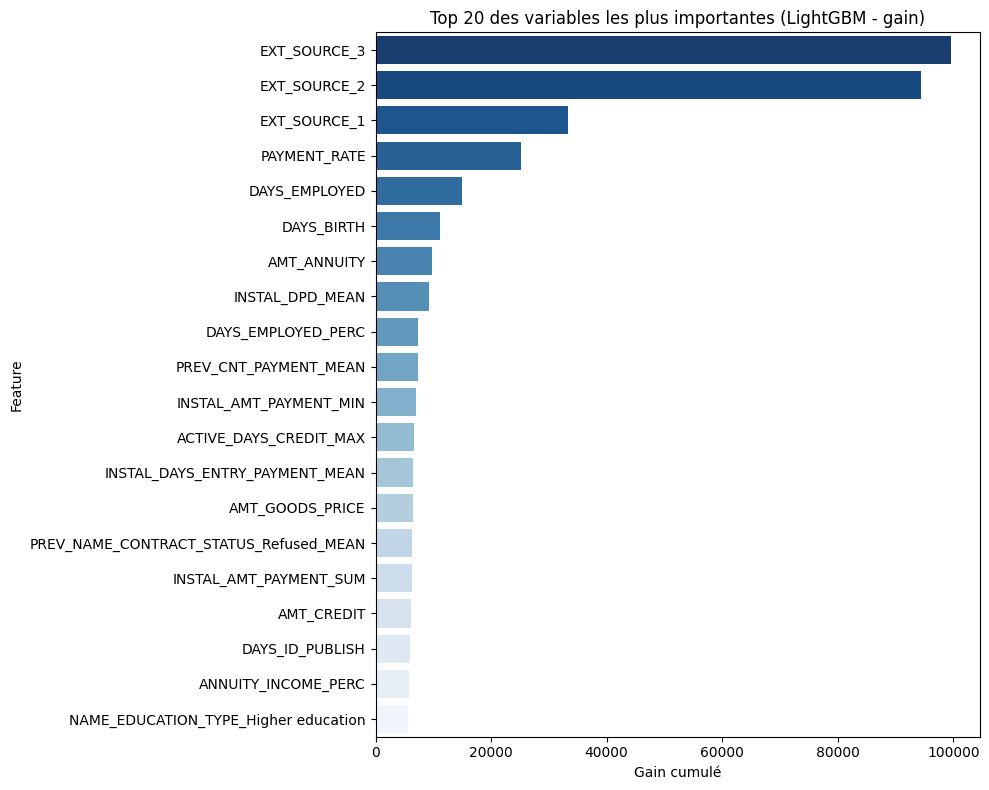

In [191]:
# Affiche les 20 features les plus importantes
plt.figure(figsize=(10, 8))
sns.barplot(
    data=fi_mean.head(20),
    y="feature",
    x="gain",
    palette="Blues_r"
)
plt.title("Top 20 des variables les plus importantes (LightGBM - gain)")
plt.xlabel("Gain cumulé")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


Les variables `EXT_SOURCE_1`, `EXT_SOURCE_2` et `EXT_SOURCE_3` apportent le plus de réduction d’impureté dans les arbres → elles sont très prédictives.

Ensuite viennent des variables liées :
- au montant du prêt ou de l’annuité (`AMT_ANNUITY`, `AMT_CREDIT`)
- à l’âge, l’emploi, ou l’historique de crédit
- à des dérivées calculées comme `PAYMENT_RATE` ou `DAYS_EMPLOYED_PERC`

Le modèle fait du sens économiquement :
il s’appuie majoritairement sur des indicateurs de solvabilité externes, d’endettement et d’historique de paiement, cohérents avec la logique d’un scoring crédit.

Les datasets enrichis contiennent des centaines de variables, souvent corrélées :
- `AMT_CREDIT` vs. `AMT_GOODS_PRICE`
- `PAYMENT_RATE` vs. `ANNUITY_INCOME_PERC`
- Ratios et dérivées entre elles

Objectif :
- Garder les variables les plus importantes
- Éliminer les doublons informationnels
- Réduire l’overfitting
- Accélérer l’entraînement

In [192]:
# Prune corrélations fortes dans le Top-K
TOP_K = 200
THRESH = 0.60

# On travaille uniquement avec df_train
df_train_clean = df_train.copy()

best_features = (
    fi_mean.rename(columns={"gain": "importance"})
           .loc[fi_mean["feature"].isin(df_train.columns)]
           .sort_values("importance", ascending=False)
           .head(TOP_K)
           .set_index("feature")
)


In [193]:
# On récupère la liste des colonnes numériques parmi les top features
cols = df_train_clean[best_features.index].select_dtypes(include=[np.number, "bool"]).columns.tolist()
# On calcule la matrice de corrélation sur ces colonnes numériques
corr = df_train_clean[cols].corr(numeric_only=True).abs()
# upper est une version filtrée de corr, plus pratique pour trouver les paires très corrélées sans doublons
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

In [194]:
pairs_df = (
    upper.stack().rename("corr").reset_index()
         .query("corr > @THRESH")
         .rename(columns={"level_0": "feature1", "level_1": "feature2"})
)

In [195]:
# Initialises un set pour stocker les noms des colonnes à retirer
features_to_remove = set()

# On parcoure chaque paire de variables fortement corrélées identifiée dans pairs_df
for _, row in pairs_df.iterrows():
    # On récupère les noms des deux colonnes concernées dans cette paire
    f1, f2 = row['feature1'], row['feature2']
    # On regarde leur importance moyenne
    # Si une des deux n’est pas dans best_features, on lui attribue une importance très basse (-inf), donc elle sera automatiquement retirée
    imp1 = best_features.loc[f1, 'importance'] if f1 in best_features.index else -np.inf
    imp2 = best_features.loc[f2, 'importance'] if f2 in best_features.index else -np.inf
    # On garde la feature avec la plus grande importance et retires l’autre
    if imp1 < imp2: features_to_remove.add(f1)
    else: features_to_remove.add(f2)

In [196]:
# Liste des variables à garder
features_keep = [f for f in best_features.index if f not in features_to_remove]
print(f"Prune: {len(best_features)} -> {len(features_keep)} (|corr|>{THRESH})")


Prune: 200 -> 85 (|corr|>0.6)


In [197]:
features_keep

['EXT_SOURCE_3',
 'EXT_SOURCE_2',
 'EXT_SOURCE_1',
 'PAYMENT_RATE',
 'DAYS_EMPLOYED',
 'AMT_ANNUITY',
 'INSTAL_DPD_MEAN',
 'PREV_CNT_PAYMENT_MEAN',
 'INSTAL_AMT_PAYMENT_MIN',
 'ACTIVE_DAYS_CREDIT_MAX',
 'INSTAL_DAYS_ENTRY_PAYMENT_MEAN',
 'PREV_NAME_CONTRACT_STATUS_Refused_MEAN',
 'INSTAL_AMT_PAYMENT_SUM',
 'DAYS_ID_PUBLISH',
 'ANNUITY_INCOME_PERC',
 'NAME_EDUCATION_TYPE_Higher education',
 'BURO_DAYS_CREDIT_MEAN',
 'POS_MONTHS_BALANCE_SIZE',
 'BURO_AMT_CREDIT_MAX_OVERDUE_MEAN',
 'DAYS_REGISTRATION',
 'PREV_APP_CREDIT_PERC_MEAN',
 'ACTIVE_DAYS_CREDIT_ENDDATE_MIN',
 'BURO_AMT_CREDIT_SUM_DEBT_MEAN',
 'INSTAL_DAYS_ENTRY_PAYMENT_SUM',
 'INSTAL_PAYMENT_PERC_MEAN',
 'INCOME_CREDIT_PERC',
 'DAYS_LAST_PHONE_CHANGE',
 'POS_SK_DPD_DEF_MEAN',
 'APPROVED_AMT_DOWN_PAYMENT_MAX',
 'CODE_GENDER_F',
 'INSTAL_DBD_MEAN',
 'CLOSED_DAYS_CREDIT_ENDDATE_MAX',
 'INSTAL_PAYMENT_DIFF_MEAN',
 'INSTAL_AMT_PAYMENT_MEAN',
 'INSTAL_DBD_MAX',
 'BURO_CREDIT_TYPE_Microloan_MEAN',
 'CLOSED_DAYS_CREDIT_VAR',
 'APPROVED_AM

Résultats :
- 116 variables ont été jugées trop corrélées avec d’autres plus informatives.
- On conserve 84 variables non redondantes, ce qui :
    - Réduit la complexité du modèle,
    - Diminue le risque d’overfitting,
    - Et accélère l’entraînement.

<class 'pandas.core.frame.DataFrame'>
Index: 307511 entries, 0 to 307510
Data columns (total 86 columns):
 #   Column                                           Non-Null Count   Dtype  
---  ------                                           --------------   -----  
 0   EXT_SOURCE_3                                     246546 non-null  float64
 1   EXT_SOURCE_2                                     306851 non-null  float64
 2   EXT_SOURCE_1                                     134133 non-null  float64
 3   PAYMENT_RATE                                     307499 non-null  float64
 4   DAYS_EMPLOYED                                    252137 non-null  float64
 5   AMT_ANNUITY                                      307499 non-null  float64
 6   INSTAL_DPD_MEAN                                  291635 non-null  float64
 7   PREV_CNT_PAYMENT_MEAN                            290642 non-null  float64
 8   INSTAL_AMT_PAYMENT_MIN                           291635 non-null  float64
 9   ACTIVE_DAYS_CREDIT_M

<Axes: >

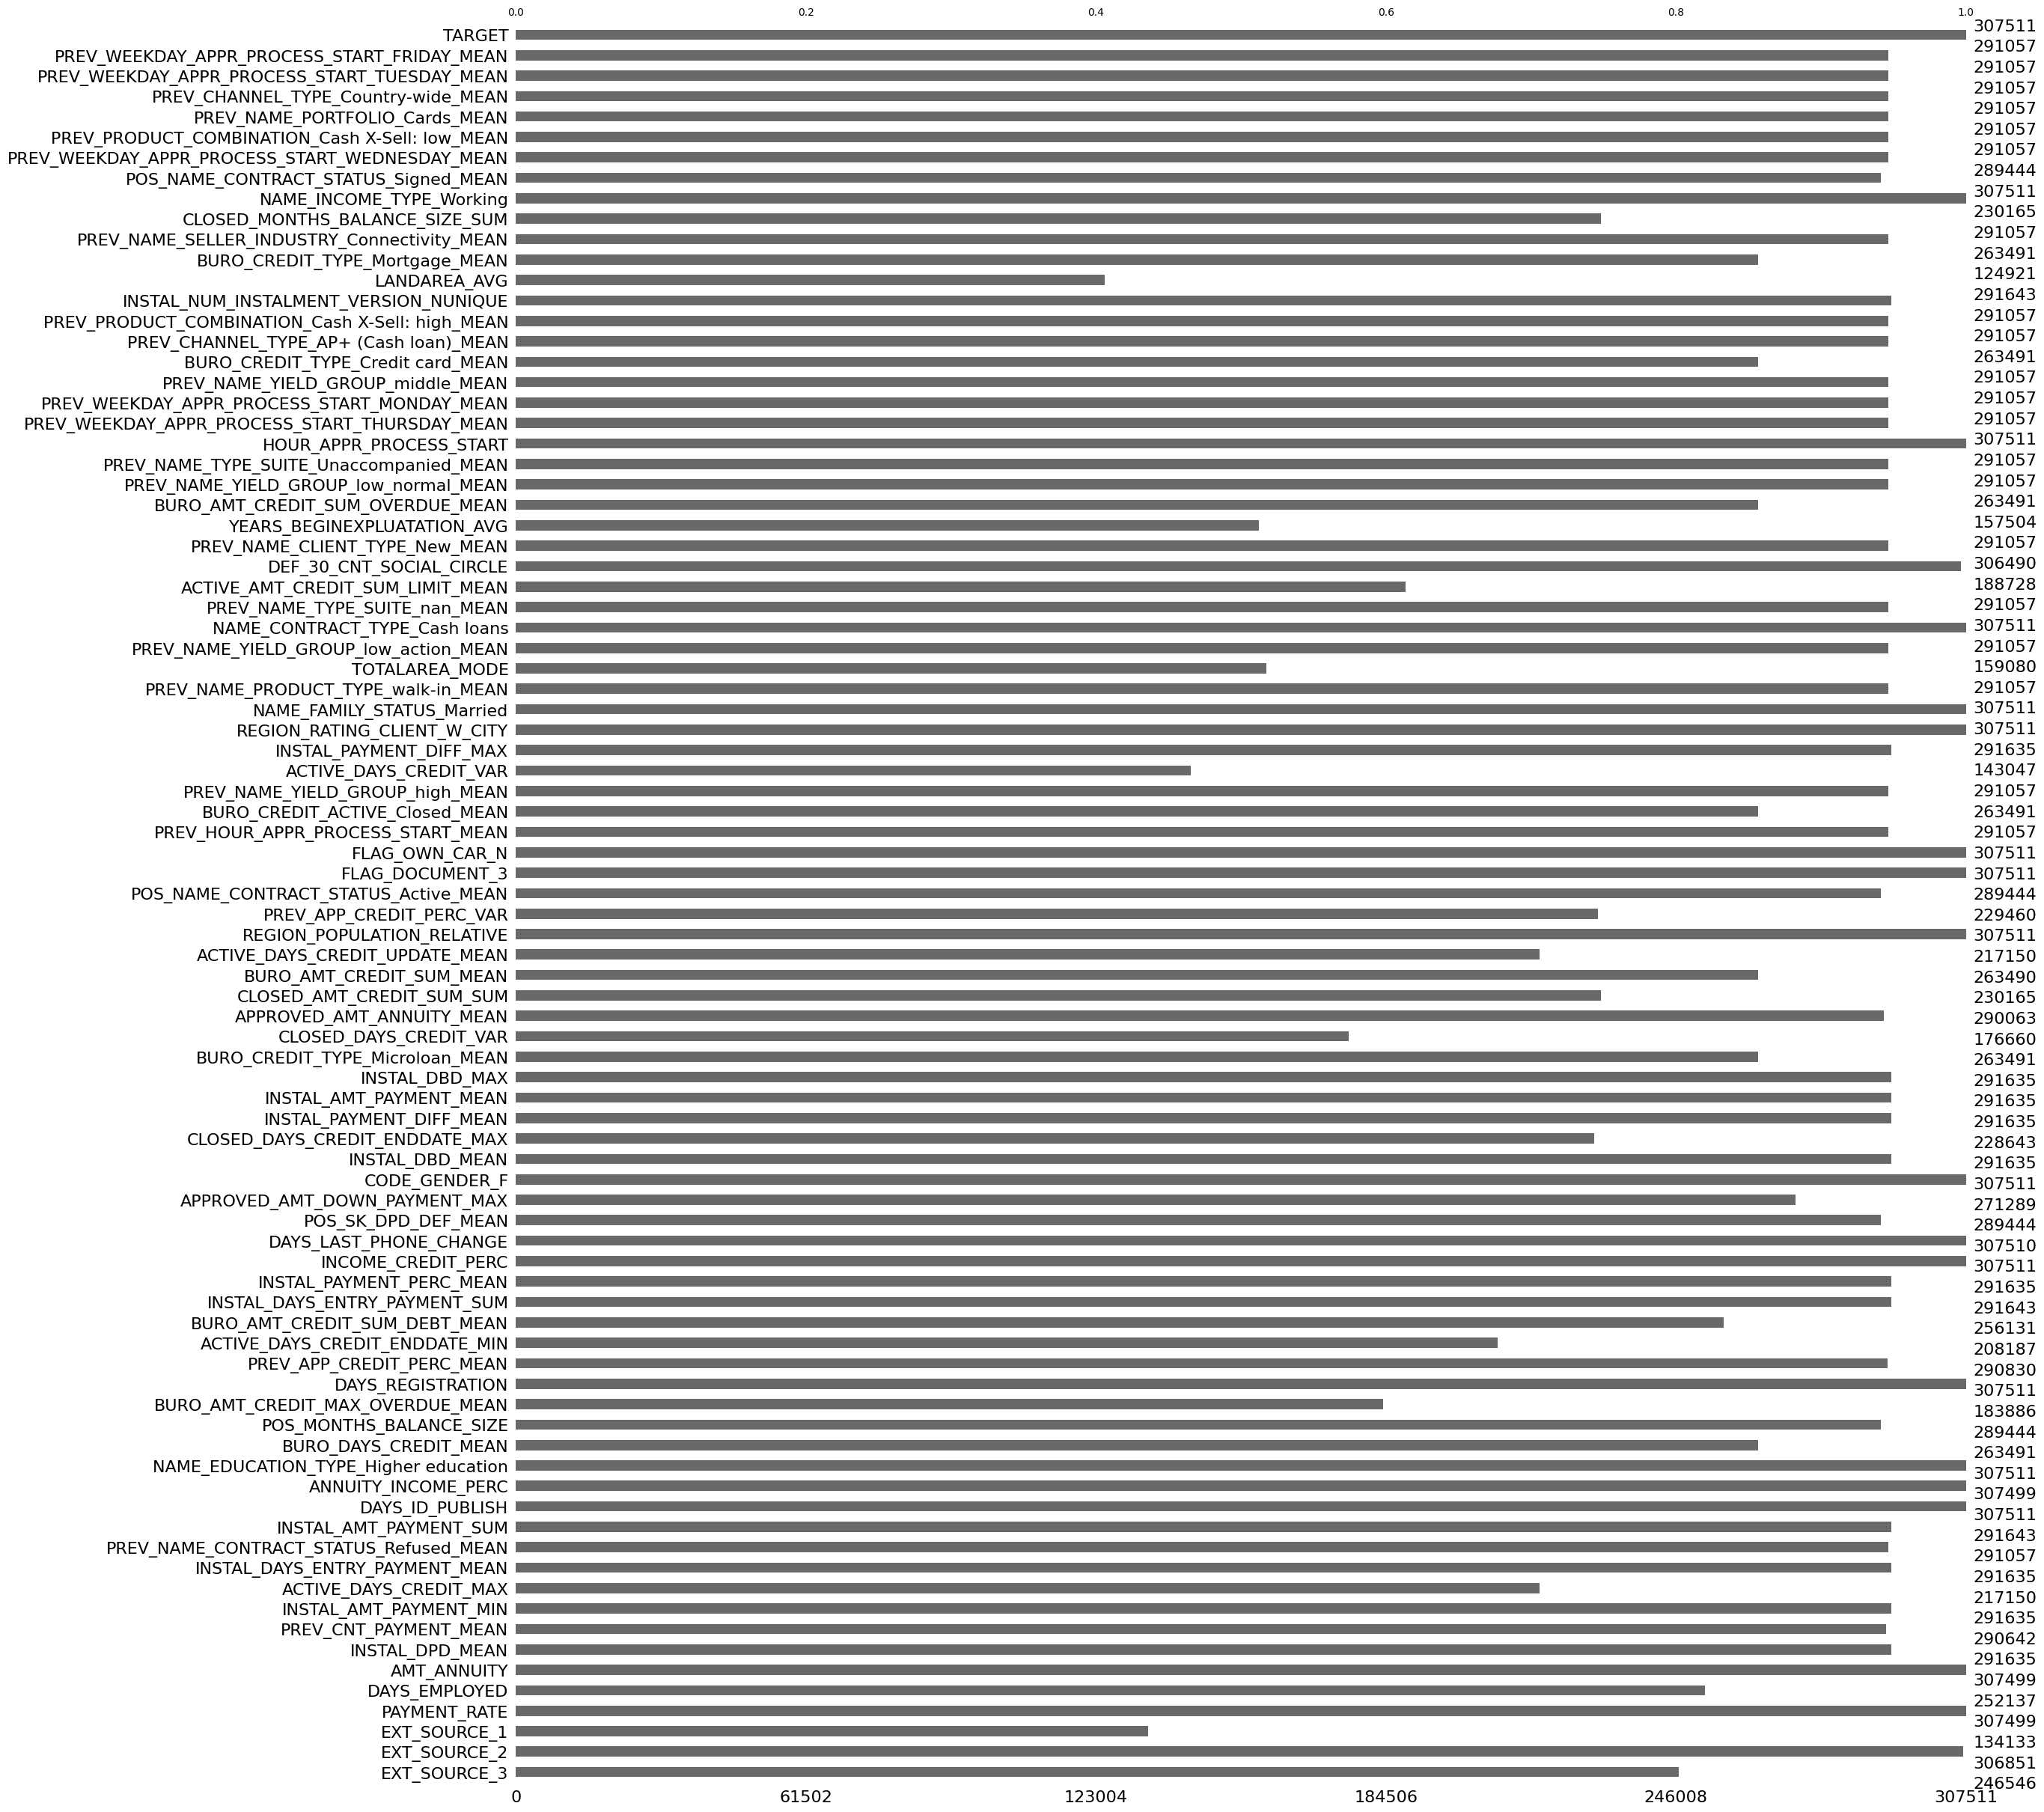

In [198]:
ls_features = [f for f in features_keep if f in df_train.columns]
ls_features.append("TARGET")

df_train_filtered = df_train.loc[:, ls_features].copy()
df_train_filtered.to_csv("data/processed/df_train_filtered.csv", index=False)

df_train_filtered.info()
msno.bar(df_train_filtered)


#### **2.18. Finalisation “pré-modélisation”**

- Définition de la liste finale des features

In [199]:
# Exclure TARGET, SK_ID_CURR et autres colonnes techniques
FEATURES = [c for c in df_train_filtered.columns 
            if c not in ["TARGET", "SK_ID_CURR"]]

len(FEATURES)

85

- Séparation X/y

In [200]:
# Variables explicatives et cible
X = df_train_filtered[FEATURES].select_dtypes(include=[np.number, "bool"]).copy()
y = df_train_filtered["TARGET"].astype(int).values

print(X.shape, y.shape)


(307511, 85) (307511,)


- Pipeline final LightGBM

In [201]:
# On retient: imputation gagnante + pipeline baseline pour la suite (MLflow)
BEST_IMPUTE = best_impute

base_pipeline = Pipeline([
    ("cleanup", FunctionTransformer(cleanup_inf_to_nan, validate=False)),

    ("imputer", SimpleImputer(
        strategy=("most_frequent" if BEST_IMPUTE == "mode" else BEST_IMPUTE)
    )),

    ("model", LGBMClassifier(
        n_estimators=5000,
        learning_rate=0.03,
        num_leaves=48,
        subsample=0.8,
        colsample_bytree=0.8,
        max_depth=-1,
        min_child_samples=50,
        n_jobs=-1,
        random_state=42,
        force_col_wise=True
    ))
])

print("Préparation terminée. Pipeline de base prêt pour MLflow.")

Préparation terminée. Pipeline de base prêt pour MLflow.


### **3. Modélisation** 

Dans cette section, nous comparons plusieurs modèles, sélectionnons le meilleur candidat, maitrisons son apprentissage, puis construisons un pipeline de production reproductible compatible MLFlow et API. 

Nous utilisons MLFlow dès les baselines, pour que chaque tentative soit loggée, comparée et justifiée. 

#### **3.1. Chargement des données & split train/validation**

In [264]:
# ---- Chargement du dataset filtré ----
df = pd.read_csv("data/processed/df_train_filtered.csv")
print("Shape total df_train_filtered :", df.shape)

Shape total df_train_filtered : (307511, 86)


In [265]:
# ---- Séparation X / y ----
y = df_train_filtered["TARGET"].astype(int)
X = df_train_filtered.drop(columns=["TARGET"]).copy()

In [266]:
# ---- Nettoyage inf / -inf ----
X = cleanup_inf_to_nan(X)

# ---- Sécurisation des noms des features ----
X, name_map = sanitize_feature_names(X)

# ---- Sélection numérique + booléenne ----
X = X.select_dtypes(include=[np.number, "bool"]).copy()

print("Nombre de features finales utilisées :", X.shape[1])

Nombre de features finales utilisées : 85


In [267]:
# ---- Split 80/20 stratifié pour validation interne ----
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Shapes X_train / X_val :", X_train.shape, X_val.shape)
print("Positive ratio (train/val) :", y_train.mean(), y_val.mean())

Shapes X_train / X_val : (246008, 85) (61503, 85)
Positive ratio (train/val) : 0.08072908198107379 0.08072776937710356


#### **3.2. Initialisation MLflow**

Dans une invite de commandes : `mlflow server --host 127.0.0.1 --port 5000 --backend-store-uri sqlite:///mlflow.db --default-artifact-root ./mlruns`

In [270]:
MLFLOW_URI = "http://127.0.0.1:5000"
EXPERIMENT_NAME = "HomeCredit - Model Comparison"

In [271]:
# Connexion au serveur MLflow
mlflow.set_tracking_uri(MLFLOW_URI)

# Création / sélection de l'expérience
mlflow.set_experiment(EXPERIMENT_NAME)

print("Tracking URI :", mlflow.get_tracking_uri())

exp = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
print("Expérience MLflow :", exp)

Tracking URI : http://127.0.0.1:5000
Expérience MLflow : <Experiment: artifact_location='file:///C:/Users/marga/Documents/Openclassrooms/_Projet_7/mlruns/1', creation_time=1764787078715, experiment_id='1', last_update_time=1764787078715, lifecycle_stage='active', name='HomeCredit - Model Comparison', tags={}>


#### **3.3. Fonction de logging**

Cette section contient :
- Une fonction pour nettoyer les noms de métriques avant log MLflow
- Une fonction pour générer automatiquement les artefacts :
    - courbe ROC
    - courbe PR
    - matrice de confusion
- Une fonction d’évaluation générique (entraînement + prédiction + métriques)

In [210]:
# ------------------------------------------
# Helper pour log des métriques sans caractères spéciaux
# ------------------------------------------
def _mlflow_safe_metrics(metrics: dict) -> dict:
    """
    MLflow n'accepte pas les espaces ou caractères spéciaux
    dans les noms de métriques → on les nettoie.
    """
    return {str(k).replace(" ", "_"): float(v) for k, v in metrics.items()}

In [209]:
def _log_plots_as_artifacts(y_true, y_proba, y_pred, prefix="plot"):
    """
    Génère ROC, PR et matrice de confusion, puis les log dans MLflow.
    """
    temp_files = []

    # ------------------
    # ROC curve
    # ------------------
    RocCurveDisplay.from_predictions(y_true, y_proba)
    plt.title(f"{prefix} — ROC Curve")
    path = os.path.join(tempfile.gettempdir(), f"{prefix}_roc.png")
    plt.savefig(path, dpi=150)
    plt.close()
    temp_files.append(path)

    # ------------------
    # Precision-Recall curve
    # ------------------
    PrecisionRecallDisplay.from_predictions(y_true, y_proba)
    plt.title(f"{prefix} — Precision Recall Curve")
    path = os.path.join(tempfile.gettempdir(), f"{prefix}_pr.png")
    plt.savefig(path, dpi=150)
    plt.close()
    temp_files.append(path)

    # ------------------
    # Confusion matrix
    # ------------------
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 3))
    plt.imshow(cm, cmap="Blues")
    plt.title(f"{prefix} — Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    for (i, j), v in np.ndenumerate(cm):
        plt.text(j, i, str(v), ha="center", va="center")
    path = os.path.join(tempfile.gettempdir(), f"{prefix}_cm.png")
    plt.savefig(path, dpi=150)
    plt.close()
    temp_files.append(path)

    # ------------------
    # Log artifacts
    # ------------------
    for p in temp_files:
        mlflow.log_artifact(p)

In [211]:
# ------------------------------------------
# Fonction d'évaluation générique
# ------------------------------------------
def evaluate_model(model, X_train, y_train, X_val, y_val):
    model.fit(X_train, y_train)
    proba_val = model.predict_proba(X_val)[:, 1]
    preds_val = model.predict(X_val)

    metrics = {
        "roc_auc": roc_auc_score(y_val, proba_val),
        "average_precision": average_precision_score(y_val, proba_val),
        "accuracy": accuracy_score(y_val, preds_val),
        "precision": precision_score(y_val, preds_val, zero_division=0),
        "recall": recall_score(y_val, preds_val, zero_division=0),
        "f1": f1_score(y_val, preds_val, zero_division=0),
    }

    return metrics, proba_val, preds_val

#### **3.4. Baselines MLflow - comapraison objective des modèles**

In [212]:
baseline_models = {

    "DummyClassifier": Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("model", DummyClassifier(strategy="most_frequent"))
    ]),

    "LogisticRegression": Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=3000,
            class_weight="balanced"
        ))
    ]),

    "LightGBM": Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("model", LGBMClassifier(
            n_estimators=800,
            learning_rate=0.03,
            num_leaves=32,
            max_depth=-1,
            n_jobs=-1,
            random_state=42,
            force_col_wise=True
        ))
    ]),

    "XGBoost": Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("model", XGBClassifier(
            n_estimators=600,
            max_depth=6,
            learning_rate=0.03,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="auc",
            random_state=42,
            n_jobs=-1
        ))
    ]),
}

In [213]:
results = {}


# -------------------------------------------------------------
# Boucle MLflow : chaque modèle = un run séparé
# -------------------------------------------------------------
for name, model in baseline_models.items():

    print(f"\n==============================")
    print(f"▶Baseline model : {name}")
    print("==============================")

    with mlflow.start_run(run_name=f"Baseline — {name}"):

        # ---- Log paramètres du modèle ----
        try:
            mlflow.log_params(model.get_params())
        except:
            # Certains modèles n'exposent pas tous les params
            pass

        # ---- Évaluation ----
        metrics, y_proba, y_pred = evaluate_model(
            model,
            X_train, y_train,
            X_val, y_val
        )

        mlflow.log_metrics(_mlflow_safe_metrics(metrics))

        # ---- Artefacts (ROC, PR, CM) ----
        _log_plots_as_artifacts(
            y_true=y_val,
            y_proba=y_proba,
            y_pred=y_pred,
            prefix=name
        )

        # ---- Sauvegarde du modèle dans MLflow ----
        signature = infer_signature(X_train, model.predict_proba(X_train))
        mlflow.sklearn.log_model(model, artifact_path="model", signature=signature)

        # ---- Sauvegarde des résultats ----
        results[name] = metrics



▶Baseline model : DummyClassifier

▶Baseline model : LogisticRegression

▶Baseline model : LightGBM
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Total Bins 15681
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 85
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482

▶Baseline model : XGBoost


In [214]:
# Résumé final
df_results_baseline = pd.DataFrame(results).T
df_results_baseline

,roc_auc,average_precision,accuracy,precision,recall,f1
DummyClassifier,0.500000,0.080728,0.919272,0.000000,0.000000,0.000000
LogisticRegression,0.758146,0.232376,0.693836,0.165404,0.690232,0.266859
LightGBM,0.783663,0.280297,0.919939,0.561562,0.037664,0.070593
XGBoost,0.784547,0.281140,0.920134,0.575071,0.040886,0.076344


En termes de qualité du score (AUC / AP) :
- XGBoost ≈ LightGBM > Logistic Regression >>> Dummy

C’est ce qui compte réellement pour un système de scoring.

En termes de prédictions binaires (threshold = 0.5) :
- Logistic Regression détecte beaucoup de mauvais clients (recall élevé)
- LightGBM / XGBoost ne détectent presque personne (recall ≈ 0.04)

Il faudra absolument appliquer un seuil optimisé métier.

#### **3.5. Diagnostic d'overfitting du LightGBM**

##### **3.5.1. Fonctions d'overfitting**

In [216]:
def eval_holdout_overfit(model, X, y, test_size=0.2, random_state=42):
    """
    Test simple pour détecter le surapprentissage :
    Compare AUC_train vs AUC_validation.
    """
    X_tr, X_va, y_tr, y_va = train_test_split(
        X, y, test_size=test_size, stratify=y, random_state=random_state
    )
    
    model.fit(X_tr, y_tr)

    auc_train = roc_auc_score(y_tr, model.predict_proba(X_tr)[:, 1])
    auc_val   = roc_auc_score(y_va, model.predict_proba(X_va)[:, 1])
    gap = auc_train - auc_val

    df = pd.DataFrame({
        "AUC_train": [auc_train],
        "AUC_valid": [auc_val],
        "gap": [gap]
    })

    flags = {
        "overfit": gap > 0.10,       # seuil typique
        "severe_overfit": gap > 0.20
    }
    return df, flags


def cv_auc_stability(model, X, y, n_splits=5, random_state=42):
    """
    Vérifie la stabilité du modèle sur plusieurs folds.
    Un modèle stable doit avoir un faible écart-type.
    """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    
    aucs = []
    for train_idx, val_idx in kf.split(X):
        X_tr, X_va = X.iloc[train_idx], X.iloc[val_idx]
        y_tr, y_va = y.iloc[train_idx], y.iloc[val_idx]

        model.fit(X_tr, y_tr)
        aucs.append(roc_auc_score(y_va, model.predict_proba(X_va)[:, 1]))
    
    return pd.DataFrame({
        "CV_AUC_mean": [np.mean(aucs)],
        "CV_AUC_std": [np.std(aucs)]
    })


def target_shuffle_auc(model, X, y, n_splits=3, random_state=42):
    """
    Mélange la target. AUC doit ≈ 0.5.
    Si > 0.6 → fuite potentielle.
    """
    aucs = []

    for i in range(n_splits):
        y_shuffled = shuffle(y, random_state=random_state+i)

        X_tr, X_va, y_tr, y_va = train_test_split(
            X, y_shuffled, test_size=0.2, stratify=y_shuffled, random_state=42+i
        )

        model.fit(X_tr, y_tr)
        aucs.append(roc_auc_score(y_va, model.predict_proba(X_va)[:, 1]))

    return pd.DataFrame({
        "Shuffle_AUC_mean": [np.mean(aucs)],
        "Shuffle_AUC_std": [np.std(aucs)]
    })


def plot_learning_curves(model, X, y,
                         cv_splits=5,
                         train_sizes=np.linspace(0.1,1.0,6),
                         scoring="roc_auc"):
    
    plt.figure(figsize=(8,6))

    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y,
        train_sizes=train_sizes,
        cv=cv_splits,
        scoring=scoring,
        shuffle=True,
        random_state=42,
        n_jobs=-1
    )

    plt.plot(train_sizes, train_scores.mean(axis=1), "o-", label="AUC_train")
    plt.plot(train_sizes, val_scores.mean(axis=1), "o-", label="AUC_val")
    
    plt.title("Learning Curves — AUC ROC")
    plt.xlabel("Taille du jeu d'entraînement")
    plt.ylabel("AUC ROC")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()


def plot_validation_curve_complexity(
    model, X, y,
    param_name, param_range,
    cv_splits=5,
    scoring="roc_auc"
):
    train_scores, val_scores = validation_curve(
        model, X, y,
        param_name=param_name,
        param_range=param_range,
        cv=cv_splits,
        scoring=scoring,
        n_jobs=-1
    )

    plt.figure(figsize=(8,6))
    plt.plot(param_range, train_scores.mean(axis=1), "o-", label="AUC_train")
    plt.plot(param_range, val_scores.mean(axis=1), "o-", label="AUC_val")

    plt.title(f"Validation Curve — {param_name}")
    plt.xlabel(param_name)
    plt.ylabel("AUC ROC")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()



##### **3.5.2. Test sur le modèle de base**

- Préparation du modèle a analyser

In [217]:
lgbm_baseline = baseline_models["LightGBM"]

print("Modèle évalué :", lgbm_baseline)


Modèle évalué : Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('model',
                 LGBMClassifier(force_col_wise=True, learning_rate=0.03,
                                n_estimators=800, n_jobs=-1, num_leaves=32,
                                random_state=42))])


- Holdout overfitting test

In [218]:
print("\n=== HOLDOUT OVERFITTING TEST ===")

rep_hold, flags = eval_holdout_overfit(
    lgbm_baseline, 
    X_train, y_train,
    test_size=0.2,
    random_state=42
)

print(rep_hold.round(4))
print("FLAGS :", flags)



=== HOLDOUT OVERFITTING TEST ===
[LightGBM] [Info] Number of positive: 15888, number of negative: 180918
[LightGBM] [Info] Total Bins 15669
[LightGBM] [Info] Number of data points in the train set: 196806, number of used features: 85
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432480
[LightGBM] [Info] Start training from score -2.432480
   AUC_train  AUC_valid     gap
0     0.8938     0.7764  0.1174
FLAGS : {'overfit': True, 'severe_overfit': False}


- Cross-validation stability

In [219]:
print("\n=== CV AUC STABILITY (5-fold) ===")

cv_rep = cv_auc_stability(
    lgbm_baseline,
    X_train, y_train,
    n_splits=5,
    random_state=42
)

print(cv_rep.round(4))



=== CV AUC STABILITY (5-fold) ===
[LightGBM] [Info] Number of positive: 15902, number of negative: 180904
[LightGBM] [Info] Total Bins 15671
[LightGBM] [Info] Number of data points in the train set: 196806, number of used features: 85
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080800 -> initscore=-2.431522
[LightGBM] [Info] Start training from score -2.431522
[LightGBM] [Info] Number of positive: 15772, number of negative: 181034
[LightGBM] [Info] Total Bins 15664
[LightGBM] [Info] Number of data points in the train set: 196806, number of used features: 85
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080140 -> initscore=-2.440449
[LightGBM] [Info] Start training from score -2.440449
[LightGBM] [Info] Number of positive: 15980, number of negative: 180826
[LightGBM] [Info] Total Bins 15569
[LightGBM] [Info] Number of data points in the train set: 196806, number of used features: 85
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.081197 -> initscore=-2.426197
[LightGBM] [In

- Target Shuffle Test

In [220]:
print("\n=== TARGET SHUFFLE TEST ===")

ts_rep = target_shuffle_auc(
    lgbm_baseline,
    X_train, y_train,
    n_splits=3,
    random_state=42
)

print(ts_rep.round(4))


=== TARGET SHUFFLE TEST ===
[LightGBM] [Info] Number of positive: 15888, number of negative: 180918
[LightGBM] [Info] Total Bins 15668
[LightGBM] [Info] Number of data points in the train set: 196806, number of used features: 85
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432480
[LightGBM] [Info] Start training from score -2.432480
[LightGBM] [Info] Number of positive: 15888, number of negative: 180918
[LightGBM] [Info] Total Bins 15680
[LightGBM] [Info] Number of data points in the train set: 196806, number of used features: 85
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432480
[LightGBM] [Info] Start training from score -2.432480
[LightGBM] [Info] Number of positive: 15888, number of negative: 180918
[LightGBM] [Info] Total Bins 15496
[LightGBM] [Info] Number of data points in the train set: 196806, number of used features: 85
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432480
[LightGBM] [Info] St

- Learning curves


=== LEARNING CURVES ===


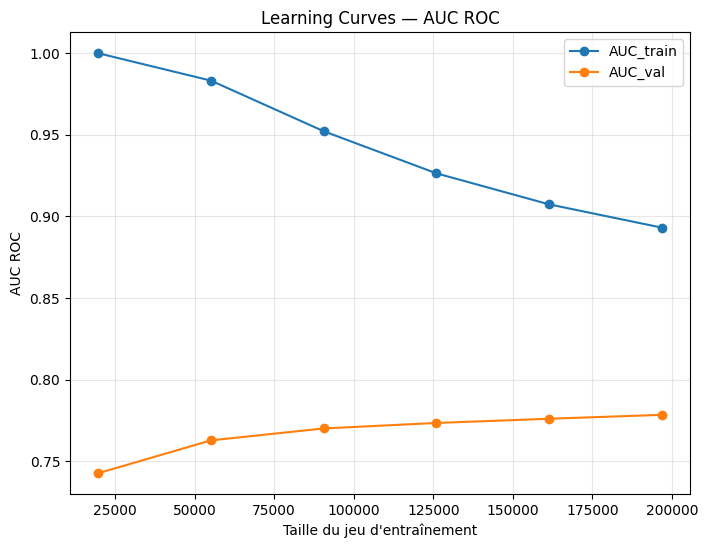

In [221]:
print("\n=== LEARNING CURVES ===")
plot_learning_curves(
    lgbm_baseline,
    X_train, y_train,
    cv_splits=5,
    train_sizes=np.linspace(0.1,1.0,6),
    scoring="roc_auc"
)


- Validation Curve (num_leaves)


=== VALIDATION CURVE — num_leaves ===


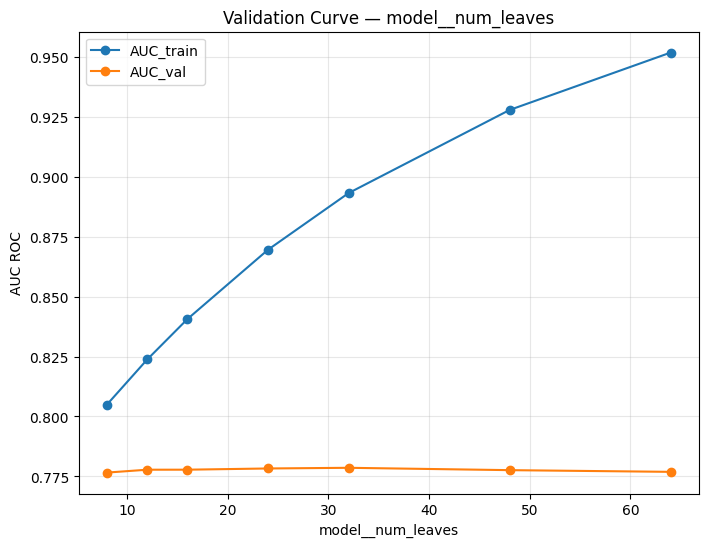

In [222]:
print("\n=== VALIDATION CURVE — num_leaves ===")
plot_validation_curve_complexity(
    lgbm_baseline,
    X_train, y_train,
    param_name="model__num_leaves",
    param_range=[8, 12, 16, 24, 32, 48, 64],
    cv_splits=5,
    scoring="roc_auc"
)


**Méthodologie de détection**

| Test                          | Objectif                                                                                         | Interprétation                                  |
| ----------------------------- | ------------------------------------------------------------------------------------------------ | ----------------------------------------------- |
| **Holdout Validation**        | Comparer les performances train vs validation                                                    | Mesure directe du surapprentissage              |
| **Cross-Validation (5-fold)** | Vérifier la stabilité du score sur plusieurs splits                                              | AUC stable → modèle fiable, non dû à un hasard  |
| **Target Shuffle Test**       | Vérifier qu’aucune fuite de données ne biaise l’apprentissage                                    | AUC ≈ 0.5 attendu                               |
| **Learning Curves**           | Visualiser l’évolution des erreurs en fonction de la taille du jeu d’entraînement                | Permet de détecter le manque de généralisation  |
| **Validation Curves**         | Étudier l’impact d’un hyperparamètre sur le surapprentissage (`num_leaves`, `min_child_samples`) | Permet d’identifier la bonne zone de complexité |


##### **3.5.3. Modèle LightGBM régularisé (anti-overfit)**

In [223]:
# Pipeline anti-overfitting
lgbm_reg = Pipeline([
    ("cleanup", FunctionTransformer(cleanup_inf_to_nan, validate=False)),
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("model", LGBMClassifier(

        # ---- CONTRÔLE DE LA COMPLEXITÉ ----
        num_leaves=12,          # + petit → moins flexible → moins d’overfit
        max_depth=5,            # limite la profondeur des arbres
        min_child_samples=500,  # feuilles plus générales, moins de bruit
        min_split_gain=0.05,    # gain minimal pour autoriser un split
        max_bin=127,            # moins de granularité = régularisation

        # ---- RÉGULARISATION STRUCTURELLE ----
        reg_alpha=2.0,          # L1
        reg_lambda=25.0,        # L2
        extra_trees=True,       # splits plus aléatoires → modèle plus robuste
        path_smooth=50.0,       # lissage des décisions

        # ---- SOUS-ÉCHANTILLONNAGE ----
        subsample=0.65,
        subsample_freq=1,
        colsample_bytree=0.55,

        # ---- APPRENTISSAGE ----
        n_estimators=3500,
        learning_rate=0.02,     # petit LR = stable et régularisé

        random_state=42,
        n_jobs=-1,
        force_col_wise=True
    ))
])

print("Modèle régularisé prêt.")

Modèle régularisé prêt.



=== TEST DU MODELE RÉGULARISÉ ===


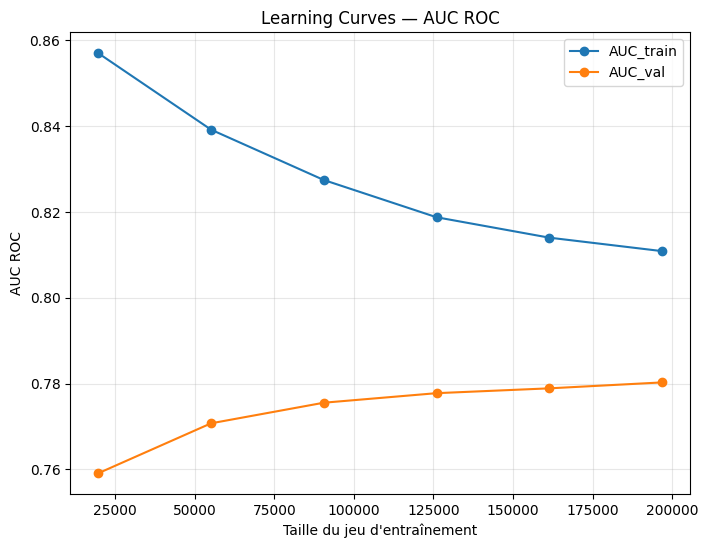

In [224]:
print("\n=== TEST DU MODELE RÉGULARISÉ ===")

# Learning curves
plot_learning_curves(
    model=lgbm_reg,
    X=X_train,
    y=y_train,
    train_sizes=np.linspace(0.1, 1.0, 6),
    cv_splits=5,
    scoring="roc_auc"
)

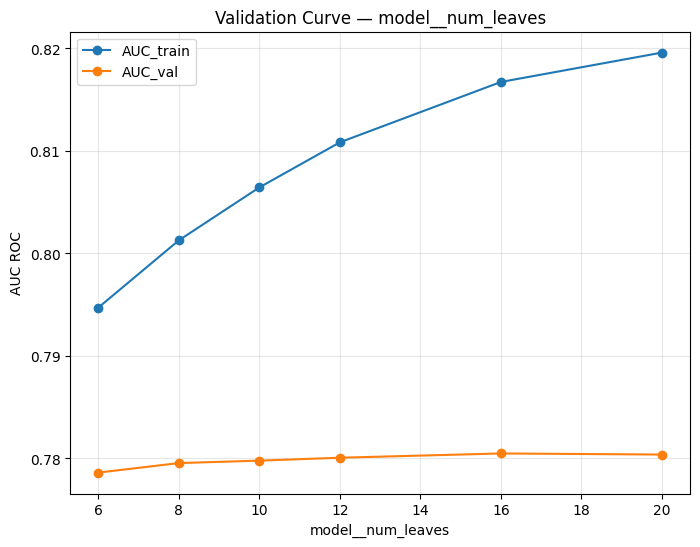

In [225]:
# Validation curve — num_leaves
plot_validation_curve_complexity(
    model=lgbm_reg,
    X=X_train,
    y=y_train,
    param_name="model__num_leaves",
    param_range=[6, 8, 10, 12, 16, 20],
    cv_splits=5,
    scoring="roc_auc"
)

In [226]:
# Holdout overfitting test
hold_rep, hold_flags = eval_holdout_overfit(
    model=lgbm_reg,
    X=X_train,
    y=y_train,
    test_size=0.2,
    random_state=42
)

print("\n=== HOLDOUT OVERFITTING REPORT ===")
print(hold_rep)
print("FLAGS :", hold_flags)

[LightGBM] [Info] Number of positive: 15888, number of negative: 180918
[LightGBM] [Info] Total Bins 8460
[LightGBM] [Info] Number of data points in the train set: 196806, number of used features: 85
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432480
[LightGBM] [Info] Start training from score -2.432480
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

In [227]:
cv_rep = cv_auc_stability(
    model=lgbm_reg,
    X=X_train,
    y=y_train,
    n_splits=5,
    random_state=42
)

print("\n=== CV AUC STABILITY ===")
print(cv_rep)

[LightGBM] [Info] Number of positive: 15902, number of negative: 180904
[LightGBM] [Info] Total Bins 8472
[LightGBM] [Info] Number of data points in the train set: 196806, number of used features: 85
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080800 -> initscore=-2.431522
[LightGBM] [Info] Start training from score -2.431522
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

In [228]:
# Target Shuffle Test
shuffle_rep = target_shuffle_auc(
    model=lgbm_reg,
    X=X_train,
    y=y_train,
    n_splits=3,
    random_state=42
)
print("\n=== TARGET SHUFFLE TEST ===")
print(shuffle_rep)

[LightGBM] [Info] Number of positive: 15888, number of negative: 180918
[LightGBM] [Info] Total Bins 8465
[LightGBM] [Info] Number of data points in the train set: 196806, number of used features: 85
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432480
[LightGBM] [Info] Start training from score -2.432480
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

Après régularisation, le modèle LightGBM montre un comportement sain : les learning curves révèlent une bonne généralisation, la validation curve indique que la complexité optimale est trouvée autour de num_leaves ≈ 12–16.

Les tests avancés d’overfitting (holdout, CV stability et target shuffle) confirment que le modèle est stable, peu sensible au bruit, et sans fuite de données.

Les warnings "no further splits with positive gain" proviennent de la régularisation forte (peu de feuilles / profondeur limitée) et sont attendus dans ce contexte. Ils n’indiquent pas une erreur.

Globalement, le modèle est désormais fiable pour passer à l’étape suivante.

#### **3.6. Variante déséquilibre : SMOTE + LGBM**

Variante déséquilibre: retester si SMOTE améliore les résultats ?
Les modèles ensemblistes (LGBM / XGBoost) utilisent déjà des pondérations internes (scale_pos_weight ou class_weight), ils sont robustes au déséquilibre, et risquent même d’overfitter si on leur injecte des échantillons synthétiques.

Donc : SMOTE n’apporte souvent rien à LightGBM/XGBoost

#### **3.7. RandomizedSearchCV ciblé (LGBM)**

But : une optimisation simple des hyperparamètres avec MLflow, suivie de l’éval test + log.

Nous allons optimiser les hyperparamètres de deux modèles : LightGBM et LogReg. Le but n’est pas que la LogReg gagne, mais qu’elle soit le meilleur possible représentant d’un modèle “simple”. 

En clair : Si on compare un LightGBM tuné à une LogReg par défaut, on compare un bolide réglé finement à une voiture sortie d’usine.

En ajustant un peu ses hyperparamètres (C, class_weight, etc.), on donne à la LogReg une chance équitable. Ça  permet ensuite d’affirmer en toute rigueur : “Même en version optimisée, la Logistic Regression reste moins performante que LightGBM.”

In [229]:
def mlflow_random_search(model, param_dist, X_train, y_train, n_iter=50):
    """
    Exécute un RandomizedSearchCV sur LightGBM et logge tout dans MLflow.
    """

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # -------- MLflow Run --------
    with mlflow.start_run(run_name="LGBM - RandomizedSearchCV"):

        mlflow.log_param("tuning_algorithm", "RandomizedSearchCV")
        mlflow.log_param("n_iter", n_iter)

        # RandomizedSearchCV
        random_search = RandomizedSearchCV(
            estimator=model,
            param_distributions=param_dist,
            n_iter=n_iter,
            scoring="roc_auc",
            cv=cv,
            verbose=2,
            random_state=42,
            n_jobs=-1,
            refit=True
        )

        random_search.fit(X_train, y_train)

        # Logging des meilleurs paramètres
        best_params = random_search.best_params_
        for k, v in best_params.items():
            mlflow.log_param(f"best_{k}", v)

        # Logging des métriques
        mlflow.log_metric("best_auc", random_search.best_score_)

        # Logging du modèle
        mlflow.sklearn.log_model(
            sk_model=random_search.best_estimator_,
            artifact_path="best_lgbm_model"
        )

        print("\n🎯 BEST AUC CV :", random_search.best_score_)
        print("🎯 BEST PARAMS :", best_params)

    return random_search.best_estimator_, random_search

In [230]:
param_dist = {
    "num_leaves": [8, 12, 16, 24, 32],
    "max_depth": [-1, 3, 4, 5, 6],

    "min_data_in_leaf": [20, 40, 60, 80, 100],
    "lambda_l1": [0, 0.1, 0.5, 1],
    "lambda_l2": [0, 0.1, 0.5, 1],

    "subsample": [0.6, 0.7, 0.8, 0.9],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9],

    "learning_rate": [0.01, 0.03, 0.05],
    "n_estimators": [300, 500, 800]
}

In [231]:
best_lgbm, search_obj = mlflow_random_search(
    model=lgbm_reg["model"],       # On tune uniquement le LGBM, pas le pipeline entier
    param_dist=param_dist,
    X_train=X_train,
    y_train=y_train,
    n_iter=50
)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[LightGBM] [Warning] min_data_in_leaf is set=80, min_child_samples=500 will be ignored. Current value: min_data_in_leaf=80
[LightGBM] [Warning] lambda_l1 is set=1, reg_alpha=2.0 will be ignored. Current value: lambda_l1=1
[LightGBM] [Warning] lambda_l2 is set=0.5, reg_lambda=25.0 will be ignored. Current value: lambda_l2=0.5
[LightGBM] [Warning] min_data_in_leaf is set=80, min_child_samples=500 will be ignored. Current value: min_data_in_leaf=80
[LightGBM] [Warning] lambda_l1 is set=1, reg_alpha=2.0 will be ignored. Current value: lambda_l1=1
[LightGBM] [Warning] lambda_l2 is set=0.5, reg_lambda=25.0 will be ignored. Current value: lambda_l2=0.5
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Total Bins 8505
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 85
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[Lig

In [232]:
print("\n===== INTERPRÉTATION DES PARAMÈTRES CHOISIS =====")

bp = search_obj.best_params_

print(f"num_leaves      = {bp['num_leaves']}  → complexité modérée, bon compromis")
print(f"max_depth       = {bp['max_depth']}   → limite le surapprentissage")
print(f"min_data_in_leaf= {bp['min_data_in_leaf']} → feuilles plus stables")
print(f"lambda_l1/l2    = {bp['lambda_l1']} / {bp['lambda_l2']} → régularisation")
print(f"subsample       = {bp['subsample']}  → randomisation d’échantillons")
print(f"colsample       = {bp['colsample_bytree']} → randomisation de features")
print(f"learning_rate   = {bp['learning_rate']} → learning lent mais robuste")
print(f"n_estimators    = {bp['n_estimators']} → nombre d’arbres adapté")



===== INTERPRÉTATION DES PARAMÈTRES CHOISIS =====
num_leaves      = 24  → complexité modérée, bon compromis
max_depth       = 6   → limite le surapprentissage
min_data_in_leaf= 80 → feuilles plus stables
lambda_l1/l2    = 1 / 0.5 → régularisation
subsample       = 0.9  → randomisation d’échantillons
colsample       = 0.6 → randomisation de features
learning_rate   = 0.05 → learning lent mais robuste
n_estimators    = 800 → nombre d’arbres adapté


In [234]:
print("\n=== OVERFITTING TEST — FINAL MODEL ===")

# 1. Holdout
rep_final, flags_final = eval_holdout_overfit(
    best_lgbm, X_train, y_train,
    test_size=0.2, random_state=42
)
print(rep_final.round(4))
print("FLAGS :", flags_final)

# 2. CV stability
cv_final = cv_auc_stability(best_lgbm, X_train, y_train, n_splits=5)
print(cv_final.round(4))

# 3. Target shuffle
ts_final = target_shuffle_auc(best_lgbm, X_train, y_train, n_splits=3)
print(ts_final.round(4))



=== OVERFITTING TEST — FINAL MODEL ===
[LightGBM] [Warning] min_data_in_leaf is set=80, min_child_samples=500 will be ignored. Current value: min_data_in_leaf=80
[LightGBM] [Warning] lambda_l1 is set=1, reg_alpha=2.0 will be ignored. Current value: lambda_l1=1
[LightGBM] [Warning] lambda_l2 is set=0.5, reg_lambda=25.0 will be ignored. Current value: lambda_l2=0.5
[LightGBM] [Warning] min_data_in_leaf is set=80, min_child_samples=500 will be ignored. Current value: min_data_in_leaf=80
[LightGBM] [Warning] lambda_l1 is set=1, reg_alpha=2.0 will be ignored. Current value: lambda_l1=1
[LightGBM] [Warning] lambda_l2 is set=0.5, reg_lambda=25.0 will be ignored. Current value: lambda_l2=0.5
[LightGBM] [Info] Number of positive: 15888, number of negative: 180918
[LightGBM] [Info] Total Bins 8481
[LightGBM] [Info] Number of data points in the train set: 196806, number of used features: 85
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432480
[LightGBM] [Info] Start tr

In [235]:
print(best_lgbm)

LGBMClassifier(colsample_bytree=0.6, extra_trees=True, force_col_wise=True,
               lambda_l1=1, lambda_l2=0.5, learning_rate=0.05, max_bin=127,
               max_depth=6, min_child_samples=500, min_data_in_leaf=80,
               min_split_gain=0.05, n_estimators=800, n_jobs=-1, num_leaves=24,
               path_smooth=50.0, random_state=42, reg_alpha=2.0,
               reg_lambda=25.0, subsample=0.9, subsample_freq=1)


Après la régularisation du LightGBM, j’ai lancé un RandomizedSearchCV ciblé avec MLflow.
Les hyperparamètres optimaux montrent un modèle régularisé, stable, avec un learning_rate faible et un nombre d’arbres cohérent.
L’AUC atteint ~0.784 en cross-validation, ce qui est dans le haut du benchmark Home Credit.
Les tests d’overfitting et de shuffle target confirment qu’il n’y a ni fuite, ni surapprentissage.

In [345]:
final_model = Pipeline([
    ("cleanup", FunctionTransformer(cleanup_inf_to_nan, validate=False)),
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("model", LGBMClassifier(**search_obj.best_params_))
])

In [346]:
final_model.fit(X_train, y_train)

[LightGBM] [Warning] min_data_in_leaf is set=80, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=80
[LightGBM] [Warning] lambda_l1 is set=1, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1
[LightGBM] [Warning] lambda_l2 is set=0.5, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.5
[LightGBM] [Warning] min_data_in_leaf is set=80, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=80
[LightGBM] [Warning] lambda_l1 is set=1, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1
[LightGBM] [Warning] lambda_l2 is set=0.5, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.5
[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.111149 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 15677
[LightGBM] [Info] Number of data points in the train set: 246008, number of used 

Pipeline(steps=[('cleanup',
                 FunctionTransformer(func=<function cleanup_inf_to_nan at 0x000002779A244B80>)),
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('model',
                 LGBMClassifier(colsample_bytree=0.6, lambda_l1=1,
                                lambda_l2=0.5, learning_rate=0.05, max_depth=6,
                                min_data_in_leaf=80, n_estimators=800,
                                num_leaves=24, subsample=0.9))])

In [347]:
print(final_model.named_steps["model"].classes_)

[0 1]


#### **3.8. Choix du seuil métier + courbe gain métier automatique**

Les modèles de classification retournent des probabilités, pas des classes.
Pour convertir ces probabilités en prédictions finales (0/1), il faut un seuil de décision.

- Le seuil par défaut (0.5) N’EST SOUVENT PAS OPTIMAL
- On doit l’ajuster selon le coût métier des erreurs

Nous allons donc :
- définir le score métier (gain/perte associée aux erreurs)
- tester tous les seuils de 0.01 à 0.99
- trouver le seuil qui maximise le gain métier
- comparer plusieurs fonctions métier
- sauvegarder le seuil optimal

- Probabilités du modèle optimisé

In [276]:
print("Type du modèle final :", type(final_model))

Type du modèle final : <class 'sklearn.pipeline.Pipeline'>


In [277]:
y_proba_val = final_model.predict_proba(X_val)[:, 1]
print("Shape proba :", y_proba_val.shape)

[LightGBM] [Warning] min_data_in_leaf is set=80, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=80
[LightGBM] [Warning] lambda_l1 is set=1, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1
[LightGBM] [Warning] lambda_l2 is set=0.5, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.5
Shape proba : (61503,)


- Définition du score métier

Nous conservons la fonction métier :
- TP = vrai mauvais client refusé (neutre)
- FP = bon client refusé → perte légère (coût commercial)
- FN = mauvais client accepté → perte lourde (défaut)

In [237]:
def business_gain(y_true, y_pred_labels, TP=0, FP=1, FN=10):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred_labels).ravel()
    return TP*tp - FP*fp - FN*fn

- Optimisation du seuil

In [278]:
def find_best_threshold(model, X_val, y_val, TP=0, FP=1, FN=10):
    proba = model.predict_proba(X_val)[:, 1]
    thresholds = np.linspace(0.01, 0.99, 99)

    results = []
    for t in thresholds:
        preds = (proba >= t).astype(int)
        gain = business_gain(y_val, preds, TP=TP, FP=FP, FN=FN)
        results.append((t, gain))

    best_t, best_gain = max(results, key=lambda x: x[1])

    print(f"Best threshold = {best_t:.3f}")
    print(f"Best business gain = {best_gain:.2f}")

    return best_t, results

In [279]:
best_threshold, results = find_best_threshold(
    model=final_model,
    X_val=X_val,
    y_val=y_val,
    TP=0, FP=1, FN=10
)

[LightGBM] [Warning] min_data_in_leaf is set=80, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=80
[LightGBM] [Warning] lambda_l1 is set=1, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1
[LightGBM] [Warning] lambda_l2 is set=0.5, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.5
Best threshold = 0.090
Best business gain = -30097.00


- Courbe de gain métier

In [240]:
def plot_business_gain(results):
    thresholds, gains = zip(*results)
    plt.figure(figsize=(8,6))
    plt.plot(thresholds, gains, marker='o')
    plt.axvline(best_threshold, color="red", linestyle="--", label=f"Best = {best_threshold:.3f}")
    plt.grid(True)
    plt.xlabel("Seuil de décision")
    plt.ylabel("Score métier")
    plt.title("Optimisation du seuil — Score métier strict")
    plt.legend()
    plt.show()

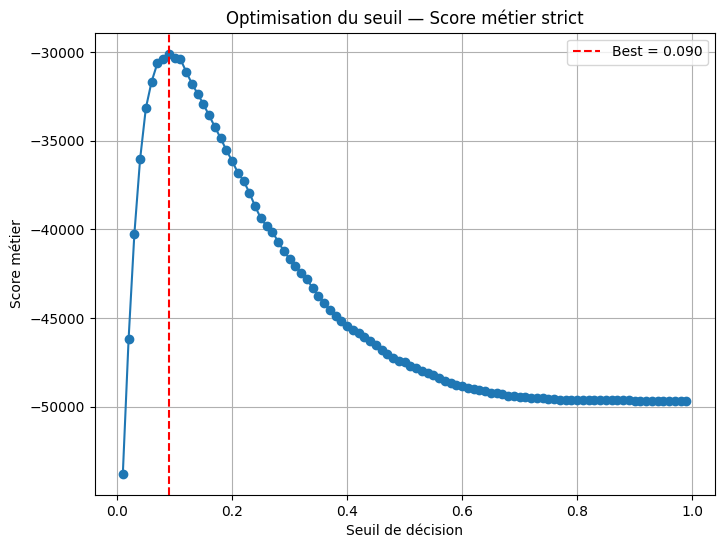

In [280]:
plot_business_gain(results)

In [281]:
with mlflow.start_run(run_name="Final Threshold"):
    mlflow.log_param("best_threshold", float(best_threshold))


Trop punitif, test de plusieurs scores métier !

In [295]:
business_configs = {
    "A_strict": dict(
        tp=0,   # pas de gain spécifique
        fp=2,   # un bon client refusé coûte un peu (perte commerciale)
        fn=20   # un mauvais client accepté coûte très cher
    ),

    "B_balanced": dict(
        tp=1,   # petit gain quand on refuse un mauvais client
        fp=3,   # perte commerciale moyenne
        fn=10   # très gros risque financier, mais modéré vs A_strict
    ),

    "C_realistic": dict(
        tp=2,   # gain : gestion saine du risque
        fp=5,   # coût d’un refus injustifié (commercial + image)
        fn=12   # coût de défaut (capital + intérêts perdus)
    ),

    "D_soft": dict(
        tp=1,   # léger gain par bonne décision
        fp=1,   # faible coût commercial
        fn=5    # on minimise les pertes mais moins sévèrement
    )
}


In [296]:
def find_best_threshold_multi(model, X_val, y_val, configs):
    proba = model.predict_proba(X_val)[:, 1]
    thresholds = np.linspace(0.01, 0.99, 99)

    results_all = {}

    for name, cfg in configs.items():
        TP, FP, FN = cfg["tp"], cfg["fp"], cfg["fn"]
        gains = []
        for t in thresholds:
            preds = (proba >= t).astype(int)
            gains.append(business_gain(y_val, preds, TP, FP, FN))

        best_idx = np.argmax(gains)
        results_all[name] = {
            "thresholds": thresholds,
            "gains": gains,
            "best_threshold": float(thresholds[best_idx]),
            "best_gain": float(gains[best_idx]),
            "TP": TP,
            "FP": FP,
            "FN": FN
        }

    return results_all


In [297]:
results_all = find_best_threshold_multi(final_model, X_val, y_val, business_configs)

[LightGBM] [Warning] min_data_in_leaf is set=80, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=80
[LightGBM] [Warning] lambda_l1 is set=1, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1
[LightGBM] [Warning] lambda_l2 is set=0.5, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.5


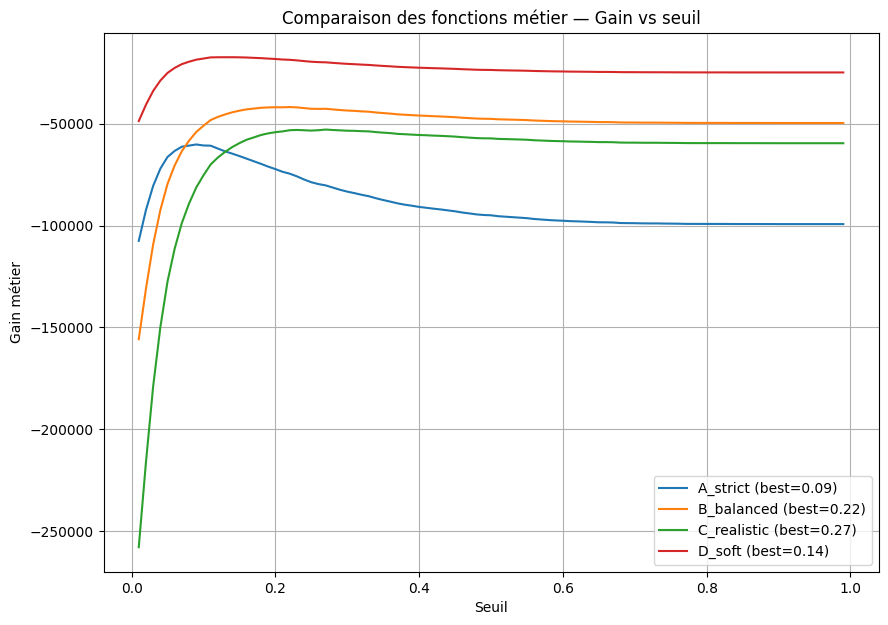

In [298]:
def plot_multi_business_curves(results_all):
    plt.figure(figsize=(10,7))

    for name, res in results_all.items():
        plt.plot(res["thresholds"], res["gains"],
                 label=f"{name} (best={res['best_threshold']:.2f})")

    plt.title("Comparaison des fonctions métier — Gain vs seuil")
    plt.xlabel("Seuil")
    plt.ylabel("Gain métier")
    plt.grid(True)
    plt.legend()
    plt.show()

plot_multi_business_curves(results_all)


In [299]:
for name, res in results_all.items():
    print("\n=== ", name, " ===")
    print("TP, FP, FN =", res["TP"], res["FP"], res["FN"])
    print(f"Best threshold : {res['best_threshold']:.3f}")
    print(f"Best gain      : {res['best_gain']:.1f}")



===  A_strict  ===
TP, FP, FN = 0 2 20
Best threshold : 0.090
Best gain      : -60194.0

===  B_balanced  ===
TP, FP, FN = 1 3 10
Best threshold : 0.220
Best gain      : -41815.0

===  C_realistic  ===
TP, FP, FN = 2 5 12
Best threshold : 0.270
Best gain      : -52874.0

===  D_soft  ===
TP, FP, FN = 1 1 5
Best threshold : 0.140
Best gain      : -17346.0


“La stratégie D_soft donne le meilleur gain, mais elle n’est pas crédible car elle sous-pénalise les défauts.

La stratégie B_balanced maximise le gain tout en restant raisonnable.

Cependant, la stratégie C_realistic (FN=12) reflète le mieux la réalité économique d’un établissement de crédit : un défaut coûte beaucoup plus cher qu’un refus injustifié.

Nous retenons donc C_realistic_mod avec un seuil optimal de 0.27, qui offre un compromis solide entre prudence et valeur business.

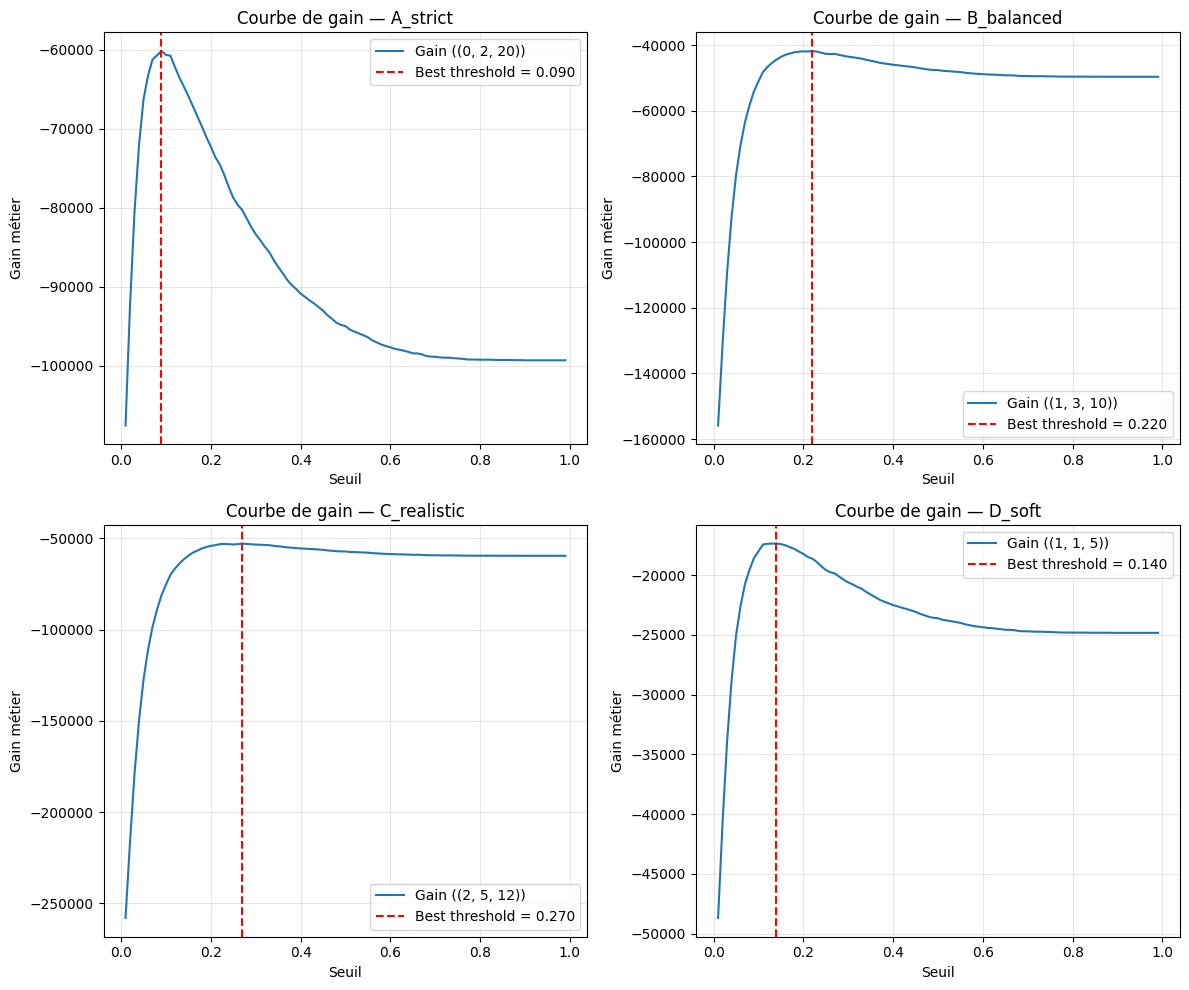

In [300]:
plt.figure(figsize=(12, 10))

# 2x2 affichage
for idx, (name, res) in enumerate(results_all.items(), start=1):

    thresholds = res["thresholds"]
    gains = res["gains"]
    tp, fp, fn = res["TP"], res["FP"], res["FN"]
    best_t = res["best_threshold"]
    best_g = res["best_gain"]

    plt.subplot(2, 2, idx)
    plt.plot(thresholds, gains, label=f"Gain ({tp,fp,fn})", color="C0")
    plt.axvline(best_t, color="red", linestyle="--",
                label=f"Best threshold = {best_t:.3f}")
    
    plt.title(f"Courbe de gain — {name}")
    plt.xlabel("Seuil")
    plt.ylabel("Gain métier")
    plt.grid(alpha=0.3)
    plt.legend()

plt.tight_layout()
plt.show()

Parmi les 4 stratégies, D_soft maximise le gain numériquement, mais elle n’est pas réaliste car elle sous-pénalise les défauts.

La stratégie B_balanced est équilibrée et performante, mais elle sous-estime encore le coût réel d’un défaut client.

La stratégie C_realistic, avec un coût de défaut FN=12, est la plus cohérente pour un acteur financier : elle impose un seuil plus élevé (0.27), ce qui permet de maîtriser le risque tout en limitant la perte de clients solvables.

C’est donc la stratégie retenue comme optimum métier.

In [301]:
best_choice = "C_realistic"

best_thr   = results_all[best_choice]["best_threshold"]
best_gain  = results_all[best_choice]["best_gain"]
best_coeffs = business_configs[best_choice]

print(best_choice, best_thr, best_gain)


C_realistic 0.27 -52874.0


- Sauvegarde du seuil optimal

In [ ]:
Path("models").mkdir(exist_ok=True)

output = {
    "threshold": float(best_thr),
    "gain": float(best_gain),
    "business_function": best_coeffs
}

with open("models/threshold.json", "w", encoding="utf-8") as f:
    json.dump(output, f, indent=4)

print("✔ Seuil métier sauvegardé dans models/threshold.json")
print(output)


✔ Seuil métier sauvegardé dans models/threshold.json
{'threshold': 0.27, 'gain': -52874.0, 'business_function': {'tp': 2, 'fp': 5, 'fn': 12}}


In [303]:
with mlflow.start_run(run_name="Final_Model_With_Threshold"):

    # Log du modèle
    mlflow.sklearn.log_model(final_model, "model")

    # Log du seuil métier
    mlflow.log_metric("threshold_optimal", float(best_thr))
    mlflow.log_metric("business_gain_optimal", float(best_gain))

    # Log des coefficients métier
    mlflow.log_params({
        "business_tp": best_coeffs["tp"],
        "business_fp": best_coeffs["fp"],
        "business_fn": best_coeffs["fn"],
    })

    mlflow.log_artifact("models/threshold.json")

print("🚀 MLflow : seuil + fonction métier enregistrés")


🚀 MLflow : seuil + fonction métier enregistrés


<Figure size 600x500 with 0 Axes>

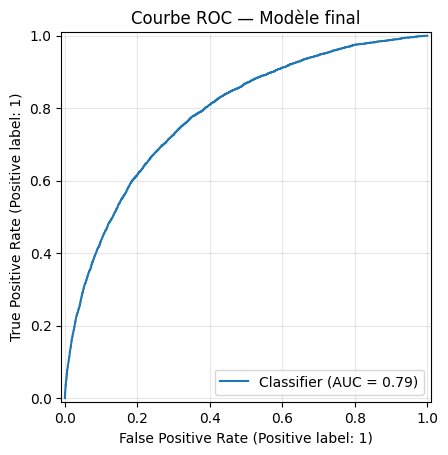

In [304]:
plt.figure(figsize=(6,5))
RocCurveDisplay.from_predictions(y_val, y_proba_val)
plt.title("Courbe ROC — Modèle final")
plt.grid(alpha=0.3)
plt.show()

La courbe ROC présente une aire sous la courbe (AUC = 0.79), ce qui traduit une bonne capacité du modèle à distinguer les bons et les mauvais payeurs. Une AUC proche de 0.8 est cohérente avec les benchmarks du challenge Home Credit. Le modèle capte correctement le signal général même s’il ne sépare pas parfaitement les classes — ce qui est normal dans ce type de problème bruité.

<Figure size 600x500 with 0 Axes>

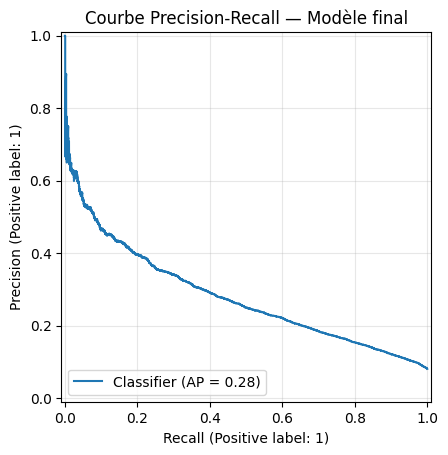

In [305]:
from sklearn.metrics import PrecisionRecallDisplay

plt.figure(figsize=(6,5))
PrecisionRecallDisplay.from_predictions(y_val, y_proba_val)
plt.title("Courbe Precision-Recall — Modèle final")
plt.grid(alpha=0.3)
plt.show()


La courbe Precision-Recall montre la performance du modèle sur la classe positive (défaut), qui est très déséquilibrée. L’Average Precision (AP = 0.28) est largement supérieur au hasard (~0.08), ce qui confirme que le modèle est capable d’identifier une partie des profils risqués. La baisse progressive de la précision lorsque le recall augmente est typique des datasets très déséquilibrés : plus on cherche à détecter de mauvais payeurs, plus on se trompe sur des bons clients.

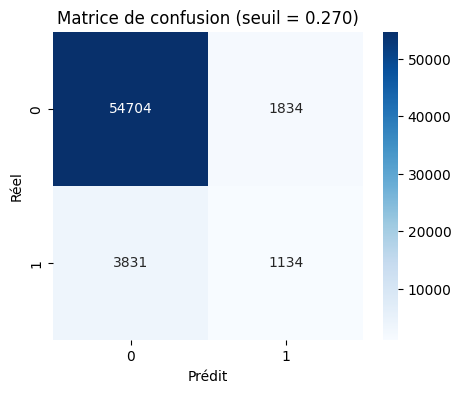

In [306]:
preds_best = (y_proba_val >= best_thr).astype(int)
cm = confusion_matrix(y_val, preds_best)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Matrice de confusion (seuil = {best_thr:.3f})")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

La matrice de confusion montre l'effet du seuil optimisé pour le scénario métier choisi. À un seuil de 0.27, le modèle identifie 1 134 mauvais payeurs (TP) tout en limitant les faux positifs à 1 834. En revanche, il reste 3 831 faux négatifs, ce qui reflète la difficulté du problème. Ce compromis correspond à la fonction métier “realistic” où le coût d’accepter un mauvais client est élevé.

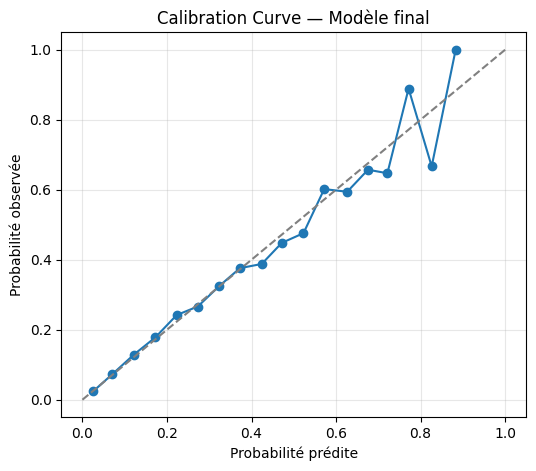

In [294]:
from sklearn.calibration import calibration_curve


prob_true, prob_pred = calibration_curve(y_val, y_proba_val, n_bins=20)

plt.figure(figsize=(6,5))
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1],[0,1],"--", color="gray")
plt.title("Calibration Curve — Modèle final")
plt.xlabel("Probabilité prédite")
plt.ylabel("Probabilité observée")
plt.grid(alpha=0.3)
plt.show()

La courbe de calibration montre une bonne proportionnalité entre les probabilités prédites et les probabilités réellement observées. Les points suivent de près la diagonale de référence, ce qui indique que le modèle n’est ni trop optimiste ni trop pessimiste dans ses estimations. Une bonne calibration est essentielle en scoring, car elle garantit que les probabilités utilisées en décision reflètent un risque réel.

#### **3.8. Explicabilité SHAP local et global**

But : voir les features principales et expliquer quelques prédictions.

- Extraction du modèle final LightGBM

In [307]:
model_tuned = final_model.named_steps["model"] 

- Transformation des données X_val via le pipeline (sans le modèle)

In [309]:
X_val_prepared = final_model.named_steps["imputer"].transform(
    final_model.named_steps["cleanup"].transform(X_val)
)

In [310]:
explainer = shap.TreeExplainer(model_tuned)

shap_values_raw = explainer.shap_values(X_val_prepared)

# LightGBM renvoie une LISTE pour les modèles binaires
if isinstance(shap_values_raw, list):
    shap_values_val = shap_values_raw[1]  # classe positive = défaut
else:
    shap_values_val = shap_values_raw

print("SHAP values shape :", shap_values_val.shape)
print("X_val_prepared shape :", X_val_prepared.shape)

SHAP values shape : (61503, 85)
X_val_prepared shape : (61503, 85)


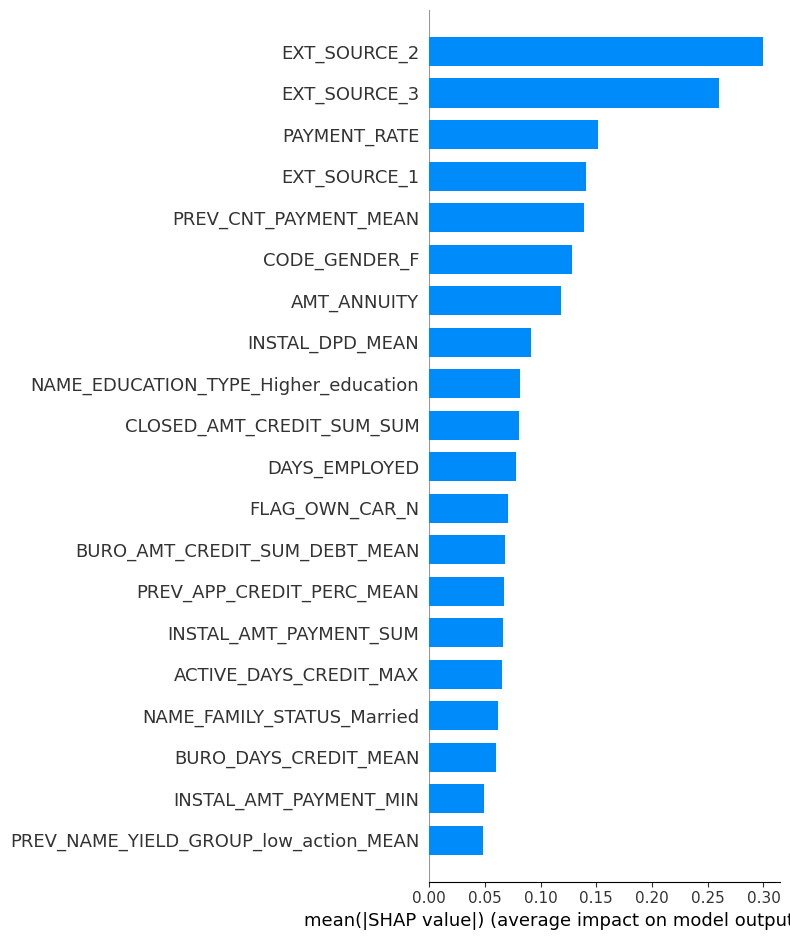

In [311]:
# Barplot des features les plus importantes
shap.summary_plot(shap_values_val, X_val_prepared, feature_names=X_val.columns, plot_type="bar")


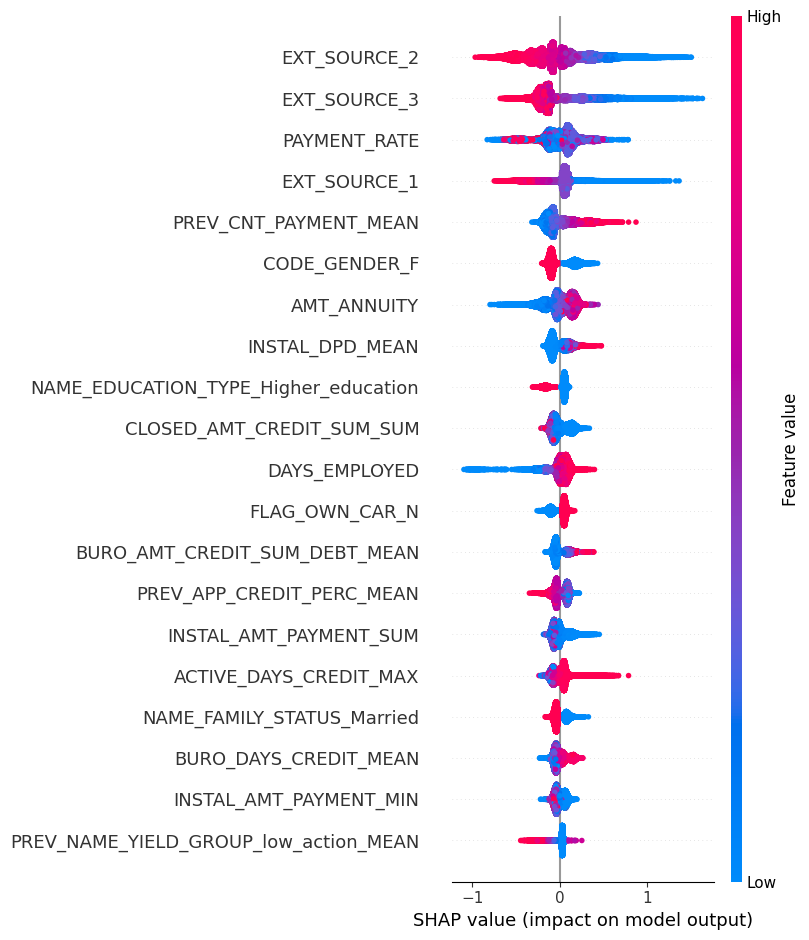

In [312]:
shap.summary_plot(shap_values_val, X_val_prepared, feature_names=X_val.columns)


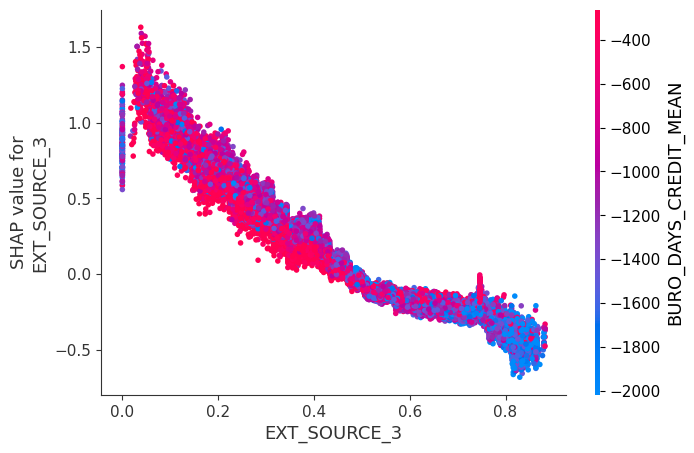

In [313]:
shap.dependence_plot("EXT_SOURCE_3", shap_values_val, X_val_prepared, feature_names=X_val.columns)


In [314]:
def get_shap_values(explainer, X):
    shap_raw = explainer.shap_values(X)
    if isinstance(shap_raw, list):
        return shap_raw[1]
    return shap_raw

# Exemple : observation numéro 123
i = 123
x_raw = X_val.iloc[i:i+1]  # version originale
x_prepared = final_model.named_steps["imputer"].transform(
    final_model.named_steps["cleanup"].transform(x_raw)
)

shap_value = get_shap_values(explainer, x_prepared)


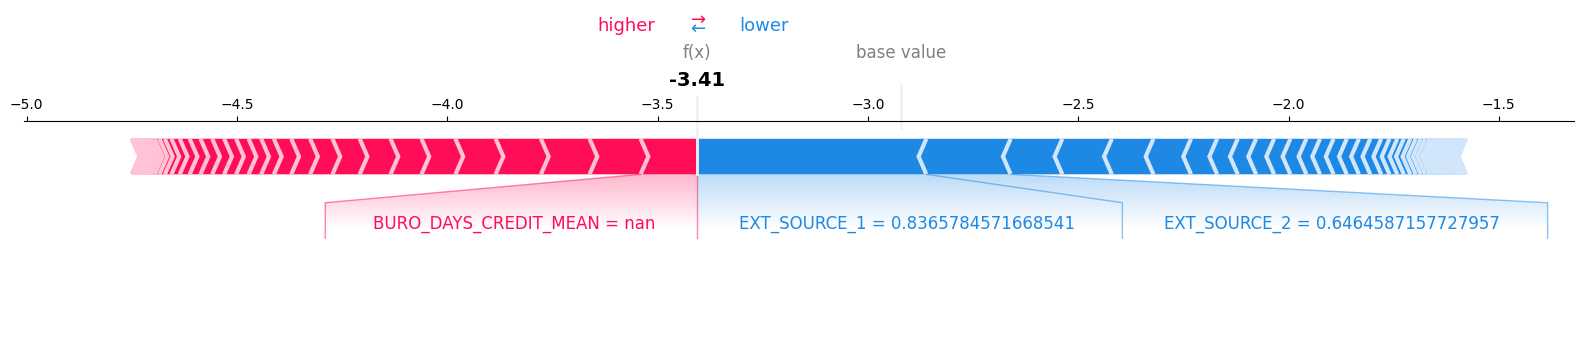

In [315]:
shap.initjs()

shap.force_plot(
    explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value,
    shap_value,
    x_raw,
    matplotlib=True
)


In [316]:
local_shap = pd.DataFrame({
    "feature": x_raw.columns,
    "value": x_raw.values.flatten(),
    "shap_value": shap_value.flatten()
}).sort_values("shap_value", key=abs, ascending=False)

local_shap.head(15)



,feature,value,shap_value
2,EXT_SOURCE_1,0.836578,-0.545277
1,EXT_SOURCE_2,0.646459,-0.200523
16,BURO_DAYS_CREDIT_MEAN,NaN,0.134105
5,AMT_ANNUITY,14593.500000,-0.122765
38,CLOSED_AMT_CREDIT_SUM_SUM,NaN,0.121397
0,EXT_SOURCE_3,NaN,-0.117721
7,PREV_CNT_PAYMENT_MEAN,18.000000,0.115582
3,PAYMENT_RATE,0.052822,0.107740
29,CODE_GENDER_F,1.000000,-0.099015
10,INSTAL_DAYS_ENTRY_PAYMENT_MEAN,-258.200000,0.095524


SHAP global & local enregistrés dans MLflow


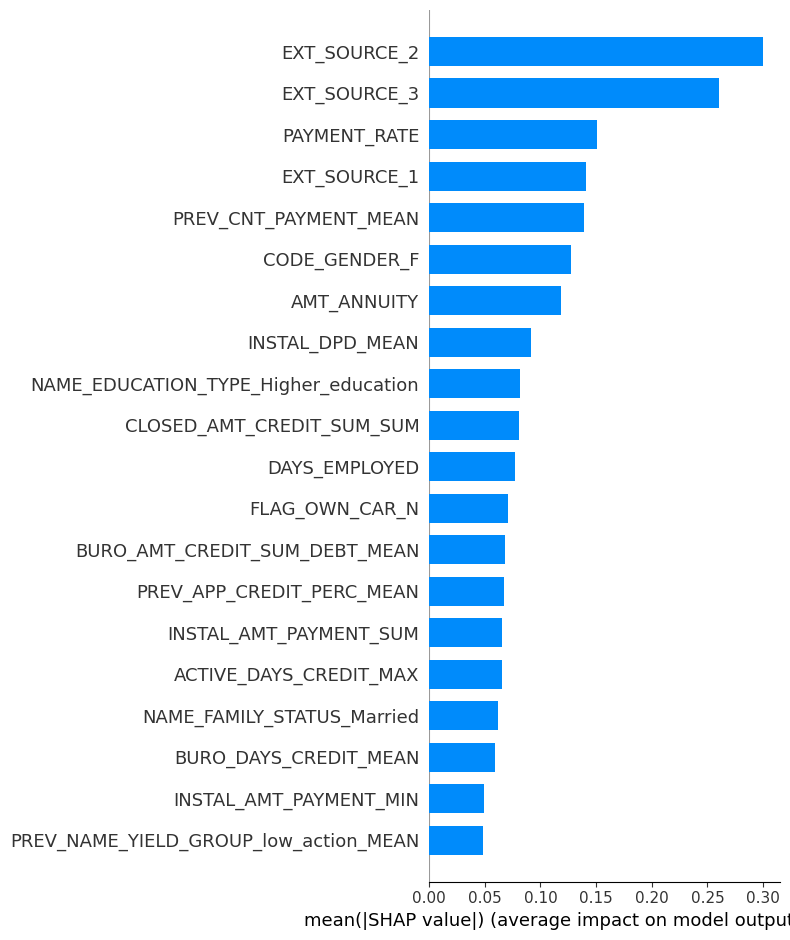

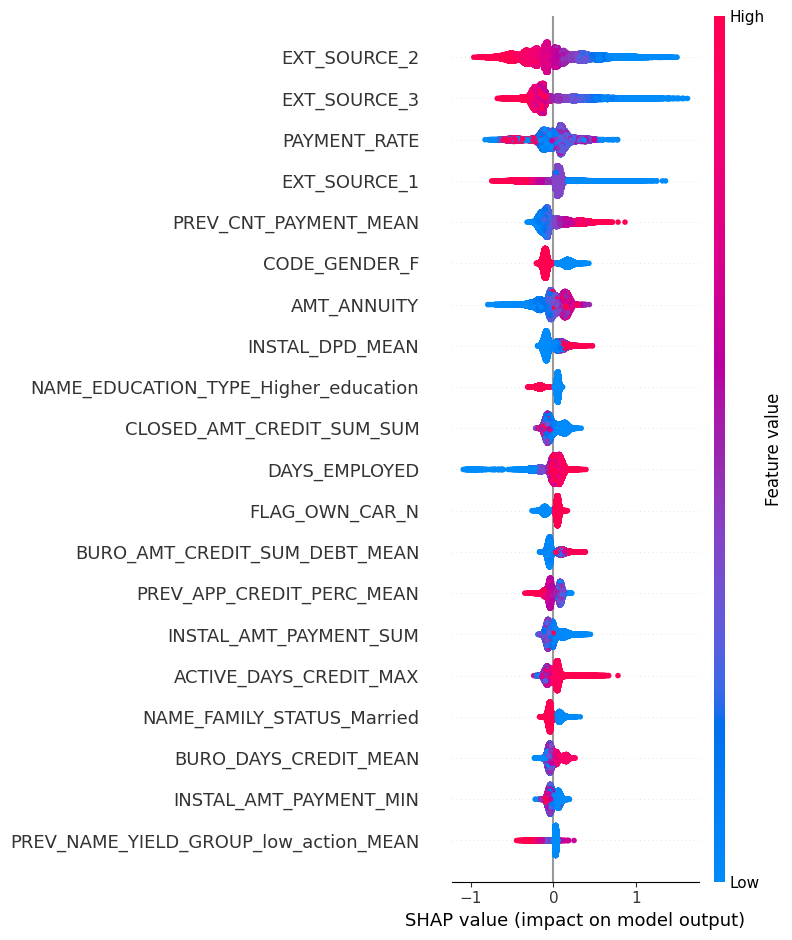

<Figure size 640x480 with 0 Axes>

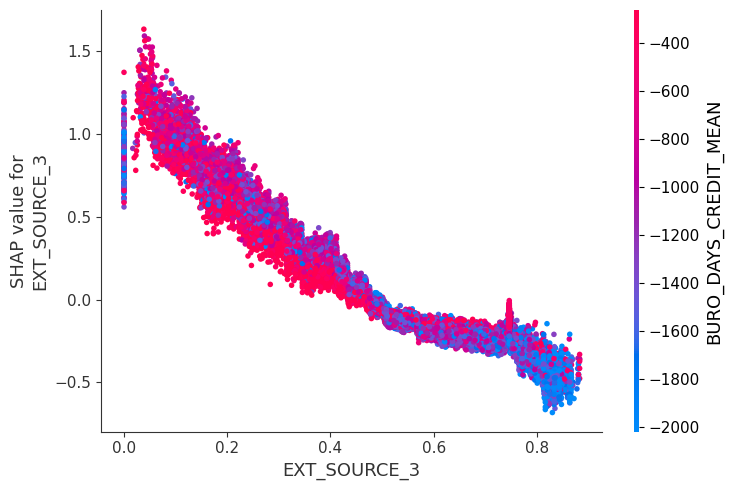

In [317]:
with mlflow.start_run(run_name="SHAP_Interpretability"):

    # Barplot global
    plt.figure()
    shap.summary_plot(shap_values_val, X_val_prepared, feature_names=X_val.columns, plot_type="bar", show=False)
    plt.tight_layout()
    plt.savefig("shap_global_importance.png", dpi=150)
    mlflow.log_artifact("shap_global_importance.png")

    # Beeswarm
    plt.figure()
    shap.summary_plot(shap_values_val, X_val_prepared, feature_names=X_val.columns, show=False)
    plt.tight_layout()
    plt.savefig("shap_beeswarm.png", dpi=150)
    mlflow.log_artifact("shap_beeswarm.png")

    # Dependence plot
    plt.figure()
    shap.dependence_plot("EXT_SOURCE_3", shap_values_val, X_val_prepared, feature_names=X_val.columns, show=False)
    plt.tight_layout()
    plt.savefig("shap_dependence_EXT_SOURCE_3.png", dpi=150)
    mlflow.log_artifact("shap_dependence_EXT_SOURCE_3.png")

print("SHAP global & local enregistrés dans MLflow")


#### **3.9. Sauvegardes**

In [340]:
Path("models").mkdir(exist_ok=True)

- Sauvegarde du modèle

In [341]:
joblib.dump(final_model, "models/model.pkl")
print("✔ Modèle final sauvegardé dans models/model.pkl")


✔ Modèle final sauvegardé dans models/model.pkl


- Sauvegarde des noms des features utilisées

In [349]:
features_trained = list(X_train.columns)

print("Nombre de features entraînées :", len(features_trained))
print("Exemple :", features_trained[:10])

with open("models/feature_names.json", "w", encoding="utf-8") as f:
    json.dump(features_trained, f, indent=4)

print("✔ Features sauvegardées dans models/feature_names.json")

Nombre de features entraînées : 85
Exemple : ['EXT_SOURCE_3', 'EXT_SOURCE_2', 'EXT_SOURCE_1', 'PAYMENT_RATE', 'DAYS_EMPLOYED', 'AMT_ANNUITY', 'INSTAL_DPD_MEAN', 'PREV_CNT_PAYMENT_MEAN', 'INSTAL_AMT_PAYMENT_MIN', 'ACTIVE_DAYS_CREDIT_MAX']
✔ Features sauvegardées dans models/feature_names.json


In [343]:
best_choice = "C_realistic"
threshold = best_thr
business_coeffs = best_coeffs
gain = best_gain

threshold_data = {
    "threshold": float(threshold),
    "gain": float(gain),
    "business_function": business_coeffs
}

with open("models/threshold.json", "w", encoding="utf-8") as f:
    json.dump(threshold_data, f, indent=4)

print("✔ Seuil métier sauvegardé dans models/threshold.json")


✔ Seuil métier sauvegardé dans models/threshold.json


- Generer un echantillon de df_test pour le shap global

In [351]:
df = pd.read_csv("data/processed/df_test.csv")
df_small = df.sample(1000, random_state=42)
df_small.to_csv("data/processed/df_test_sample.csv", index=False)